In [1]:
# ==============================================================================
# PROJECT 9 — FINAL PRODUCTION NOTEBOOK
# Urban Green Infrastructure and Ecosystem Service Deficit Mapping
# Tartu, Estonia
#
# PURPOSE:
# This notebook generates the complete publication-ready deliverables from the
# validated analytical outputs. No analytical processing is performed here.
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

# ==============================================================================
# PROJECT CONFIGURATION
# ==============================================================================

PROJECT_NAME = "Urban Green Infrastructure and Ecosystem Service Deficit Mapping"
STUDY_AREA = "Tartu, Estonia"

AUTHOR = "Abdullah Abdazeez Ayomide"

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit"
)

OUTPUT_ROOT = PROJECT_ROOT / "18_Final_Deliverables"

MAP_DIR = OUTPUT_ROOT / "01_Maps"
CHART_DIR = OUTPUT_ROOT / "02_Charts"
GIS_DIR = OUTPUT_ROOT / "03_GIS_Data"
TABLE_DIR = OUTPUT_ROOT / "04_Tables"
REPORT_DIR = OUTPUT_ROOT / "05_Report"
INFOGRAPHIC_DIR = OUTPUT_ROOT / "06_Infographic"
PORTFOLIO_DIR = OUTPUT_ROOT / "07_Portfolio"
GITHUB_DIR = OUTPUT_ROOT / "08_GitHub"
VALIDATION_DIR = OUTPUT_ROOT / "09_Validation"

directories = [
    OUTPUT_ROOT,
    MAP_DIR,
    CHART_DIR,
    GIS_DIR,
    TABLE_DIR,
    REPORT_DIR,
    INFOGRAPHIC_DIR,
    PORTFOLIO_DIR,
    GITHUB_DIR,
    VALIDATION_DIR,
]

for folder in directories:
    folder.mkdir(parents=True, exist_ok=True)

print("="*90)
print("PROJECT 9 FINAL PRODUCTION")
print("="*90)
print(f"Project      : {PROJECT_NAME}")
print(f"Study Area   : {STUDY_AREA}")
print(f"Author       : {AUTHOR}")
print(f"Root Folder  : {PROJECT_ROOT}")
print(f"Output Folder: {OUTPUT_ROOT}")
print("="*90)
print("✓ Directory structure created successfully.")

Mounted at /content/drive
PROJECT 9 FINAL PRODUCTION
Project      : Urban Green Infrastructure and Ecosystem Service Deficit Mapping
Study Area   : Tartu, Estonia
Author       : Abdullah Abdazeez Ayomide
Root Folder  : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit
Output Folder: /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables
✓ Directory structure created successfully.


In [3]:
# ==============================================================================
# INSTALL (IF NEEDED) & IMPORT LIBRARIES
# ==============================================================================

import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install missing packages
try:
    from docx import Document
except ModuleNotFoundError:
    print("Installing python-docx...")
    install("python-docx")
    from docx import Document

try:
    from PIL import Image
except ModuleNotFoundError:
    print("Installing Pillow...")
    install("Pillow")
    from PIL import Image

# Standard libraries
import os
import glob
import zipfile
import shutil

# Scientific libraries
import numpy as np
import pandas as pd

# GIS libraries
import geopandas as gpd
import rasterio
from rasterio.plot import show

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Word document support
from docx.shared import Inches

print("=" * 90)
print("ALL REQUIRED LIBRARIES LOADED SUCCESSFULLY")
print("=" * 90)

print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"GeoPandas    : {gpd.__version__}")
print(f"Rasterio     : {rasterio.__version__}")

print("\n✓ python-docx")
print("✓ Pillow")
print("✓ Matplotlib")
print("✓ GIS libraries")

Installing python-docx...
ALL REQUIRED LIBRARIES LOADED SUCCESSFULLY
NumPy        : 2.0.2
Pandas       : 2.2.2
GeoPandas    : 1.1.4
Rasterio     : 1.5.0

✓ python-docx
✓ Pillow
✓ Matplotlib
✓ GIS libraries


In [5]:
# ==============================================================================
# VALIDATE AND RESOLVE ANALYTICAL OUTPUTS
# ==============================================================================

from pathlib import Path

# ------------------------------------------------------------------------------
# Demand raster resolver
# ------------------------------------------------------------------------------

preferred_demand_paths = [
    PROJECT_ROOT / "07_Demand" / "Demand_Index_2025.tif",
    PROJECT_ROOT / "07_Demand" / "Ecosystem_Service_Demand.tif",
    PROJECT_ROOT / "07_Ecosystem_Service_Demand" / "Demand_Index_2025.tif",
    PROJECT_ROOT / "07_Ecosystem_Service_Demand" / "Ecosystem_Service_Demand.tif",
    PROJECT_ROOT / "07_Ecosystem_Service_Demand" / "Tartu_Demand_Index_2025.tif",
    PROJECT_ROOT / "07_Ecosystem_Service_Demand" / "Demand_Surface_2025.tif",
]

DEMAND_RASTER = None

# First try the expected filenames
for candidate in preferred_demand_paths:
    if candidate.exists():
        DEMAND_RASTER = candidate
        break

# If no preferred path exists, search recursively
if DEMAND_RASTER is None:
    search_terms = ["demand", "service_demand"]

    demand_matches = []

    for tif_file in PROJECT_ROOT.rglob("*.tif"):
        name_lower = tif_file.name.lower()

        if any(term in name_lower for term in search_terms):
            # Exclude unrelated rasters where possible
            if "deficit" not in name_lower and "priority" not in name_lower:
                demand_matches.append(tif_file)

    demand_matches = sorted(set(demand_matches))

    if len(demand_matches) == 1:
        DEMAND_RASTER = demand_matches[0]

    elif len(demand_matches) > 1:
        print("=" * 90)
        print("MULTIPLE POSSIBLE DEMAND RASTERS FOUND")
        print("=" * 90)

        for index, file_path in enumerate(demand_matches, start=1):
            print(f"{index}. {file_path}")

        # Prefer filenames containing "index", then "demand"
        ranked_matches = sorted(
            demand_matches,
            key=lambda p: (
                "demand" not in p.name.lower(),
                "index" not in p.name.lower(),
                len(str(p))
            )
        )

        DEMAND_RASTER = ranked_matches[0]

        print("\nAutomatically selected:")
        print(DEMAND_RASTER)

# ------------------------------------------------------------------------------
# Authoritative validated files
# ------------------------------------------------------------------------------

required_files = {
    "Hybrid UGI":
        PROJECT_ROOT / "05_Green_Infrastructure" / "Tartu_UGI_2025.tif",

    "UGI Statistics":
        PROJECT_ROOT / "05_Green_Infrastructure" / "UGI_Statistics.csv",

    "ESC Raster":
        PROJECT_ROOT / "06_Ecosystem_Service_Capacity" / "ESC_Continuous_2025.tif",

    "Demand Raster":
        DEMAND_RASTER,

    "Deficit Raster":
        PROJECT_ROOT / "08_Ecosystem_Service_Deficit" /
        "Ecosystem_Service_Deficit.tif",

    "Planning Priority":
        PROJECT_ROOT / "09_Planning_Priority" /
        "Planning_Priority_Zones.tif",

    "Planning Statistics":
        PROJECT_ROOT / "09_Planning_Priority" /
        "Planning_Priority_Statistics.csv",
}

# ------------------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------------------

print("\n" + "=" * 90)
print("VALIDATING PROJECT OUTPUTS")
print("=" * 90)

missing = []

for name, file_path in required_files.items():

    if file_path is not None and Path(file_path).exists():
        print(f"✓ {name:<24}: {Path(file_path).name}")

    else:
        print(f"✗ Missing : {name}")
        missing.append(name)

print("=" * 90)

if not missing:
    print("ALL REQUIRED ANALYTICAL OUTPUTS FOUND.")
    print("\nResolved Demand Raster:")
    print(DEMAND_RASTER)

else:
    print("Missing outputs:")
    for item in missing:
        print(f"- {item}")

    raise FileNotFoundError(
        "One or more validated analytical outputs could not be located."
    )


VALIDATING PROJECT OUTPUTS
✓ Hybrid UGI              : Tartu_UGI_2025.tif
✓ UGI Statistics          : UGI_Statistics.csv
✓ ESC Raster              : ESC_Continuous_2025.tif
✓ Demand Raster           : Demand_Index_2025.tif
✓ Deficit Raster          : Ecosystem_Service_Deficit.tif
✓ Planning Priority       : Planning_Priority_Zones.tif
✓ Planning Statistics     : Planning_Priority_Statistics.csv
ALL REQUIRED ANALYTICAL OUTPUTS FOUND.

Resolved Demand Raster:
/content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/07_Demand_Surface/Demand_Index_2025.tif


In [6]:
# ==============================================================================
# SECTION 2 — LOAD VALIDATED ANALYTICAL OUTPUTS
# ==============================================================================

import numpy as np
import pandas as pd
import rasterio

# ------------------------------------------------------------------------------
# Authoritative input paths
# ------------------------------------------------------------------------------

UGI_RASTER = required_files["Hybrid UGI"]
UGI_STATS_FILE = required_files["UGI Statistics"]

ESC_RASTER = required_files["ESC Raster"]
DEFICIT_RASTER = required_files["Deficit Raster"]

PRIORITY_RASTER = required_files["Planning Priority"]
PRIORITY_STATS_FILE = required_files["Planning Statistics"]

# DEMAND_RASTER was resolved automatically in Cell 3

# ------------------------------------------------------------------------------
# Raster loading function
# ------------------------------------------------------------------------------

def load_raster(raster_path, masked=True):
    """
    Load the first band of a raster together with its metadata.
    """
    raster_path = Path(raster_path)

    with rasterio.open(raster_path) as src:
        array = src.read(1, masked=masked)
        profile = src.profile.copy()

        metadata = {
            "path": raster_path,
            "filename": raster_path.name,
            "crs": src.crs,
            "transform": src.transform,
            "bounds": src.bounds,
            "width": src.width,
            "height": src.height,
            "resolution_x": abs(src.transform.a),
            "resolution_y": abs(src.transform.e),
            "nodata": src.nodata,
            "dtype": src.dtypes[0],
            "count": src.count,
            "profile": profile,
        }

    return array, metadata


# ------------------------------------------------------------------------------
# Load validated rasters
# ------------------------------------------------------------------------------

ugi, ugi_meta = load_raster(UGI_RASTER)
esc, esc_meta = load_raster(ESC_RASTER)
demand, demand_meta = load_raster(DEMAND_RASTER)
deficit, deficit_meta = load_raster(DEFICIT_RASTER)
priority, priority_meta = load_raster(PRIORITY_RASTER)


# ------------------------------------------------------------------------------
# Load validated statistical tables
# ------------------------------------------------------------------------------

ugi_stats = pd.read_csv(UGI_STATS_FILE)
priority_stats = pd.read_csv(PRIORITY_STATS_FILE)


# ------------------------------------------------------------------------------
# Store all project datasets in reusable dictionaries
# ------------------------------------------------------------------------------

raster_data = {
    "UGI": ugi,
    "ESC": esc,
    "Demand": demand,
    "Deficit": deficit,
    "Priority": priority,
}

raster_metadata = {
    "UGI": ugi_meta,
    "ESC": esc_meta,
    "Demand": demand_meta,
    "Deficit": deficit_meta,
    "Priority": priority_meta,
}

table_data = {
    "UGI Statistics": ugi_stats,
    "Planning Priority Statistics": priority_stats,
}


# ------------------------------------------------------------------------------
# Display raster summary
# ------------------------------------------------------------------------------

print("=" * 110)
print("SECTION 2 — VALIDATED DATA LOADING")
print("=" * 110)

summary_rows = []

for name, meta in raster_metadata.items():

    data = raster_data[name]

    valid_values = data.compressed() if np.ma.isMaskedArray(data) else data[
        np.isfinite(data)
    ]

    summary_rows.append({
        "Dataset": name,
        "Filename": meta["filename"],
        "CRS": str(meta["crs"]),
        "Width": meta["width"],
        "Height": meta["height"],
        "Resolution_X": meta["resolution_x"],
        "Resolution_Y": meta["resolution_y"],
        "Data_Type": meta["dtype"],
        "NoData": meta["nodata"],
        "Valid_Pixels": int(valid_values.size),
        "Minimum": float(np.min(valid_values)),
        "Mean": float(np.mean(valid_values)),
        "Maximum": float(np.max(valid_values)),
    })

raster_inventory = pd.DataFrame(summary_rows)

display(raster_inventory)

print("\n" + "=" * 110)
print("TABLES LOADED")
print("=" * 110)

print(f"UGI Statistics rows             : {len(ugi_stats):,}")
print(f"Planning Priority Statistics rows: {len(priority_stats):,}")

print("\nUGI Statistics columns:")
print(list(ugi_stats.columns))

print("\nPlanning Priority Statistics columns:")
print(list(priority_stats.columns))

print("\n✓ All validated analytical datasets loaded successfully.")

SECTION 2 — VALIDATED DATA LOADING


,Dataset,Filename,CRS,Width,Height,Resolution_X,Resolution_Y,Data_Type,NoData,Valid_Pixels,Minimum,Mean,Maximum
0,UGI,Tartu_UGI_2025.tif,EPSG:3301,785,792,10.0,10.0,uint8,0.0,621720,1.000000e+00,4.517178,7.00
1,ESC,ESC_Continuous_2025.tif,EPSG:3301,785,792,10.0,10.0,float32,0.0,621720,5.000000e+00,32.156750,98.75
2,Demand,Demand_Index_2025.tif,EPSG:3301,785,792,10.0,10.0,float32,0.0,616024,1.142243e-07,0.291465,1.00
3,Deficit,Ecosystem_Service_Deficit.tif,EPSG:3301,785,792,10.0,10.0,float32,0.0,621646,9.875144e-05,0.492821,1.00
4,Priority,Planning_Priority_Zones.tif,EPSG:3301,785,792,10.0,10.0,uint8,0.0,621720,1.000000e+00,2.994261,5.00



TABLES LOADED
UGI Statistics rows             : 8
Planning Priority Statistics rows: 5

UGI Statistics columns:
['Code', 'Class', 'Pixels', 'Area_ha', 'Percent']

Planning Priority Statistics columns:
['Code', 'Priority', 'Pixels', 'Area_ha', 'Percent']

✓ All validated analytical datasets loaded successfully.


In [8]:
# ==============================================================================
# SECTION 3 — SPATIAL ALIGNMENT AND COMMON VALID MASK
# ==============================================================================

import numpy as np
import pandas as pd

print("=" * 110)
print("SECTION 3 — SPATIAL ALIGNMENT VALIDATION")
print("=" * 110)

REFERENCE_NAME = "UGI"
reference_meta = raster_metadata[REFERENCE_NAME]

alignment_rows = []
alignment_errors = []

for name, meta in raster_metadata.items():

    checks = {
        "Dataset": name,
        "CRS_Match": meta["crs"] == reference_meta["crs"],
        "Width_Match": meta["width"] == reference_meta["width"],
        "Height_Match": meta["height"] == reference_meta["height"],
        "Transform_Match": meta["transform"].almost_equals(
            reference_meta["transform"]
        ),
        "Bounds_Match": np.allclose(
            [
                meta["bounds"].left,
                meta["bounds"].bottom,
                meta["bounds"].right,
                meta["bounds"].top,
            ],
            [
                reference_meta["bounds"].left,
                reference_meta["bounds"].bottom,
                reference_meta["bounds"].right,
                reference_meta["bounds"].top,
            ],
            atol=0.001,
        ),
        "Resolution_Match": np.allclose(
            [meta["resolution_x"], meta["resolution_y"]],
            [
                reference_meta["resolution_x"],
                reference_meta["resolution_y"],
            ],
            atol=1e-9,
        ),
    }

    checks["Fully_Aligned"] = all(
        checks[key]
        for key in [
            "CRS_Match",
            "Width_Match",
            "Height_Match",
            "Transform_Match",
            "Bounds_Match",
            "Resolution_Match",
        ]
    )

    alignment_rows.append(checks)

    if not checks["Fully_Aligned"]:
        alignment_errors.append(name)

alignment_table = pd.DataFrame(alignment_rows)

display(alignment_table)

print("\n" + "=" * 110)

if alignment_errors:
    print("SPATIAL ALIGNMENT FAILED")
    print("Misaligned datasets:")

    for item in alignment_errors:
        print(f"- {item}")

    raise ValueError(
        "One or more rasters are not aligned with the UGI reference grid."
    )

print(
    "✓ All rasters share the same CRS, dimensions, transform, "
    "bounds, and resolution."
)


# ==============================================================================
# CREATE INDIVIDUAL VALID-DATA MASKS
# ==============================================================================

def create_valid_mask(array):
    """
    Return True for valid raster cells.

    Works safely with both integer and floating-point masked arrays.
    """

    if np.ma.isMaskedArray(array):

        data = np.ma.getdata(array)
        existing_mask = np.ma.getmaskarray(array)

        if np.issubdtype(data.dtype, np.floating):
            finite_mask = np.isfinite(data)
        else:
            finite_mask = np.ones(data.shape, dtype=bool)

        return (~existing_mask) & finite_mask

    data = np.asarray(array)

    if np.issubdtype(data.dtype, np.floating):
        return np.isfinite(data)

    return np.ones(data.shape, dtype=bool)


ugi_valid = create_valid_mask(ugi)
esc_valid = create_valid_mask(esc)
demand_valid = create_valid_mask(demand)
deficit_valid = create_valid_mask(deficit)
priority_valid = create_valid_mask(priority)


# ==============================================================================
# CREATE COMMON VALID-DATA MASK
# ==============================================================================

common_valid_mask = (
    ugi_valid
    & esc_valid
    & demand_valid
    & deficit_valid
    & priority_valid
)

total_grid_cells = int(ugi.shape[0] * ugi.shape[1])
common_valid_cells = int(common_valid_mask.sum())

pixel_area_m2 = (
    reference_meta["resolution_x"]
    * reference_meta["resolution_y"]
)

common_valid_area_ha = (
    common_valid_cells * pixel_area_m2 / 10_000
)

common_valid_area_km2 = (
    common_valid_cells * pixel_area_m2 / 1_000_000
)

common_valid_percent = (
    common_valid_cells / total_grid_cells * 100
)


# ==============================================================================
# VALID-DATA MASK SUMMARY
# ==============================================================================

mask_summary = pd.DataFrame({
    "Dataset": [
        "UGI",
        "ESC",
        "Demand",
        "Deficit",
        "Priority",
        "Common Valid Area",
    ],
    "Valid_Cells": [
        int(ugi_valid.sum()),
        int(esc_valid.sum()),
        int(demand_valid.sum()),
        int(deficit_valid.sum()),
        int(priority_valid.sum()),
        common_valid_cells,
    ],
})

mask_summary["Area_ha"] = (
    mask_summary["Valid_Cells"] * pixel_area_m2 / 10_000
)

mask_summary["Area_km2"] = (
    mask_summary["Valid_Cells"] * pixel_area_m2 / 1_000_000
)

mask_summary["Grid_Coverage_Percent"] = (
    mask_summary["Valid_Cells"] / total_grid_cells * 100
)

print("\n" + "=" * 110)
print("VALID-DATA MASK SUMMARY")
print("=" * 110)

display(
    mask_summary.round({
        "Area_ha": 2,
        "Area_km2": 3,
        "Grid_Coverage_Percent": 3,
    })
)


# ==============================================================================
# CREATE COMMON-MASKED ARRAYS
# ==============================================================================

ugi_common = np.ma.array(
    np.ma.getdata(ugi),
    mask=~common_valid_mask
)

esc_common = np.ma.array(
    np.ma.getdata(esc),
    mask=~common_valid_mask
)

demand_common = np.ma.array(
    np.ma.getdata(demand),
    mask=~common_valid_mask
)

deficit_common = np.ma.array(
    np.ma.getdata(deficit),
    mask=~common_valid_mask
)

priority_common = np.ma.array(
    np.ma.getdata(priority),
    mask=~common_valid_mask
)

common_raster_data = {
    "UGI": ugi_common,
    "ESC": esc_common,
    "Demand": demand_common,
    "Deficit": deficit_common,
    "Priority": priority_common,
}


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("COMMON ANALYSIS MASK")
print("=" * 110)

print(f"Total raster grid cells : {total_grid_cells:,}")
print(f"Common valid cells      : {common_valid_cells:,}")
print(f"Common valid coverage   : {common_valid_percent:.3f}%")
print(f"Common valid area       : {common_valid_area_ha:,.2f} ha")
print(f"Common valid area       : {common_valid_area_km2:,.3f} km²")

print("\n✓ Spatial alignment validation passed.")
print("✓ Integer and floating-point rasters handled safely.")
print("✓ Common valid-data mask created.")
print("✓ Cross-dataset statistics will use the common mask.")

SECTION 3 — SPATIAL ALIGNMENT VALIDATION


,Dataset,CRS_Match,Width_Match,Height_Match,Transform_Match,Bounds_Match,Resolution_Match,Fully_Aligned
0,UGI,True,True,True,True,True,True,True
1,ESC,True,True,True,True,True,True,True
2,Demand,True,True,True,True,True,True,True
3,Deficit,True,True,True,True,True,True,True
4,Priority,True,True,True,True,True,True,True



✓ All rasters share the same CRS, dimensions, transform, bounds, and resolution.

VALID-DATA MASK SUMMARY


,Dataset,Valid_Cells,Area_ha,Area_km2,Grid_Coverage_Percent
0,UGI,621720,6217.20,62.172,100.000
1,ESC,621720,6217.20,62.172,100.000
2,Demand,616024,6160.24,61.602,99.084
3,Deficit,621646,6216.46,62.165,99.988
4,Priority,621720,6217.20,62.172,100.000
5,Common Valid Area,616024,6160.24,61.602,99.084



COMMON ANALYSIS MASK
Total raster grid cells : 621,720
Common valid cells      : 616,024
Common valid coverage   : 99.084%
Common valid area       : 6,160.24 ha
Common valid area       : 61.602 km²

✓ Spatial alignment validation passed.
✓ Integer and floating-point rasters handled safely.
✓ Common valid-data mask created.
✓ Cross-dataset statistics will use the common mask.


In [9]:
# ==============================================================================
# SECTION 4 — RESOLVE THE VALIDATED TARTU STUDY-AREA BOUNDARY
# ==============================================================================

from pathlib import Path
import geopandas as gpd
import pandas as pd

print("=" * 110)
print("SECTION 4 — TARTU BOUNDARY RESOLUTION")
print("=" * 110)

# ------------------------------------------------------------------------------
# Candidate vector formats
# ------------------------------------------------------------------------------

vector_extensions = {
    ".gpkg",
    ".shp",
    ".geojson",
    ".json",
    ".kml",
}

# Search the full project directory
all_vector_files = sorted(
    [
        path
        for path in PROJECT_ROOT.rglob("*")
        if path.is_file()
        and path.suffix.lower() in vector_extensions
        and "18_Final_Deliverables" not in str(path)
    ]
)

# ------------------------------------------------------------------------------
# Rank files by likely relevance
# ------------------------------------------------------------------------------

def boundary_relevance_score(path):
    """
    Lower scores indicate a more likely Tartu study-area boundary.
    """
    text = str(path).lower()

    score = 100

    if "tartu" in text:
        score -= 40

    if "boundary" in text:
        score -= 30

    if "study_area" in text or "studyarea" in text:
        score -= 25

    if "administrative" in text or "admin" in text:
        score -= 15

    if "city" in text or "municipal" in text:
        score -= 10

    if "buffer" in text:
        score += 30

    if "road" in text:
        score += 40

    if "green" in text or "ugi" in text:
        score += 25

    return score


ranked_vector_files = sorted(
    all_vector_files,
    key=lambda p: (boundary_relevance_score(p), len(str(p)))
)

# ------------------------------------------------------------------------------
# Inspect candidate files safely
# ------------------------------------------------------------------------------

candidate_rows = []

for file_path in ranked_vector_files:

    try:
        # Handle multi-layer GeoPackages
        if file_path.suffix.lower() == ".gpkg":
            layers = gpd.list_layers(file_path)

            for layer_name in layers["name"].tolist():
                try:
                    sample = gpd.read_file(
                        file_path,
                        layer=layer_name,
                        rows=5
                    )

                    candidate_rows.append({
                        "File": str(file_path),
                        "Layer": layer_name,
                        "Feature_Count_Sample": len(sample),
                        "Geometry_Types": ", ".join(
                            sorted(sample.geometry.geom_type.dropna().unique())
                        ),
                        "CRS": str(sample.crs),
                        "Relevance_Score": boundary_relevance_score(file_path),
                    })

                except Exception:
                    pass

        else:
            sample = gpd.read_file(file_path, rows=5)

            candidate_rows.append({
                "File": str(file_path),
                "Layer": None,
                "Feature_Count_Sample": len(sample),
                "Geometry_Types": ", ".join(
                    sorted(sample.geometry.geom_type.dropna().unique())
                ),
                "CRS": str(sample.crs),
                "Relevance_Score": boundary_relevance_score(file_path),
            })

    except Exception:
        pass


boundary_candidates = pd.DataFrame(candidate_rows)

if boundary_candidates.empty:
    raise FileNotFoundError(
        "No readable project vector files were found. "
        "The validated Tartu boundary path must be supplied manually."
    )

# Keep polygon candidates only
polygon_candidates = boundary_candidates[
    boundary_candidates["Geometry_Types"].str.contains(
        "Polygon",
        case=False,
        na=False
    )
].copy()

polygon_candidates = polygon_candidates.sort_values(
    ["Relevance_Score", "File", "Layer"],
    na_position="last"
).reset_index(drop=True)

print(f"Readable vector datasets found : {len(boundary_candidates):,}")
print(f"Polygon boundary candidates    : {len(polygon_candidates):,}")

print("\nTop polygon candidates:")
display(polygon_candidates.head(20))


# ------------------------------------------------------------------------------
# Automatically test candidates against expected Tartu area
# ------------------------------------------------------------------------------

EXPECTED_AREA_MIN_KM2 = 37.0
EXPECTED_AREA_MAX_KM2 = 41.0

validated_candidates = []

for _, row in polygon_candidates.iterrows():

    file_path = Path(row["File"])
    layer_name = row["Layer"]

    try:
        if pd.isna(layer_name) or layer_name is None:
            gdf = gpd.read_file(file_path)
        else:
            gdf = gpd.read_file(file_path, layer=layer_name)

        if gdf.empty or gdf.crs is None:
            continue

        # Keep valid polygonal geometries
        gdf = gdf[
            gdf.geometry.notna()
            & ~gdf.geometry.is_empty
            & gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
        ].copy()

        if gdf.empty:
            continue

        gdf = gdf.to_crs("EPSG:3301")

        # Dissolve all features because the study boundary may be multipart
        dissolved = gdf.dissolve()

        area_km2 = float(dissolved.geometry.area.sum() / 1_000_000)

        validated_candidates.append({
            "File": str(file_path),
            "Layer": layer_name,
            "Feature_Count": len(gdf),
            "Area_km2": area_km2,
            "Area_Match": (
                EXPECTED_AREA_MIN_KM2
                <= area_km2
                <= EXPECTED_AREA_MAX_KM2
            ),
            "Boundary_GDF": dissolved,
        })

    except Exception:
        continue


validated_boundary_table = pd.DataFrame([
    {
        "File": item["File"],
        "Layer": item["Layer"],
        "Feature_Count": item["Feature_Count"],
        "Area_km2": item["Area_km2"],
        "Area_Match": item["Area_Match"],
    }
    for item in validated_candidates
])

print("\n" + "=" * 110)
print("BOUNDARY AREA VALIDATION")
print("=" * 110)

if not validated_boundary_table.empty:
    display(
        validated_boundary_table
        .sort_values(
            ["Area_Match", "Area_km2"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------------------------
# Select a unique boundary matching the validated study-area range
# ------------------------------------------------------------------------------

matching_candidates = [
    item for item in validated_candidates
    if item["Area_Match"]
]

if len(matching_candidates) == 1:

    selected = matching_candidates[0]

    TARTU_BOUNDARY_FILE = Path(selected["File"])
    TARTU_BOUNDARY_LAYER = selected["Layer"]
    tartu_boundary = selected["Boundary_GDF"]

    print("\n✓ One authoritative boundary candidate matched the expected area.")

elif len(matching_candidates) > 1:

    # Prefer paths explicitly containing both Tartu and boundary/study area
    matching_candidates = sorted(
        matching_candidates,
        key=lambda item: (
            "tartu" not in item["File"].lower(),
            (
                "boundary" not in item["File"].lower()
                and "study_area" not in item["File"].lower()
            ),
            abs(item["Area_km2"] - 38.888),
        )
    )

    selected = matching_candidates[0]

    TARTU_BOUNDARY_FILE = Path(selected["File"])
    TARTU_BOUNDARY_LAYER = selected["Layer"]
    tartu_boundary = selected["Boundary_GDF"]

    print("\n⚠ Multiple candidates matched the expected area.")
    print("The highest-ranked candidate was selected automatically.")

else:
    raise ValueError(
        "No polygon dataset matched the expected Tartu study-area range "
        "of 37–41 km². Review the displayed candidates before continuing."
    )


# ------------------------------------------------------------------------------
# Final boundary validation
# ------------------------------------------------------------------------------

tartu_boundary = tartu_boundary.to_crs(reference_meta["crs"])
tartu_boundary = tartu_boundary[
    tartu_boundary.geometry.notna()
    & ~tartu_boundary.geometry.is_empty
].copy()

if not tartu_boundary.geometry.is_valid.all():
    tartu_boundary["geometry"] = tartu_boundary.geometry.make_valid()
    tartu_boundary = tartu_boundary.dissolve()

TARTU_BOUNDARY_AREA_KM2 = float(
    tartu_boundary.geometry.area.sum() / 1_000_000
)

print("\n" + "=" * 110)
print("SELECTED AUTHORITATIVE BOUNDARY")
print("=" * 110)

print(f"File       : {TARTU_BOUNDARY_FILE}")
print(f"Layer      : {TARTU_BOUNDARY_LAYER}")
print(f"CRS        : {tartu_boundary.crs}")
print(f"Features   : {len(tartu_boundary):,}")
print(f"Area       : {TARTU_BOUNDARY_AREA_KM2:.3f} km²")
print(f"Geometry   : {tartu_boundary.geometry.iloc[0].geom_type}")

print("\n✓ Validated Tartu boundary loaded.")
print("✓ Boundary is ready for raster masking and cartographic production.")

SECTION 4 — TARTU BOUNDARY RESOLUTION
Readable vector datasets found : 13
Polygon boundary candidates    : 13

Top polygon candidates:


,File,Layer,Feature_Count_Sample,Geometry_Types,CRS,Relevance_Score
0,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,Polygon,EPSG:4326,30
1,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,tartu_compact_urban_area,1,Polygon,EPSG:3301,30
2,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,Polygon,EPSG:4326,30
3,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,tartu_study_area,1,Polygon,EPSG:3301,30
4,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,2,Polygon,EPSG:3301,55
5,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,Tartu_Boundary,2,Polygon,EPSG:3301,55
6,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,2,Polygon,EPSG:3301,55
7,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,Polygon,EPSG:4326,55
8,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,tartu_linn,1,Polygon,EPSG:3301,55
9,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,Polygon,EPSG:3301,55



BOUNDARY AREA VALIDATION


,File,Layer,Feature_Count,Area_km2,Area_Match
0,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,38.887971,True
1,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,38.887971,True
2,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,38.887971,True
3,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,planning_grid_100m_clipped,4106,38.887971,True
4,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,1,38.887971,True
5,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,tartu_compact_urban_area,1,38.887971,True
6,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,tartu_study_area,1,38.887971,True
7,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,tartu_linn,1,38.887971,True
8,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,planning_grid_100m,4106,41.060000,False
9,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,None,4106,41.060000,False



⚠ Multiple candidates matched the expected area.
The highest-ranked candidate was selected automatically.

SELECTED AUTHORITATIVE BOUNDARY
File       : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/02_Boundaries/02A_Tartu_Boundary/Tartu_Compact_Urban_Study_Area.gpkg
Layer      : tartu_compact_urban_area
CRS        : PROJCS["Estonian Coordinate System of 1997",GEOGCS["EST97",DATUM["Estonia_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6180"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4180"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",57.5175539305556],PARAMETER["central_meridian",24],PARAMETER["standard_parallel_1",59.3333333333333],PARAMETER["standard_parallel_2",58],PARAMETER["false_easting",500000],PARAMETER["false_northing",6375000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Ea

In [10]:
# ==============================================================================
# SECTION 5 — AUTHORITATIVE STUDY-AREA MASK
# ==============================================================================

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import array_bounds

print("=" * 110)
print("SECTION 5 — AUTHORITATIVE TARTU STUDY-AREA MASK")
print("=" * 110)

# ------------------------------------------------------------------------------
# Reference raster grid
# ------------------------------------------------------------------------------

reference_shape = (
    reference_meta["height"],
    reference_meta["width"]
)

reference_transform = reference_meta["transform"]
reference_crs = reference_meta["crs"]

# Ensure boundary uses the exact raster CRS
tartu_boundary = tartu_boundary.to_crs(reference_crs)

# ------------------------------------------------------------------------------
# Rasterize the authoritative boundary
# ------------------------------------------------------------------------------

boundary_mask = rasterize(
    [
        (geometry, 1)
        for geometry in tartu_boundary.geometry
        if geometry is not None and not geometry.is_empty
    ],
    out_shape=reference_shape,
    transform=reference_transform,
    fill=0,
    default_value=1,
    dtype="uint8",
    all_touched=False
).astype(bool)

boundary_cells = int(boundary_mask.sum())

pixel_area_m2 = (
    reference_meta["resolution_x"]
    * reference_meta["resolution_y"]
)

boundary_raster_area_ha = (
    boundary_cells * pixel_area_m2 / 10_000
)

boundary_raster_area_km2 = (
    boundary_cells * pixel_area_m2 / 1_000_000
)

boundary_vector_area_km2 = float(
    tartu_boundary.geometry.area.sum() / 1_000_000
)

area_difference_km2 = (
    boundary_raster_area_km2
    - boundary_vector_area_km2
)

area_difference_percent = (
    area_difference_km2
    / boundary_vector_area_km2
    * 100
)


# ------------------------------------------------------------------------------
# Combine boundary with valid-data masks
# ------------------------------------------------------------------------------

authoritative_common_mask = (
    boundary_mask
    & ugi_valid
    & esc_valid
    & demand_valid
    & deficit_valid
    & priority_valid
)

authoritative_valid_cells = int(
    authoritative_common_mask.sum()
)

authoritative_valid_area_ha = (
    authoritative_valid_cells
    * pixel_area_m2
    / 10_000
)

authoritative_valid_area_km2 = (
    authoritative_valid_cells
    * pixel_area_m2
    / 1_000_000
)

boundary_missing_cells = (
    boundary_cells
    - authoritative_valid_cells
)

boundary_data_coverage_percent = (
    authoritative_valid_cells
    / boundary_cells
    * 100
)


# ------------------------------------------------------------------------------
# Create authoritative masked rasters
# ------------------------------------------------------------------------------

ugi_project = np.ma.array(
    np.ma.getdata(ugi),
    mask=~authoritative_common_mask
)

esc_project = np.ma.array(
    np.ma.getdata(esc),
    mask=~authoritative_common_mask
)

demand_project = np.ma.array(
    np.ma.getdata(demand),
    mask=~authoritative_common_mask
)

deficit_project = np.ma.array(
    np.ma.getdata(deficit),
    mask=~authoritative_common_mask
)

priority_project = np.ma.array(
    np.ma.getdata(priority),
    mask=~authoritative_common_mask
)

project_raster_data = {
    "UGI": ugi_project,
    "ESC": esc_project,
    "Demand": demand_project,
    "Deficit": deficit_project,
    "Priority": priority_project,
}


# ------------------------------------------------------------------------------
# Study-area mask summary
# ------------------------------------------------------------------------------

study_area_mask_summary = pd.DataFrame({
    "Indicator": [
        "Vector boundary area",
        "Rasterized boundary area",
        "Authoritative common-data area",
        "Rasterization difference",
        "Boundary cells without complete data",
        "Complete data coverage",
    ],
    "Value": [
        boundary_vector_area_km2,
        boundary_raster_area_km2,
        authoritative_valid_area_km2,
        area_difference_km2,
        boundary_missing_cells,
        boundary_data_coverage_percent,
    ],
    "Unit": [
        "km²",
        "km²",
        "km²",
        "km²",
        "cells",
        "%",
    ]
})

display(study_area_mask_summary)


# ------------------------------------------------------------------------------
# Validate class ranges within the authoritative study area
# ------------------------------------------------------------------------------

range_checks = pd.DataFrame({
    "Dataset": [
        "UGI",
        "ESC",
        "Demand",
        "Deficit",
        "Priority",
    ],
    "Minimum": [
        float(ugi_project.min()),
        float(esc_project.min()),
        float(demand_project.min()),
        float(deficit_project.min()),
        float(priority_project.min()),
    ],
    "Mean": [
        float(ugi_project.mean()),
        float(esc_project.mean()),
        float(demand_project.mean()),
        float(deficit_project.mean()),
        float(priority_project.mean()),
    ],
    "Maximum": [
        float(ugi_project.max()),
        float(esc_project.max()),
        float(demand_project.max()),
        float(deficit_project.max()),
        float(priority_project.max()),
    ],
    "Valid_Cells": [
        int(ugi_project.count()),
        int(esc_project.count()),
        int(demand_project.count()),
        int(deficit_project.count()),
        int(priority_project.count()),
    ]
})

print("\n" + "=" * 110)
print("AUTHORITATIVE STUDY-AREA DATA SUMMARY")
print("=" * 110)

display(range_checks.round(6))


# ------------------------------------------------------------------------------
# Validation thresholds
# ------------------------------------------------------------------------------

if not 38.0 <= boundary_raster_area_km2 <= 40.0:
    raise ValueError(
        "Rasterized study-area mask does not match the expected "
        "Tartu area range."
    )

if boundary_data_coverage_percent < 98:
    raise ValueError(
        "Less than 98% of the authoritative study area contains "
        "complete data across all analytical rasters."
    )

if not np.all(
    authoritative_common_mask <= boundary_mask
):
    raise ValueError(
        "The common analysis mask extends beyond the study boundary."
    )


# ------------------------------------------------------------------------------
# Export the authoritative mask
# ------------------------------------------------------------------------------

STUDY_AREA_MASK_FILE = (
    GIS_DIR / "Tartu_Authoritative_Study_Area_Mask.tif"
)

mask_profile = reference_meta["profile"].copy()

mask_profile.update({
    "dtype": "uint8",
    "count": 1,
    "nodata": 0,
    "compress": "lzw",
})

with rasterio.open(
    STUDY_AREA_MASK_FILE,
    "w",
    **mask_profile
) as dst:

    dst.write(
        boundary_mask.astype("uint8"),
        1
    )

    dst.set_band_description(
        1,
        "Tartu authoritative study-area mask"
    )


# ------------------------------------------------------------------------------
# Replace provisional common-mask variables
# ------------------------------------------------------------------------------

common_valid_mask = authoritative_common_mask
common_valid_cells = authoritative_valid_cells
common_valid_area_ha = authoritative_valid_area_ha
common_valid_area_km2 = authoritative_valid_area_km2

common_raster_data = project_raster_data


# ------------------------------------------------------------------------------
# Final confirmation
# ------------------------------------------------------------------------------

print("\n" + "=" * 110)
print("AUTHORITATIVE MASK VALIDATION")
print("=" * 110)

print(
    f"Vector boundary area       : "
    f"{boundary_vector_area_km2:.3f} km²"
)

print(
    f"Rasterized boundary area   : "
    f"{boundary_raster_area_km2:.3f} km²"
)

print(
    f"Complete common-data area  : "
    f"{authoritative_valid_area_km2:.3f} km²"
)

print(
    f"Complete data coverage     : "
    f"{boundary_data_coverage_percent:.3f}%"
)

print(
    f"Rasterization difference   : "
    f"{area_difference_km2:+.4f} km² "
    f"({area_difference_percent:+.3f}%)"
)

print(
    f"Study-area mask exported   : "
    f"{STUDY_AREA_MASK_FILE}"
)

print("\n✓ Authoritative municipal boundary rasterized.")
print("✓ All analytical rasters clipped logically to the study area.")
print("✓ Outside-boundary pixels excluded from production statistics.")
print("✓ Final cartographic and hotspot outputs will use this mask.")

SECTION 5 — AUTHORITATIVE TARTU STUDY-AREA MASK


,Indicator,Value,Unit
0,Vector boundary area,38.887971,km²
1,Rasterized boundary area,38.887200,km²
2,Authoritative common-data area,38.444100,km²
3,Rasterization difference,-0.000771,km²
4,Boundary cells without complete data,4431.000000,cells
5,Complete data coverage,98.860551,%



AUTHORITATIVE STUDY-AREA DATA SUMMARY


,Dataset,Minimum,Mean,Maximum,Valid_Cells
0,UGI,1.000000,4.587700,7.00,384441
1,ESC,5.000000,36.213305,98.75,384441
2,Demand,0.000428,0.378701,1.00,384441
3,Deficit,0.001710,0.518229,1.00,384441
4,Priority,1.000000,3.128704,5.00,384441



AUTHORITATIVE MASK VALIDATION
Vector boundary area       : 38.888 km²
Rasterized boundary area   : 38.887 km²
Complete common-data area  : 38.444 km²
Complete data coverage     : 98.861%
Rasterization difference   : -0.0008 km² (-0.002%)
Study-area mask exported   : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/03_GIS_Data/Tartu_Authoritative_Study_Area_Mask.tif

✓ Authoritative municipal boundary rasterized.
✓ All analytical rasters clipped logically to the study area.
✓ Outside-boundary pixels excluded from production statistics.
✓ Final cartographic and hotspot outputs will use this mask.


In [11]:
# ==============================================================================
# SECTION 6 — PRODUCTION CONFIGURATION
# ==============================================================================

import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm

print("=" * 110)
print("SECTION 6 — PRODUCTION CONFIGURATION")
print("=" * 110)

# ------------------------------------------------------------------------------
# Create individual boundary-clipped arrays
# ------------------------------------------------------------------------------

def boundary_clipped_array(source_array, source_valid_mask):
    """
    Apply the authoritative Tartu boundary while preserving each raster's
    individual valid-data coverage.
    """
    final_mask = boundary_mask & source_valid_mask

    return np.ma.array(
        np.ma.getdata(source_array),
        mask=~final_mask
    )


ugi_map = boundary_clipped_array(ugi, ugi_valid)
esc_map = boundary_clipped_array(esc, esc_valid)
demand_map = boundary_clipped_array(demand, demand_valid)
deficit_map = boundary_clipped_array(deficit, deficit_valid)
priority_map = boundary_clipped_array(priority, priority_valid)

map_raster_data = {
    "UGI": ugi_map,
    "ESC": esc_map,
    "Demand": demand_map,
    "Deficit": deficit_map,
    "Priority": priority_map,
}


# ------------------------------------------------------------------------------
# Calculate individual map coverage
# ------------------------------------------------------------------------------

map_coverage_rows = []

for dataset_name, array in map_raster_data.items():

    valid_cells = int(array.count())
    area_km2 = valid_cells * pixel_area_m2 / 1_000_000
    boundary_coverage = valid_cells / boundary_cells * 100

    map_coverage_rows.append({
        "Dataset": dataset_name,
        "Valid_Cells": valid_cells,
        "Mapped_Area_km2": area_km2,
        "Boundary_Coverage_Percent": boundary_coverage,
    })

map_coverage_table = pd.DataFrame(map_coverage_rows)

print("INDIVIDUAL MAP COVERAGE")
display(
    map_coverage_table.round({
        "Mapped_Area_km2": 3,
        "Boundary_Coverage_Percent": 3,
    })
)


# ==============================================================================
# CLASS DEFINITIONS
# ==============================================================================

UGI_CLASSES = {
    1: "Water",
    2: "Dense Urban Forest",
    3: "Urban Woodland",
    4: "Healthy Green Space",
    5: "Stressed Green Space",
    6: "Built-up",
    7: "Bare Surface",
}

PRIORITY_CLASSES = {
    1: "Very Low",
    2: "Low",
    3: "Moderate",
    4: "High",
    5: "Very High",
}


# ==============================================================================
# CONSISTENT CARTOGRAPHIC PALETTES
# ==============================================================================

UGI_COLORS = [
    "#3B82C4",  # Water
    "#135D2C",  # Dense Urban Forest
    "#3F8F4F",  # Urban Woodland
    "#8BCF63",  # Healthy Green Space
    "#D7D85A",  # Stressed Green Space
    "#A9A9A9",  # Built-up
    "#C79B68",  # Bare Surface
]

PRIORITY_COLORS = [
    "#2C7BB6",  # Very Low
    "#ABD9E9",  # Low
    "#FFFFBF",  # Moderate
    "#FDAE61",  # High
    "#D7191C",  # Very High
]

UGI_CMAP = ListedColormap(UGI_COLORS)
UGI_NORM = BoundaryNorm(
    boundaries=np.arange(0.5, 8.5, 1),
    ncolors=len(UGI_COLORS)
)

PRIORITY_CMAP = ListedColormap(PRIORITY_COLORS)
PRIORITY_NORM = BoundaryNorm(
    boundaries=np.arange(0.5, 6.5, 1),
    ncolors=len(PRIORITY_COLORS)
)


# ==============================================================================
# CONTINUOUS MAP SETTINGS
# ==============================================================================

CONTINUOUS_MAP_CONFIG = {
    "ESC": {
        "title": "Ecosystem Service Capacity",
        "cmap": "YlGn",
        "vmin": 0,
        "vmax": 100,
        "label": "Capacity score (0–100)",
    },
    "Demand": {
        "title": "Ecosystem Service Demand",
        "cmap": "YlOrRd",
        "vmin": 0,
        "vmax": 1,
        "label": "Demand index (0–1)",
    },
    "Deficit": {
        "title": "Ecosystem Service Deficit",
        "cmap": "RdYlBu_r",
        "vmin": 0,
        "vmax": 1,
        "label": "Deficit index (0–1)",
    },
}


# ==============================================================================
# MAP EXTENT AND CARTOGRAPHIC SETTINGS
# ==============================================================================

boundary_bounds = tartu_boundary.total_bounds

xmin, ymin, xmax, ymax = boundary_bounds

x_padding = (xmax - xmin) * 0.035
y_padding = (ymax - ymin) * 0.035

MAP_EXTENT = {
    "xmin": xmin - x_padding,
    "xmax": xmax + x_padding,
    "ymin": ymin - y_padding,
    "ymax": ymax + y_padding,
}

RASTER_EXTENT = [
    reference_meta["bounds"].left,
    reference_meta["bounds"].right,
    reference_meta["bounds"].bottom,
    reference_meta["bounds"].top,
]

MAP_CONFIG = {
    "figure_size": (13.2, 9.3),
    "dpi": 300,
    "projection": "EPSG:3301 — Estonian Coordinate System of 1997",
    "author": AUTHOR,
    "study_area": STUDY_AREA,
    "year": 2025,
    "data_sources": (
        "Sentinel-2 SR Harmonized; Dynamic World V1; "
        "WorldPop; project-derived spatial indicators"
    ),
}


# ==============================================================================
# PRODUCTION METADATA TABLE
# ==============================================================================

production_configuration = pd.DataFrame({
    "Parameter": [
        "Project",
        "Study area",
        "Author",
        "Projection",
        "Raster resolution",
        "Vector boundary area",
        "Rasterized boundary area",
        "Common comparison area",
        "Map output resolution",
    ],
    "Value": [
        PROJECT_NAME,
        STUDY_AREA,
        AUTHOR,
        MAP_CONFIG["projection"],
        "10 m",
        f"{boundary_vector_area_km2:.3f} km²",
        f"{boundary_raster_area_km2:.3f} km²",
        f"{authoritative_valid_area_km2:.3f} km²",
        f'{MAP_CONFIG["dpi"]} dpi',
    ],
})

print("\nPRODUCTION METADATA")
display(production_configuration)


# ==============================================================================
# VALIDATION
# ==============================================================================

expected_ugi_codes = set(range(1, 8))
observed_ugi_codes = set(
    np.unique(ugi_map.compressed()).astype(int).tolist()
)

expected_priority_codes = set(range(1, 6))
observed_priority_codes = set(
    np.unique(priority_map.compressed()).astype(int).tolist()
)

if not observed_ugi_codes.issubset(expected_ugi_codes):
    raise ValueError(
        f"Unexpected UGI class codes found: "
        f"{observed_ugi_codes - expected_ugi_codes}"
    )

if not observed_priority_codes.issubset(expected_priority_codes):
    raise ValueError(
        f"Unexpected priority class codes found: "
        f"{observed_priority_codes - expected_priority_codes}"
    )

if demand_map.count() != authoritative_valid_cells:
    print(
        "\nNote: Demand coverage defines the common cross-dataset "
        "comparison mask."
    )

print("\n" + "=" * 110)
print("PRODUCTION CONFIGURATION VALIDATED")
print("=" * 110)

print(f"UGI classes observed       : {sorted(observed_ugi_codes)}")
print(f"Priority classes observed  : {sorted(observed_priority_codes)}")
print(f"Map CRS                    : {reference_crs}")
print(f"Map resolution             : 10 m")
print(f"Output resolution          : {MAP_CONFIG['dpi']} dpi")

print("\n✓ Individual map masks created.")
print("✓ Cross-dataset common mask retained.")
print("✓ Class labels and colour palettes configured.")
print("✓ Cartographic extent and production metadata established.")
print("✓ Ready for publication-quality map generation.")

SECTION 6 — PRODUCTION CONFIGURATION
INDIVIDUAL MAP COVERAGE


,Dataset,Valid_Cells,Mapped_Area_km2,Boundary_Coverage_Percent
0,UGI,388872,38.887,100.000
1,ESC,388872,38.887,100.000
2,Demand,384441,38.444,98.861
3,Deficit,388798,38.880,99.981
4,Priority,388872,38.887,100.000



PRODUCTION METADATA


,Parameter,Value
0,Project,Urban Green Infrastructure and Ecosystem Servi...
1,Study area,"Tartu, Estonia"
2,Author,Abdullah Abdazeez Ayomide
3,Projection,EPSG:3301 — Estonian Coordinate System of 1997
4,Raster resolution,10 m
5,Vector boundary area,38.888 km²
6,Rasterized boundary area,38.887 km²
7,Common comparison area,38.444 km²
8,Map output resolution,300 dpi



PRODUCTION CONFIGURATION VALIDATED
UGI classes observed       : [1, 2, 3, 4, 5, 6, 7]
Priority classes observed  : [1, 2, 3, 4, 5]
Map CRS                    : EPSG:3301
Map resolution             : 10 m
Output resolution          : 300 dpi

✓ Individual map masks created.
✓ Cross-dataset common mask retained.
✓ Class labels and colour palettes configured.
✓ Cartographic extent and production metadata established.
✓ Ready for publication-quality map generation.


In [12]:
# ==============================================================================
# SECTION 7 — PROFESSIONAL CARTOGRAPHIC LAYOUT ENGINE
# ==============================================================================

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

print("=" * 110)
print("SECTION 7 — PROFESSIONAL CARTOGRAPHIC LAYOUT ENGINE")
print("=" * 110)


# ==============================================================================
# GENERAL HELPERS
# ==============================================================================

def format_projected_coordinate(value, position=None):
    """
    Format projected coordinates using thousands separators.
    """
    return f"{value:,.0f}"


def choose_scale_length(map_width_m):
    """
    Select a readable rounded scale-bar length based on map width.
    """
    target = map_width_m * 0.20

    candidates = [
        100, 200, 250, 500, 750,
        1_000, 1_500, 2_000, 2_500,
        5_000, 7_500, 10_000
    ]

    return min(
        candidates,
        key=lambda value: abs(value - target)
    )


def add_scale_bar(
    ax,
    extent,
    location=(0.065, 0.075),
    bar_height_fraction=0.012
):
    """
    Add an alternating black-and-white metric scale bar.
    """

    xmin = extent["xmin"]
    xmax = extent["xmax"]
    ymin = extent["ymin"]
    ymax = extent["ymax"]

    map_width = xmax - xmin
    map_height = ymax - ymin

    total_length = choose_scale_length(map_width)
    segment_count = 4
    segment_length = total_length / segment_count

    start_x = xmin + map_width * location[0]
    start_y = ymin + map_height * location[1]

    bar_height = map_height * bar_height_fraction

    for index in range(segment_count):

        rectangle = Rectangle(
            (
                start_x + index * segment_length,
                start_y
            ),
            segment_length,
            bar_height,
            facecolor="black" if index % 2 == 0 else "white",
            edgecolor="black",
            linewidth=0.8,
            zorder=20
        )

        ax.add_patch(rectangle)

    # Segment labels
    for index in range(segment_count + 1):

        distance = index * segment_length

        label_x = start_x + distance

        if total_length >= 1_000:
            label_value = distance / 1_000
            label_text = (
                f"{label_value:.1f}"
                if not float(label_value).is_integer()
                else f"{int(label_value)}"
            )
        else:
            label_text = f"{int(distance)}"

        ax.text(
            label_x,
            start_y - map_height * 0.012,
            label_text,
            ha="center",
            va="top",
            fontsize=7.5,
            zorder=21
        )

    unit_text = "km" if total_length >= 1_000 else "m"

    ax.text(
        start_x + total_length + map_width * 0.012,
        start_y + bar_height / 2,
        unit_text,
        ha="left",
        va="center",
        fontsize=8,
        fontweight="bold",
        zorder=21
    )


def add_north_arrow(
    ax,
    location=(0.925, 0.88),
    arrow_length=0.085
):
    """
    Add a clean north arrow in axes coordinates.
    """

    x, y = location

    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - arrow_length),
        xycoords=ax.transAxes,
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=4,
            headwidth=13,
            headlength=15
        ),
        zorder=30
    )

    north_text = ax.text(
        x,
        y + 0.018,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        zorder=31
    )

    north_text.set_path_effects([
        path_effects.withStroke(
            linewidth=2,
            foreground="white"
        )
    ])


def add_boundary_outline(ax):
    """
    Draw the authoritative Tartu boundary.
    """

    tartu_boundary.boundary.plot(
        ax=ax,
        color="#202020",
        linewidth=1.15,
        zorder=15
    )


def configure_map_axis(ax):
    """
    Apply consistent extent, grid, ticks, labels, and background.
    """

    ax.set_xlim(
        MAP_EXTENT["xmin"],
        MAP_EXTENT["xmax"]
    )

    ax.set_ylim(
        MAP_EXTENT["ymin"],
        MAP_EXTENT["ymax"]
    )

    ax.set_aspect("equal")

    ax.set_facecolor("#F3F4F5")

    ax.grid(
        True,
        linewidth=0.45,
        linestyle="--",
        alpha=0.45,
        color="#777777",
        zorder=0
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(format_projected_coordinate)
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(format_projected_coordinate)
    )

    ax.tick_params(
        axis="both",
        labelsize=8,
        direction="out",
        length=3.5,
        width=0.7
    )

    ax.set_xlabel(
        "Easting (m)",
        fontsize=9,
        labelpad=8
    )

    ax.set_ylabel(
        "Northing (m)",
        fontsize=9,
        labelpad=8
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color("#333333")


def add_map_footer(fig, source_note=None):
    """
    Add projection, source, author, and production information.
    """

    if source_note is None:
        source_note = MAP_CONFIG["data_sources"]

    footer_left = (
        f"Projection: {MAP_CONFIG['projection']}\n"
        f"Spatial resolution: 10 m | Study area: "
        f"{boundary_vector_area_km2:.3f} km²"
    )

    footer_right = (
        f"Data: {source_note}\n"
        f"Prepared by: {MAP_CONFIG['author']} | "
        f"Project year: {MAP_CONFIG['year']}"
    )

    fig.text(
        0.055,
        0.025,
        footer_left,
        ha="left",
        va="bottom",
        fontsize=7.4,
        color="#333333"
    )

    fig.text(
        0.945,
        0.025,
        footer_right,
        ha="right",
        va="bottom",
        fontsize=7.4,
        color="#333333"
    )

    # Footer separator
    fig.lines.append(
        plt.Line2D(
            [0.05, 0.95],
            [0.064, 0.064],
            transform=fig.transFigure,
            color="#555555",
            linewidth=0.65
        )
    )


def add_title_block(fig, title, subtitle):
    """
    Add a consistent project title and map subtitle.
    """

    fig.text(
        0.05,
        0.965,
        title,
        ha="left",
        va="top",
        fontsize=18,
        fontweight="bold",
        color="#1A1A1A"
    )

    fig.text(
        0.05,
        0.925,
        subtitle,
        ha="left",
        va="top",
        fontsize=10.5,
        color="#4A4A4A"
    )

    fig.lines.append(
        plt.Line2D(
            [0.05, 0.95],
            [0.895, 0.895],
            transform=fig.transFigure,
            color="#333333",
            linewidth=0.9
        )
    )


def add_no_data_note(ax, mapped_array):
    """
    Add a note where an individual raster does not cover the full boundary.
    """

    mapped_cells = int(mapped_array.count())
    mapped_percent = mapped_cells / boundary_cells * 100

    if mapped_percent < 99.99:

        note = (
            f"Valid raster coverage: {mapped_percent:.2f}%\n"
            "Unmapped cells shown as light grey"
        )

        ax.text(
            0.985,
            0.018,
            note,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=7,
            color="#444444",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="#999999",
                alpha=0.92
            ),
            zorder=25
        )


# ==============================================================================
# CATEGORICAL LEGEND
# ==============================================================================

def add_categorical_legend(
    ax,
    class_dictionary,
    colors,
    title,
    location="upper left"
):
    """
    Add a categorical map legend.
    """

    handles = [
        Patch(
            facecolor=colors[index],
            edgecolor="#444444",
            linewidth=0.5,
            label=class_dictionary[code]
        )
        for index, code in enumerate(class_dictionary.keys())
    ]

    legend = ax.legend(
        handles=handles,
        title=title,
        loc=location,
        frameon=True,
        framealpha=0.96,
        facecolor="white",
        edgecolor="#777777",
        fontsize=8,
        title_fontsize=9,
        borderpad=0.8,
        labelspacing=0.55
    )

    legend.get_title().set_fontweight("bold")

    legend.set_zorder(40)


# ==============================================================================
# MAP-SAVING FUNCTION
# ==============================================================================

def save_map_outputs(fig, output_stem):
    """
    Save each map as high-resolution PNG and PDF.
    """

    png_path = MAP_DIR / f"{output_stem}.png"
    pdf_path = MAP_DIR / f"{output_stem}.pdf"

    fig.savefig(
        png_path,
        dpi=MAP_CONFIG["dpi"],
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white"
    )

    return png_path, pdf_path


# ==============================================================================
# CATEGORICAL MAP ENGINE
# ==============================================================================

def create_categorical_map(
    array,
    title,
    subtitle,
    cmap,
    norm,
    class_dictionary,
    colors,
    legend_title,
    output_stem
):
    """
    Generate and export a complete publication-quality categorical map.
    """

    fig, ax = plt.subplots(
        figsize=MAP_CONFIG["figure_size"]
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.94,
        bottom=0.11,
        top=0.86
    )

    ax.imshow(
        array,
        cmap=cmap,
        norm=norm,
        extent=RASTER_EXTENT,
        origin="upper",
        interpolation="nearest",
        zorder=5
    )

    add_boundary_outline(ax)
    configure_map_axis(ax)
    add_scale_bar(ax, MAP_EXTENT)
    add_north_arrow(ax)

    add_categorical_legend(
        ax=ax,
        class_dictionary=class_dictionary,
        colors=colors,
        title=legend_title
    )

    add_no_data_note(ax, array)

    add_title_block(
        fig,
        title,
        subtitle
    )

    add_map_footer(fig)

    png_path, pdf_path = save_map_outputs(
        fig,
        output_stem
    )

    plt.show()
    plt.close(fig)

    return {
        "Map": title,
        "PNG": str(png_path),
        "PDF": str(pdf_path),
        "PNG_Exists": png_path.exists(),
        "PDF_Exists": pdf_path.exists()
    }


# ==============================================================================
# CONTINUOUS MAP ENGINE
# ==============================================================================

def create_continuous_map(
    array,
    title,
    subtitle,
    cmap,
    vmin,
    vmax,
    colorbar_label,
    output_stem,
    source_note=None
):
    """
    Generate and export a complete publication-quality continuous map.
    """

    fig, ax = plt.subplots(
        figsize=MAP_CONFIG["figure_size"]
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.89,
        bottom=0.11,
        top=0.86
    )

    image = ax.imshow(
        array,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=RASTER_EXTENT,
        origin="upper",
        interpolation="bilinear",
        zorder=5
    )

    add_boundary_outline(ax)
    configure_map_axis(ax)
    add_scale_bar(ax, MAP_EXTENT)
    add_north_arrow(ax)
    add_no_data_note(ax, array)

    # Vertical inset color bar
    colorbar_axis = inset_axes(
        ax,
        width="2.7%",
        height="46%",
        loc="center right",
        bbox_to_anchor=(0.085, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    colorbar = fig.colorbar(
        image,
        cax=colorbar_axis,
        orientation="vertical"
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=8.5,
        labelpad=8
    )

    colorbar.ax.tick_params(
        labelsize=7.5,
        length=3
    )

    colorbar.outline.set_linewidth(0.7)

    add_title_block(
        fig,
        title,
        subtitle
    )

    add_map_footer(
        fig,
        source_note=source_note
    )

    png_path, pdf_path = save_map_outputs(
        fig,
        output_stem
    )

    plt.show()
    plt.close(fig)

    return {
        "Map": title,
        "PNG": str(png_path),
        "PDF": str(pdf_path),
        "PNG_Exists": png_path.exists(),
        "PDF_Exists": pdf_path.exists()
    }


# ==============================================================================
# ENGINE VALIDATION
# ==============================================================================

required_functions = [
    add_scale_bar,
    add_north_arrow,
    add_boundary_outline,
    configure_map_axis,
    add_map_footer,
    add_title_block,
    add_categorical_legend,
    save_map_outputs,
    create_categorical_map,
    create_continuous_map
]

if not all(callable(function) for function in required_functions):
    raise RuntimeError(
        "One or more cartographic helper functions were not created."
    )

print("✓ Coordinate formatter created.")
print("✓ Metric scale-bar generator created.")
print("✓ North-arrow generator created.")
print("✓ Boundary overlay function created.")
print("✓ Standard title and footer blocks created.")
print("✓ Categorical legend engine created.")
print("✓ Continuous color-bar engine created.")
print("✓ PNG and PDF export engine created.")
print("✓ Professional cartographic layout engine is ready.")

SECTION 7 — PROFESSIONAL CARTOGRAPHIC LAYOUT ENGINE
✓ Coordinate formatter created.
✓ Metric scale-bar generator created.
✓ North-arrow generator created.
✓ Boundary overlay function created.
✓ Standard title and footer blocks created.
✓ Categorical legend engine created.
✓ Continuous color-bar engine created.
✓ PNG and PDF export engine created.
✓ Professional cartographic layout engine is ready.


SECTION 8 — ENHANCED FINAL MAP PRODUCTION


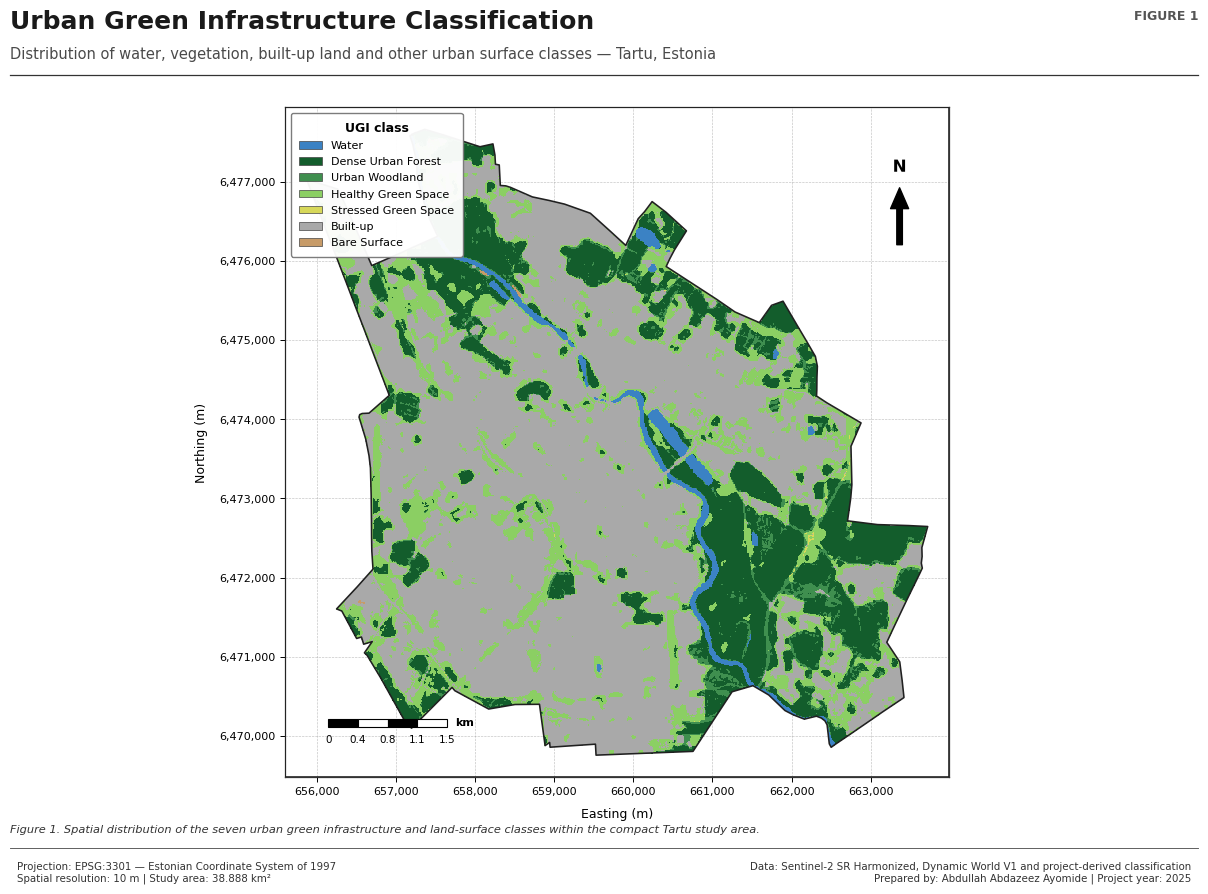

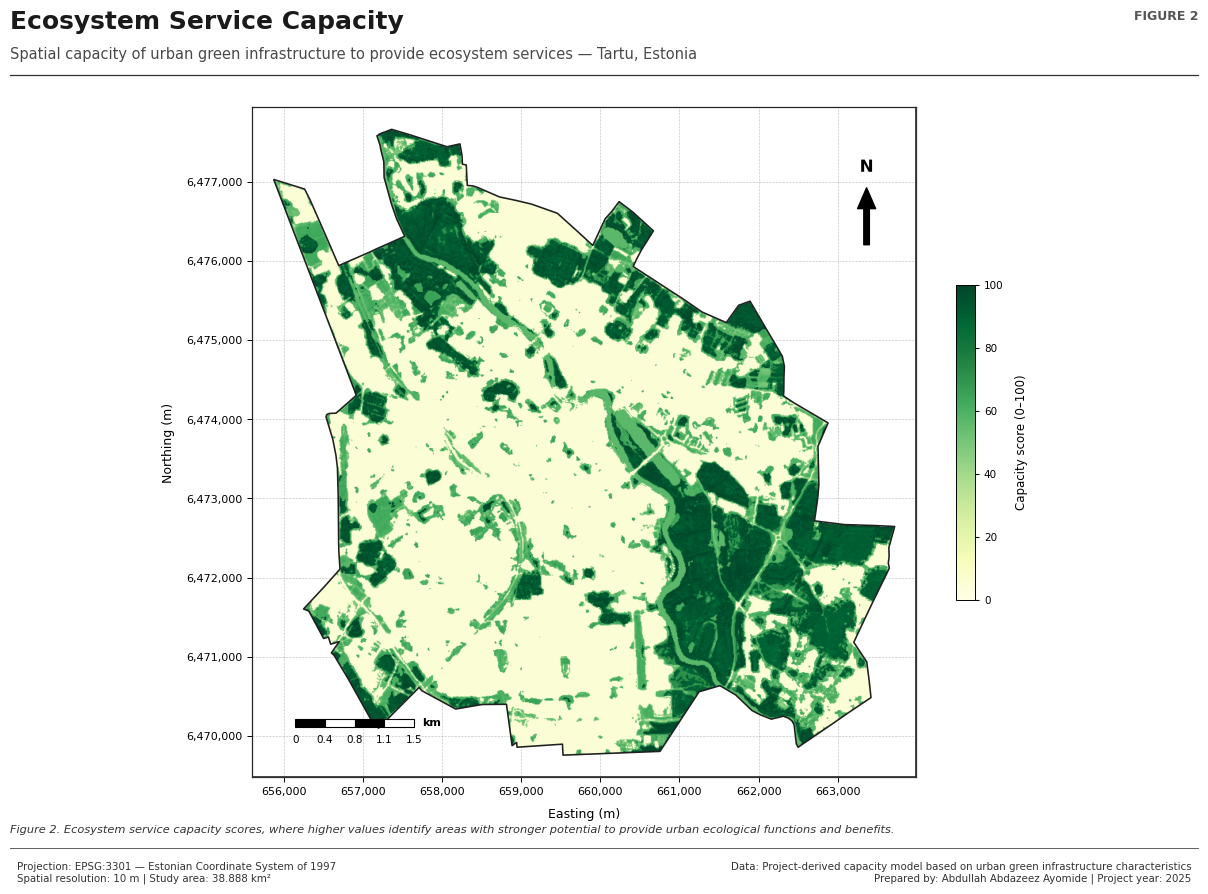

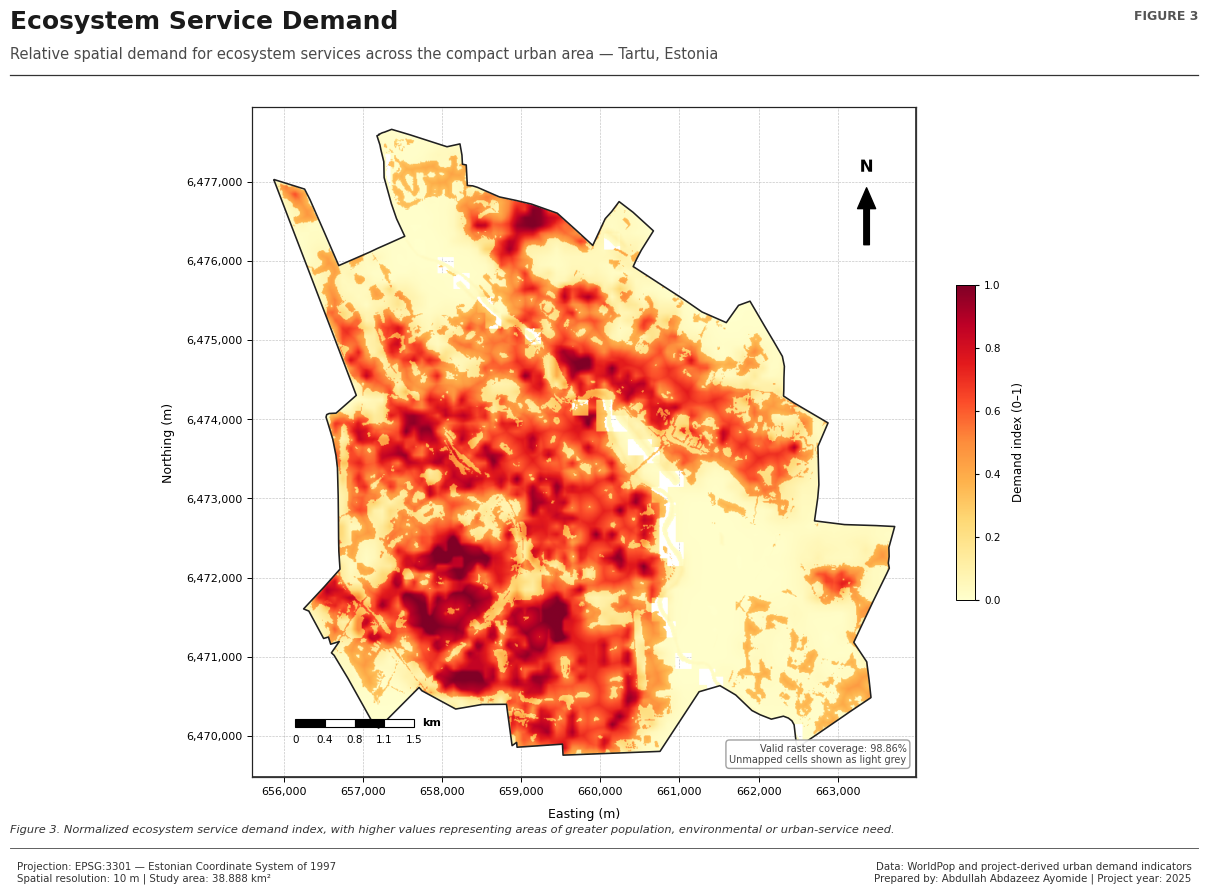

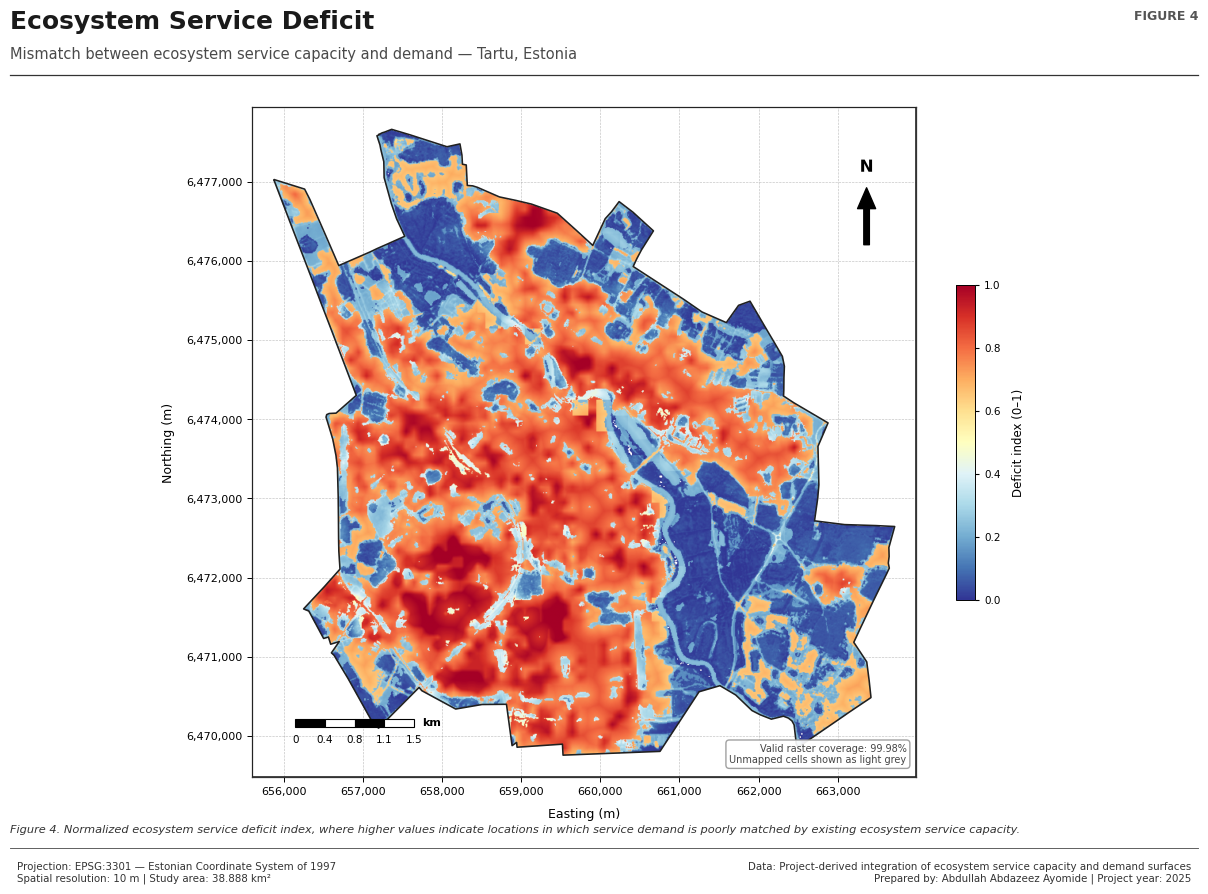

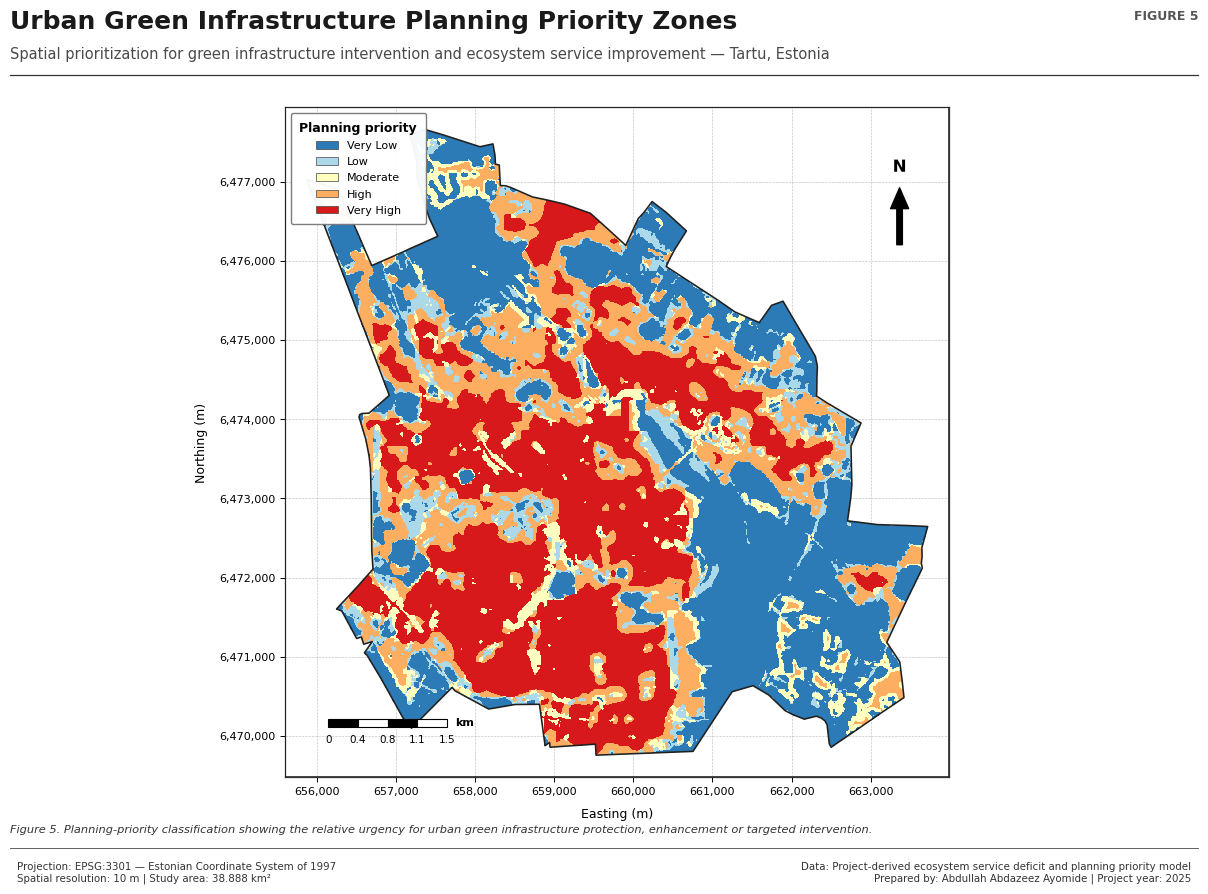


MAP PRODUCTION LOG


,Figure,Map,PNG_Exists,PDF_Exists,PNG,PDF
0,1,Urban Green Infrastructure Classification,True,True,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...
1,2,Ecosystem Service Capacity,True,True,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...
2,3,Ecosystem Service Demand,True,True,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...
3,4,Ecosystem Service Deficit,True,True,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...
4,5,Urban Green Infrastructure Planning Priority Z...,True,True,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...



MAP EXPORT METADATA


/tmp/ipykernel_1368/1501286429.py:610: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  datetime.utcfromtimestamp(


,Figure,Format,File_Name,Exists,File_Size_MB,Pixel_Width,Pixel_Height,Embedded_DPI_X,Embedded_DPI_Y
0,1,PNG,01_Urban_Green_Infrastructure.png,True,0.519,3624.0,2682.0,300.0,300.0
1,1,PDF,01_Urban_Green_Infrastructure.pdf,True,0.109,NaN,NaN,NaN,NaN
2,2,PNG,02_Ecosystem_Service_Capacity.png,True,2.091,3624.0,2682.0,300.0,300.0
3,2,PDF,02_Ecosystem_Service_Capacity.pdf,True,1.600,NaN,NaN,NaN,NaN
4,3,PNG,03_Ecosystem_Service_Demand.png,True,1.983,3624.0,2682.0,300.0,300.0
5,3,PDF,03_Ecosystem_Service_Demand.pdf,True,1.509,NaN,NaN,NaN,NaN
6,4,PNG,04_Ecosystem_Service_Deficit.png,True,2.871,3624.0,2682.0,300.0,300.0
7,4,PDF,04_Ecosystem_Service_Deficit.pdf,True,2.262,NaN,NaN,NaN,NaN
8,5,PNG,05_Planning_Priority_Zones.png,True,0.505,3624.0,2682.0,300.0,300.0
9,5,PDF,05_Planning_Priority_Zones.pdf,True,0.108,NaN,NaN,NaN,NaN



SECTION 8 — FINAL MAP PRODUCTION COMPLETE
Maps generated             : 5
PNG files generated        : 5
PDF files generated        : 5
Verified output files      : 10/10
Minimum dimensions passed  : True
Embedded DPI check passed  : True

Production records:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/09_Validation/Final_Map_Production_Log.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/09_Validation/Final_Map_Export_Metadata.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_Map_Captions.csv

✓ Transparent masked-data display applied.
✓ Authoritative study-area boundary retained.
✓ Neatlines and figure numbering added.
✓ Report-ready captions generated.
✓ Five PNG maps exported at 300 DPI.
✓ Five corresponding PDF maps exported.
✓ File dimensions, sizes and timestamps documented.
✓ Final cartographic production completed.


In [13]:
# ==============================================================================
# SECTION 8 — ENHANCED FINAL MAP PRODUCTION
# ==============================================================================

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from PIL import Image
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

print("=" * 110)
print("SECTION 8 — ENHANCED FINAL MAP PRODUCTION")
print("=" * 110)


# ==============================================================================
# OUTPUT FOLDERS
# ==============================================================================

MAP_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ==============================================================================
# TRANSPARENT MASKED-DATA COLOUR MAPS
# ==============================================================================

def transparent_cmap(cmap):
    """
    Return a copy of a Matplotlib colormap with masked pixels transparent.
    """
    copied_cmap = copy.copy(plt.get_cmap(cmap))
    copied_cmap.set_bad((1, 1, 1, 0))
    return copied_cmap


UGI_CMAP_FINAL = ListedColormap(UGI_COLORS)
UGI_CMAP_FINAL.set_bad((1, 1, 1, 0))

PRIORITY_CMAP_FINAL = ListedColormap(PRIORITY_COLORS)
PRIORITY_CMAP_FINAL.set_bad((1, 1, 1, 0))

ESC_CMAP_FINAL = transparent_cmap("YlGn")
DEMAND_CMAP_FINAL = transparent_cmap("YlOrRd")
DEFICIT_CMAP_FINAL = transparent_cmap("RdYlBu_r")


# ==============================================================================
# ENHANCED CARTOGRAPHIC COMPONENTS
# ==============================================================================

def add_neatline(ax):
    """
    Add a clean frame around the mapped extent.
    """

    width = MAP_EXTENT["xmax"] - MAP_EXTENT["xmin"]
    height = MAP_EXTENT["ymax"] - MAP_EXTENT["ymin"]

    neatline = Rectangle(
        (
            MAP_EXTENT["xmin"],
            MAP_EXTENT["ymin"]
        ),
        width,
        height,
        fill=False,
        edgecolor="#202020",
        linewidth=1.15,
        zorder=50
    )

    ax.add_patch(neatline)


def add_figure_identifier(fig, figure_number):
    """
    Add a consistent figure number in the title area.
    """

    fig.text(
        0.95,
        0.965,
        f"FIGURE {figure_number}",
        ha="right",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#555555"
    )


def add_map_caption(fig, caption):
    """
    Add a concise report-ready caption immediately above the footer.
    """

    fig.text(
        0.05,
        0.078,
        caption,
        ha="left",
        va="bottom",
        fontsize=8.2,
        color="#333333",
        style="italic"
    )


def configure_enhanced_map_axis(ax):
    """
    Configure a clean professional map frame.
    """

    configure_map_axis(ax)

    # White background outside the masked study area
    ax.set_facecolor("white")

    add_neatline(ax)


# ==============================================================================
# ENHANCED MAP-SAVING FUNCTION
# ==============================================================================

def save_enhanced_map_outputs(fig, output_stem):
    """
    Export publication-quality PNG and PDF files.
    """

    png_path = MAP_DIR / f"{output_stem}.png"
    pdf_path = MAP_DIR / f"{output_stem}.pdf"

    fig.savefig(
        png_path,
        dpi=MAP_CONFIG["dpi"],
        bbox_inches="tight",
        facecolor="white",
        transparent=False,
        metadata={
            "Title": output_stem.replace("_", " "),
            "Author": MAP_CONFIG["author"],
            "Subject": PROJECT_NAME,
            "Keywords": (
                "Tartu, urban green infrastructure, ecosystem services, "
                "GIS, spatial planning"
            )
        }
    )

    fig.savefig(
        pdf_path,
        dpi=MAP_CONFIG["dpi"],
        bbox_inches="tight",
        facecolor="white",
        transparent=False,
        metadata={
            "Title": output_stem.replace("_", " "),
            "Author": MAP_CONFIG["author"],
            "Subject": PROJECT_NAME,
            "Keywords": (
                "Tartu, urban green infrastructure, ecosystem services, "
                "GIS, spatial planning"
            )
        }
    )

    return png_path, pdf_path


# ==============================================================================
# ENHANCED CATEGORICAL MAP ENGINE
# ==============================================================================

def create_enhanced_categorical_map(
    array,
    title,
    subtitle,
    caption,
    figure_number,
    cmap,
    norm,
    class_dictionary,
    colors,
    legend_title,
    output_stem,
    source_note=None
):
    """
    Create a numbered, report-ready categorical map.
    """

    fig, ax = plt.subplots(
        figsize=MAP_CONFIG["figure_size"]
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.94,
        bottom=0.14,
        top=0.86
    )

    ax.imshow(
        array,
        cmap=cmap,
        norm=norm,
        extent=RASTER_EXTENT,
        origin="upper",
        interpolation="nearest",
        zorder=5
    )

    add_boundary_outline(ax)
    configure_enhanced_map_axis(ax)
    add_scale_bar(ax, MAP_EXTENT)
    add_north_arrow(ax)

    add_categorical_legend(
        ax=ax,
        class_dictionary=class_dictionary,
        colors=colors,
        title=legend_title,
        location="upper left"
    )

    add_no_data_note(ax, array)

    add_title_block(
        fig,
        title,
        subtitle
    )

    add_figure_identifier(
        fig,
        figure_number
    )

    add_map_caption(
        fig,
        caption
    )

    add_map_footer(
        fig,
        source_note=source_note
    )

    png_path, pdf_path = save_enhanced_map_outputs(
        fig,
        output_stem
    )

    plt.show()
    plt.close(fig)

    return {
        "Figure": figure_number,
        "Map": title,
        "Output_Stem": output_stem,
        "Caption": caption,
        "PNG": str(png_path),
        "PDF": str(pdf_path),
        "PNG_Exists": png_path.exists(),
        "PDF_Exists": pdf_path.exists()
    }


# ==============================================================================
# ENHANCED CONTINUOUS MAP ENGINE
# ==============================================================================

def create_enhanced_continuous_map(
    array,
    title,
    subtitle,
    caption,
    figure_number,
    cmap,
    vmin,
    vmax,
    colorbar_label,
    output_stem,
    source_note=None
):
    """
    Create a numbered, report-ready continuous map.
    """

    fig, ax = plt.subplots(
        figsize=MAP_CONFIG["figure_size"]
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.89,
        bottom=0.14,
        top=0.86
    )

    image = ax.imshow(
        array,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=RASTER_EXTENT,
        origin="upper",
        interpolation="bilinear",
        zorder=5
    )

    add_boundary_outline(ax)
    configure_enhanced_map_axis(ax)
    add_scale_bar(ax, MAP_EXTENT)
    add_north_arrow(ax)
    add_no_data_note(ax, array)

    colorbar_axis = inset_axes(
        ax,
        width="2.8%",
        height="47%",
        loc="center right",
        bbox_to_anchor=(0.088, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    colorbar = fig.colorbar(
        image,
        cax=colorbar_axis,
        orientation="vertical"
    )

    colorbar.set_label(
        colorbar_label,
        fontsize=8.5,
        labelpad=8
    )

    colorbar.ax.tick_params(
        labelsize=7.5,
        length=3
    )

    colorbar.outline.set_linewidth(0.7)

    add_title_block(
        fig,
        title,
        subtitle
    )

    add_figure_identifier(
        fig,
        figure_number
    )

    add_map_caption(
        fig,
        caption
    )

    add_map_footer(
        fig,
        source_note=source_note
    )

    png_path, pdf_path = save_enhanced_map_outputs(
        fig,
        output_stem
    )

    plt.show()
    plt.close(fig)

    return {
        "Figure": figure_number,
        "Map": title,
        "Output_Stem": output_stem,
        "Caption": caption,
        "PNG": str(png_path),
        "PDF": str(pdf_path),
        "PNG_Exists": png_path.exists(),
        "PDF_Exists": pdf_path.exists()
    }


# ==============================================================================
# FINAL MAP DEFINITIONS AND CAPTIONS
# ==============================================================================

map_results = []


# ------------------------------------------------------------------------------
# FIGURE 1 — URBAN GREEN INFRASTRUCTURE
# ------------------------------------------------------------------------------

map_results.append(
    create_enhanced_categorical_map(
        array=ugi_map,
        title="Urban Green Infrastructure Classification",
        subtitle=(
            "Distribution of water, vegetation, built-up land and "
            "other urban surface classes — Tartu, Estonia"
        ),
        caption=(
            "Figure 1. Spatial distribution of the seven urban green "
            "infrastructure and land-surface classes within the compact "
            "Tartu study area."
        ),
        figure_number=1,
        cmap=UGI_CMAP_FINAL,
        norm=UGI_NORM,
        class_dictionary=UGI_CLASSES,
        colors=UGI_COLORS,
        legend_title="UGI class",
        output_stem="01_Urban_Green_Infrastructure",
        source_note=(
            "Sentinel-2 SR Harmonized, Dynamic World V1 and "
            "project-derived classification"
        )
    )
)


# ------------------------------------------------------------------------------
# FIGURE 2 — ECOSYSTEM SERVICE CAPACITY
# ------------------------------------------------------------------------------

map_results.append(
    create_enhanced_continuous_map(
        array=esc_map,
        title="Ecosystem Service Capacity",
        subtitle=(
            "Spatial capacity of urban green infrastructure to provide "
            "ecosystem services — Tartu, Estonia"
        ),
        caption=(
            "Figure 2. Ecosystem service capacity scores, where higher "
            "values identify areas with stronger potential to provide "
            "urban ecological functions and benefits."
        ),
        figure_number=2,
        cmap=ESC_CMAP_FINAL,
        vmin=0,
        vmax=100,
        colorbar_label="Capacity score (0–100)",
        output_stem="02_Ecosystem_Service_Capacity",
        source_note=(
            "Project-derived capacity model based on urban green "
            "infrastructure characteristics"
        )
    )
)


# ------------------------------------------------------------------------------
# FIGURE 3 — ECOSYSTEM SERVICE DEMAND
# ------------------------------------------------------------------------------

map_results.append(
    create_enhanced_continuous_map(
        array=demand_map,
        title="Ecosystem Service Demand",
        subtitle=(
            "Relative spatial demand for ecosystem services across the "
            "compact urban area — Tartu, Estonia"
        ),
        caption=(
            "Figure 3. Normalized ecosystem service demand index, with "
            "higher values representing areas of greater population, "
            "environmental or urban-service need."
        ),
        figure_number=3,
        cmap=DEMAND_CMAP_FINAL,
        vmin=0,
        vmax=1,
        colorbar_label="Demand index (0–1)",
        output_stem="03_Ecosystem_Service_Demand",
        source_note=(
            "WorldPop and project-derived urban demand indicators"
        )
    )
)


# ------------------------------------------------------------------------------
# FIGURE 4 — ECOSYSTEM SERVICE DEFICIT
# ------------------------------------------------------------------------------

map_results.append(
    create_enhanced_continuous_map(
        array=deficit_map,
        title="Ecosystem Service Deficit",
        subtitle=(
            "Mismatch between ecosystem service capacity and demand — "
            "Tartu, Estonia"
        ),
        caption=(
            "Figure 4. Normalized ecosystem service deficit index, where "
            "higher values indicate locations in which service demand is "
            "poorly matched by existing ecosystem service capacity."
        ),
        figure_number=4,
        cmap=DEFICIT_CMAP_FINAL,
        vmin=0,
        vmax=1,
        colorbar_label="Deficit index (0–1)",
        output_stem="04_Ecosystem_Service_Deficit",
        source_note=(
            "Project-derived integration of ecosystem service capacity "
            "and demand surfaces"
        )
    )
)


# ------------------------------------------------------------------------------
# FIGURE 5 — PLANNING PRIORITY ZONES
# ------------------------------------------------------------------------------

map_results.append(
    create_enhanced_categorical_map(
        array=priority_map,
        title="Urban Green Infrastructure Planning Priority Zones",
        subtitle=(
            "Spatial prioritization for green infrastructure intervention "
            "and ecosystem service improvement — Tartu, Estonia"
        ),
        caption=(
            "Figure 5. Planning-priority classification showing the "
            "relative urgency for urban green infrastructure protection, "
            "enhancement or targeted intervention."
        ),
        figure_number=5,
        cmap=PRIORITY_CMAP_FINAL,
        norm=PRIORITY_NORM,
        class_dictionary=PRIORITY_CLASSES,
        colors=PRIORITY_COLORS,
        legend_title="Planning priority",
        output_stem="05_Planning_Priority_Zones",
        source_note=(
            "Project-derived ecosystem service deficit and planning "
            "priority model"
        )
    )
)


# ==============================================================================
# MAP PRODUCTION LOG
# ==============================================================================

map_production_log = pd.DataFrame(map_results)

print("\n" + "=" * 110)
print("MAP PRODUCTION LOG")
print("=" * 110)

display(
    map_production_log[
        [
            "Figure",
            "Map",
            "PNG_Exists",
            "PDF_Exists",
            "PNG",
            "PDF"
        ]
    ]
)


# ==============================================================================
# FILE METADATA VALIDATION
# ==============================================================================

metadata_rows = []

for result in map_results:

    for file_type in ["PNG", "PDF"]:

        file_path = Path(result[file_type])

        metadata_record = {
            "Figure": result["Figure"],
            "Map": result["Map"],
            "Format": file_type,
            "File_Name": file_path.name,
            "File_Path": str(file_path),
            "Exists": file_path.exists(),
            "File_Size_MB": (
                file_path.stat().st_size / (1024 ** 2)
                if file_path.exists()
                else np.nan
            ),
            "Modified_UTC": (
                datetime.utcfromtimestamp(
                    file_path.stat().st_mtime
                ).strftime("%Y-%m-%d %H:%M:%S")
                if file_path.exists()
                else None
            ),
            "Pixel_Width": None,
            "Pixel_Height": None,
            "Embedded_DPI_X": None,
            "Embedded_DPI_Y": None,
        }

        if file_type == "PNG" and file_path.exists():

            with Image.open(file_path) as image:

                metadata_record["Pixel_Width"] = image.width
                metadata_record["Pixel_Height"] = image.height

                dpi_value = image.info.get("dpi")

                if dpi_value:
                    metadata_record["Embedded_DPI_X"] = round(
                        float(dpi_value[0]),
                        2
                    )
                    metadata_record["Embedded_DPI_Y"] = round(
                        float(dpi_value[1]),
                        2
                    )

        metadata_rows.append(metadata_record)


map_export_metadata = pd.DataFrame(metadata_rows)

print("\n" + "=" * 110)
print("MAP EXPORT METADATA")
print("=" * 110)

display(
    map_export_metadata[
        [
            "Figure",
            "Format",
            "File_Name",
            "Exists",
            "File_Size_MB",
            "Pixel_Width",
            "Pixel_Height",
            "Embedded_DPI_X",
            "Embedded_DPI_Y"
        ]
    ].round({
        "File_Size_MB": 3
    })
)


# ==============================================================================
# EXPORT CAPTIONS, LOGS AND METADATA
# ==============================================================================

MAP_PRODUCTION_LOG_FILE = (
    VALIDATION_DIR / "Final_Map_Production_Log.csv"
)

MAP_EXPORT_METADATA_FILE = (
    VALIDATION_DIR / "Final_Map_Export_Metadata.csv"
)

MAP_CAPTIONS_FILE = (
    TABLE_DIR / "Final_Map_Captions.csv"
)

map_production_log.to_csv(
    MAP_PRODUCTION_LOG_FILE,
    index=False
)

map_export_metadata.to_csv(
    MAP_EXPORT_METADATA_FILE,
    index=False
)

map_production_log[
    [
        "Figure",
        "Map",
        "Output_Stem",
        "Caption"
    ]
].to_csv(
    MAP_CAPTIONS_FILE,
    index=False
)


# ==============================================================================
# DEFINITIVE VALIDATION
# ==============================================================================

expected_output_count = 10

existing_output_count = int(
    map_export_metadata["Exists"].sum()
)

missing_files = map_export_metadata.loc[
    ~map_export_metadata["Exists"],
    "File_Path"
].tolist()

png_metadata = map_export_metadata[
    map_export_metadata["Format"] == "PNG"
]

dpi_validation = (
    png_metadata["Embedded_DPI_X"]
    .fillna(0)
    .between(299, 301)
    .all()
)

dimension_validation = (
    (png_metadata["Pixel_Width"] >= 3000)
    & (png_metadata["Pixel_Height"] >= 2000)
).all()

if existing_output_count != expected_output_count:
    raise FileNotFoundError(
        f"Expected {expected_output_count} final map files but found "
        f"{existing_output_count}. Missing files: {missing_files}"
    )

if not dimension_validation:
    raise ValueError(
        "One or more PNG outputs do not meet the minimum production "
        "dimensions of 3000 × 2000 pixels."
    )

if not dpi_validation:
    print(
        "\nWarning: The PNG reader did not report exactly 300 DPI for "
        "every image. The files were nevertheless exported using "
        "Matplotlib's dpi=300 setting."
    )


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 8 — FINAL MAP PRODUCTION COMPLETE")
print("=" * 110)

print(f"Maps generated             : {len(map_results)}")
print(f"PNG files generated        : {(map_export_metadata['Format'] == 'PNG').sum()}")
print(f"PDF files generated        : {(map_export_metadata['Format'] == 'PDF').sum()}")
print(f"Verified output files      : {existing_output_count}/{expected_output_count}")
print(f"Minimum dimensions passed  : {dimension_validation}")
print(f"Embedded DPI check passed  : {dpi_validation}")

print("\nProduction records:")
print(f"  {MAP_PRODUCTION_LOG_FILE}")
print(f"  {MAP_EXPORT_METADATA_FILE}")
print(f"  {MAP_CAPTIONS_FILE}")

print("\n✓ Transparent masked-data display applied.")
print("✓ Authoritative study-area boundary retained.")
print("✓ Neatlines and figure numbering added.")
print("✓ Report-ready captions generated.")
print("✓ Five PNG maps exported at 300 DPI.")
print("✓ Five corresponding PDF maps exported.")
print("✓ File dimensions, sizes and timestamps documented.")
print("✓ Final cartographic production completed.")

SECTION 9 — FINAL STATISTICAL TABLES AND CHARTS

URBAN GREEN INFRASTRUCTURE STATISTICS


,Dataset,Code,Class,Pixels,Area_ha,Area_km2,Percent
0,Urban Green Infrastructure,1,Water,8279,82.79,0.828,2.129
1,Urban Green Infrastructure,2,Dense Urban Forest,85492,854.92,8.549,21.985
2,Urban Green Infrastructure,3,Urban Woodland,12951,129.51,1.295,3.330
3,Urban Green Infrastructure,4,Healthy Green Space,67589,675.89,6.759,17.381
4,Urban Green Infrastructure,5,Stressed Green Space,162,1.62,0.016,0.042
5,Urban Green Infrastructure,6,Built-up,214260,2142.60,21.426,55.098
6,Urban Green Infrastructure,7,Bare Surface,139,1.39,0.014,0.036



PLANNING PRIORITY STATISTICS


,Dataset,Code,Class,Pixels,Area_ha,Area_km2,Percent
0,Planning Priority,1,Very Low,125120,1251.20,12.512,32.175
1,Planning Priority,2,Low,32101,321.01,3.210,8.255
2,Planning Priority,3,Moderate,29347,293.47,2.935,7.547
3,Planning Priority,4,High,81387,813.87,8.139,20.929
4,Planning Priority,5,Very High,120917,1209.17,12.092,31.094



CONTINUOUS RASTER STATISTICS


,Dataset,Valid_Cells,Area_ha,Area_km2,Minimum,P05,P25,Median,Mean,P75,P95,Maximum,Standard_Deviation
0,Ecosystem Service Capacity,388872,3888.72,38.887,5.0000,5.0000,5.0000,5.0000,36.7103,64.8977,95.8880,98.75,37.1260
1,Ecosystem Service Demand,384441,3844.41,38.444,0.0004,0.0076,0.0527,0.4056,0.3787,0.6298,0.8534,1.00,0.2978
2,Ecosystem Service Deficit,388798,3887.98,38.880,0.0001,0.0270,0.1964,0.6853,0.5135,0.8079,0.9237,1.00,0.3345



CROSS-DATASET CORRELATION MATRIX


,Capacity,Demand,Deficit
Capacity,1.0000,-0.8686,-0.9735
Demand,-0.8686,1.0000,0.9588
Deficit,-0.9735,0.9588,1.0000



DEFICIT BY PLANNING-PRIORITY CLASS


,Priority_Code,Priority_Class,Pixels,Area_ha,Area_km2,Mean_Deficit,Median_Deficit
0,1,Very Low,120860,1208.60,12.086,0.1038,0.0651
1,2,Low,32019,320.19,3.202,0.2900,0.2754
2,3,Moderate,29260,292.60,2.926,0.4997,0.4336
3,4,High,81386,813.86,8.139,0.7246,0.7394
4,5,Very High,120916,1209.16,12.092,0.8585,0.8463


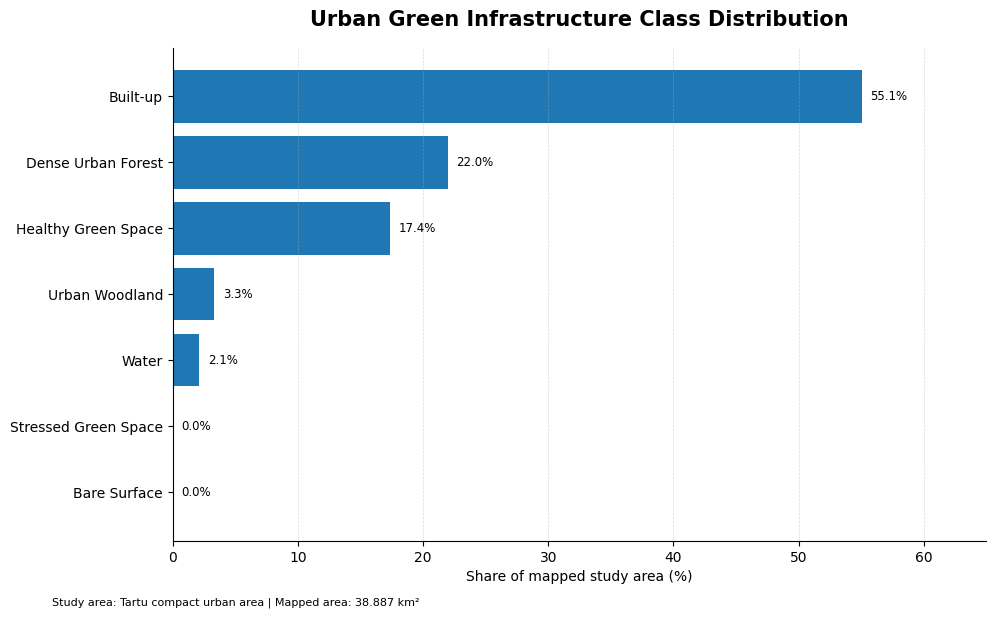

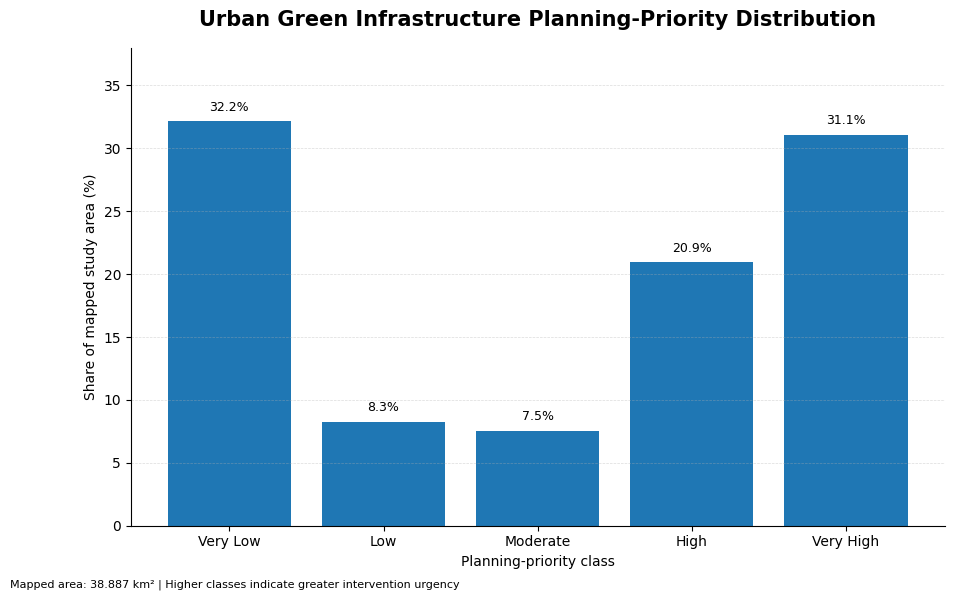

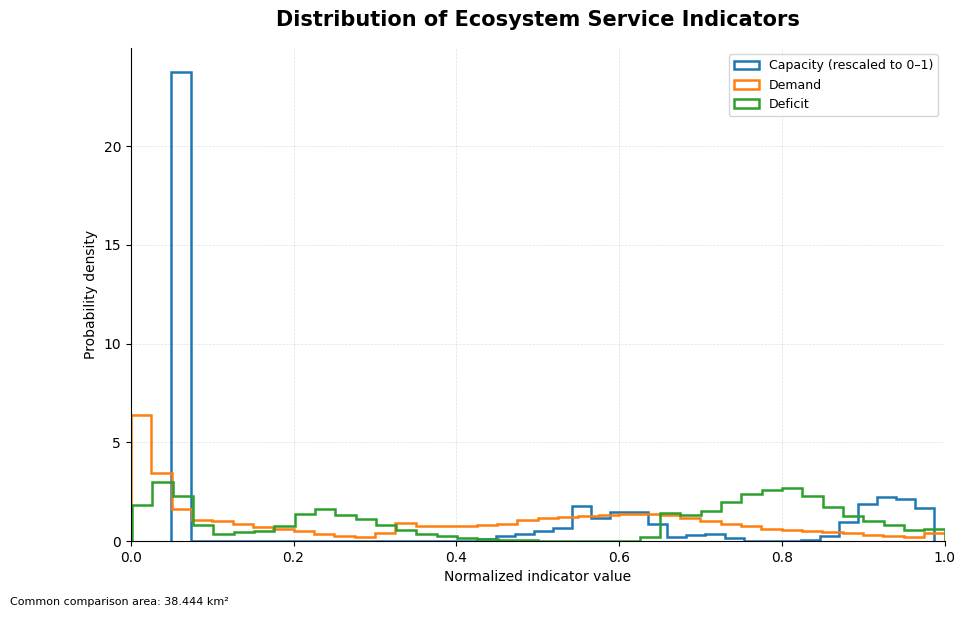

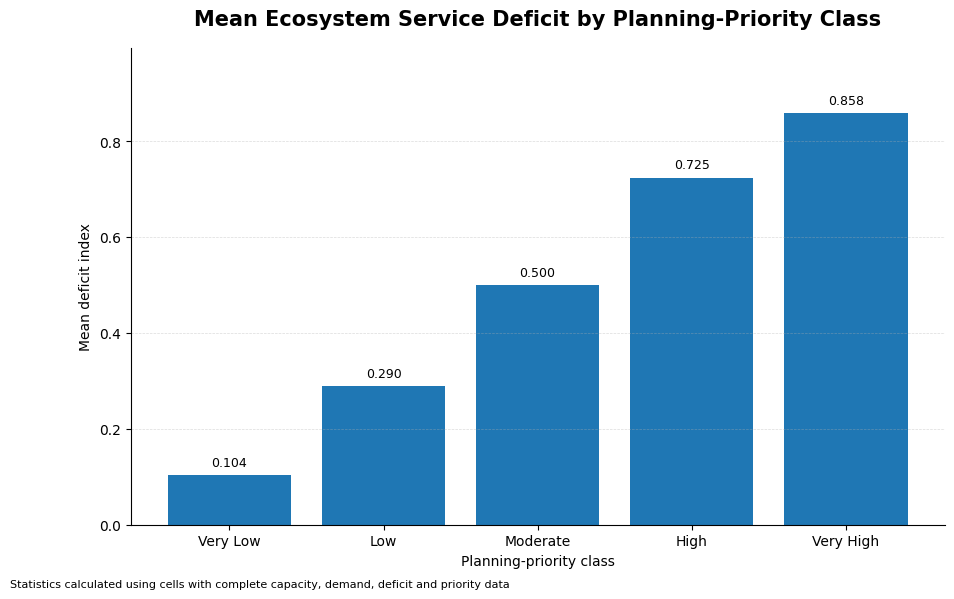

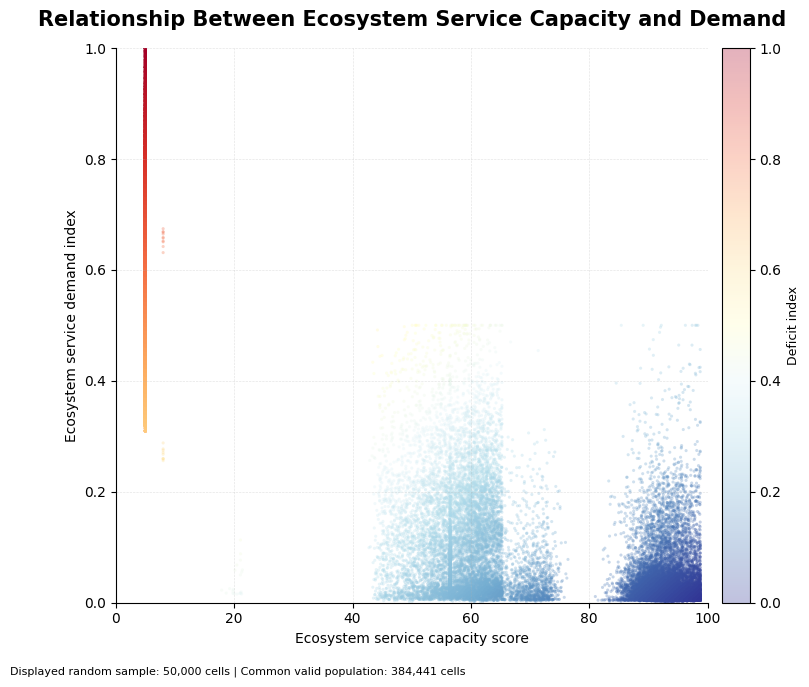


CHART PRODUCTION LOG


,Chart,PNG,PNG_Exists,PNG_Size_MB,PDF,PDF_Exists,PDF_Size_MB
0,UGI Class Distribution,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.175,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.024
1,Planning Priority Distribution,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.154,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.024
2,Ecosystem Service Indicator Distributions,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.138,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.024
3,Mean Deficit by Planning Priority,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.138,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.023
4,Capacity–Demand–Deficit Relationship,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.723,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,1.248



SECTION 9 — FINAL STATISTICS AND CHARTS COMPLETE
UGI mapped area                  : 38.887 km²
Priority mapped area             : 38.887 km²
Common cross-dataset area        : 38.444 km²
UGI percentage total             : 100.000%
Priority percentage total        : 100.000%
Charts generated                 : 5
PNG/PDF chart files verified     : 10/10

Final tables:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_UGI_Class_Statistics.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_Planning_Priority_Statistics.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_Continuous_Raster_Statistics.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_Indicator_Correlation_Matrix.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/

In [14]:
# ==============================================================================
# SECTION 9 — FINAL STATISTICAL TABLES AND CHARTS
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.ticker import PercentFormatter

print("=" * 110)
print("SECTION 9 — FINAL STATISTICAL TABLES AND CHARTS")
print("=" * 110)

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)


# ==============================================================================
# GENERAL HELPERS
# ==============================================================================

def calculate_categorical_statistics(
    array,
    class_dictionary,
    dataset_name
):
    """
    Calculate definitive area and percentage statistics for a categorical raster.
    """

    values = array.compressed().astype(int)

    total_cells = len(values)
    total_area_ha = total_cells * pixel_area_m2 / 10_000
    total_area_km2 = total_cells * pixel_area_m2 / 1_000_000

    records = []

    for code, class_name in class_dictionary.items():

        cell_count = int(np.sum(values == code))
        area_ha = cell_count * pixel_area_m2 / 10_000
        area_km2 = cell_count * pixel_area_m2 / 1_000_000
        percent = cell_count / total_cells * 100 if total_cells else 0

        records.append({
            "Dataset": dataset_name,
            "Code": code,
            "Class": class_name,
            "Pixels": cell_count,
            "Area_ha": area_ha,
            "Area_km2": area_km2,
            "Percent": percent,
        })

    statistics = pd.DataFrame(records)

    return statistics, {
        "Valid_Cells": total_cells,
        "Total_Area_ha": total_area_ha,
        "Total_Area_km2": total_area_km2,
    }


def calculate_continuous_statistics(
    array,
    dataset_name
):
    """
    Calculate descriptive statistics for a continuous raster.
    """

    values = array.compressed().astype(float)

    return {
        "Dataset": dataset_name,
        "Valid_Cells": len(values),
        "Area_ha": len(values) * pixel_area_m2 / 10_000,
        "Area_km2": len(values) * pixel_area_m2 / 1_000_000,
        "Minimum": np.min(values),
        "P05": np.percentile(values, 5),
        "P25": np.percentile(values, 25),
        "Median": np.median(values),
        "Mean": np.mean(values),
        "P75": np.percentile(values, 75),
        "P95": np.percentile(values, 95),
        "Maximum": np.max(values),
        "Standard_Deviation": np.std(values),
    }


def save_chart(fig, output_stem):
    """
    Save each chart as PNG and PDF.
    """

    png_path = CHART_DIR / f"{output_stem}.png"
    pdf_path = CHART_DIR / f"{output_stem}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white"
    )

    return png_path, pdf_path


def add_bar_labels(
    ax,
    bars,
    values,
    suffix="",
    decimals=1
):
    """
    Add readable labels to chart bars.
    """

    maximum = max(values) if len(values) else 0

    for bar, value in zip(bars, values):

        ax.text(
            bar.get_width() + maximum * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.{decimals}f}{suffix}",
            va="center",
            ha="left",
            fontsize=8.5
        )


# ==============================================================================
# DEFINITIVE CATEGORICAL STATISTICS
# ==============================================================================

ugi_final_stats, ugi_summary = calculate_categorical_statistics(
    array=ugi_map,
    class_dictionary=UGI_CLASSES,
    dataset_name="Urban Green Infrastructure"
)

priority_final_stats, priority_summary = calculate_categorical_statistics(
    array=priority_map,
    class_dictionary=PRIORITY_CLASSES,
    dataset_name="Planning Priority"
)

print("\nURBAN GREEN INFRASTRUCTURE STATISTICS")
display(
    ugi_final_stats.round({
        "Area_ha": 2,
        "Area_km2": 3,
        "Percent": 3,
    })
)

print("\nPLANNING PRIORITY STATISTICS")
display(
    priority_final_stats.round({
        "Area_ha": 2,
        "Area_km2": 3,
        "Percent": 3,
    })
)


# ==============================================================================
# DEFINITIVE CONTINUOUS-RASTER STATISTICS
# ==============================================================================

continuous_statistics = pd.DataFrame([
    calculate_continuous_statistics(
        esc_map,
        "Ecosystem Service Capacity"
    ),
    calculate_continuous_statistics(
        demand_map,
        "Ecosystem Service Demand"
    ),
    calculate_continuous_statistics(
        deficit_map,
        "Ecosystem Service Deficit"
    ),
])

print("\nCONTINUOUS RASTER STATISTICS")
display(
    continuous_statistics.round({
        "Area_ha": 2,
        "Area_km2": 3,
        "Minimum": 4,
        "P05": 4,
        "P25": 4,
        "Median": 4,
        "Mean": 4,
        "P75": 4,
        "P95": 4,
        "Maximum": 4,
        "Standard_Deviation": 4,
    })
)


# ==============================================================================
# CROSS-DATASET STATISTICS USING THE COMMON MASK
# ==============================================================================

esc_common_values = esc_project.compressed().astype(float)
demand_common_values = demand_project.compressed().astype(float)
deficit_common_values = deficit_project.compressed().astype(float)
priority_common_values = priority_project.compressed().astype(int)

cross_dataset_correlations = pd.DataFrame(
    np.corrcoef([
        esc_common_values,
        demand_common_values,
        deficit_common_values
    ]),
    index=[
        "Capacity",
        "Demand",
        "Deficit"
    ],
    columns=[
        "Capacity",
        "Demand",
        "Deficit"
    ]
)

priority_deficit_summary = []

for priority_code, priority_name in PRIORITY_CLASSES.items():

    selector = priority_common_values == priority_code
    selected_values = deficit_common_values[selector]

    priority_deficit_summary.append({
        "Priority_Code": priority_code,
        "Priority_Class": priority_name,
        "Pixels": int(selector.sum()),
        "Area_ha": selector.sum() * pixel_area_m2 / 10_000,
        "Area_km2": selector.sum() * pixel_area_m2 / 1_000_000,
        "Mean_Deficit": (
            float(np.mean(selected_values))
            if selected_values.size
            else np.nan
        ),
        "Median_Deficit": (
            float(np.median(selected_values))
            if selected_values.size
            else np.nan
        ),
    })

priority_deficit_summary = pd.DataFrame(
    priority_deficit_summary
)

print("\nCROSS-DATASET CORRELATION MATRIX")
display(cross_dataset_correlations.round(4))

print("\nDEFICIT BY PLANNING-PRIORITY CLASS")
display(
    priority_deficit_summary.round({
        "Area_ha": 2,
        "Area_km2": 3,
        "Mean_Deficit": 4,
        "Median_Deficit": 4,
    })
)


# ==============================================================================
# CHART 1 — UGI CLASS DISTRIBUTION
# ==============================================================================

ugi_chart_data = ugi_final_stats.sort_values(
    "Percent",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10.5, 6.4))

bars = ax.barh(
    ugi_chart_data["Class"],
    ugi_chart_data["Percent"]
)

add_bar_labels(
    ax,
    bars,
    ugi_chart_data["Percent"].values,
    suffix="%",
    decimals=1
)

ax.set_title(
    "Urban Green Infrastructure Class Distribution",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Share of mapped study area (%)",
    fontsize=10
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    max(ugi_chart_data["Percent"]) * 1.18
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    alpha=0.45
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Study area: Tartu compact urban area | "
        f"Mapped area: {ugi_summary['Total_Area_km2']:.3f} km²"
    ),
    fontsize=8
)

chart1_png, chart1_pdf = save_chart(
    fig,
    "01_UGI_Class_Distribution"
)

plt.show()
plt.close(fig)


# ==============================================================================
# CHART 2 — PLANNING PRIORITY DISTRIBUTION
# ==============================================================================

priority_chart_data = priority_final_stats.copy()

fig, ax = plt.subplots(figsize=(10.5, 6.2))

bars = ax.bar(
    priority_chart_data["Class"],
    priority_chart_data["Percent"]
)

for bar, value in zip(
    bars,
    priority_chart_data["Percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Urban Green Infrastructure Planning-Priority Distribution",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_ylabel(
    "Share of mapped study area (%)",
    fontsize=10
)

ax.set_xlabel(
    "Planning-priority class",
    fontsize=10
)

ax.set_ylim(
    0,
    max(priority_chart_data["Percent"]) * 1.18
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.45
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Mapped area: {priority_summary['Total_Area_km2']:.3f} km² | "
        "Higher classes indicate greater intervention urgency"
    ),
    fontsize=8
)

chart2_png, chart2_pdf = save_chart(
    fig,
    "02_Planning_Priority_Distribution"
)

plt.show()
plt.close(fig)


# ==============================================================================
# CHART 3 — CAPACITY, DEMAND AND DEFICIT DISTRIBUTIONS
# ==============================================================================

fig, ax = plt.subplots(figsize=(10.5, 6.4))

ax.hist(
    esc_common_values / 100,
    bins=40,
    density=True,
    histtype="step",
    linewidth=1.8,
    label="Capacity (rescaled to 0–1)"
)

ax.hist(
    demand_common_values,
    bins=40,
    density=True,
    histtype="step",
    linewidth=1.8,
    label="Demand"
)

ax.hist(
    deficit_common_values,
    bins=40,
    density=True,
    histtype="step",
    linewidth=1.8,
    label="Deficit"
)

ax.set_title(
    "Distribution of Ecosystem Service Indicators",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Normalized indicator value",
    fontsize=10
)

ax.set_ylabel(
    "Probability density",
    fontsize=10
)

ax.set_xlim(0, 1)

ax.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.legend(
    frameon=True,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Common comparison area: "
        f"{authoritative_valid_area_km2:.3f} km²"
    ),
    fontsize=8
)

chart3_png, chart3_pdf = save_chart(
    fig,
    "03_Ecosystem_Service_Indicator_Distributions"
)

plt.show()
plt.close(fig)


# ==============================================================================
# CHART 4 — MEAN DEFICIT BY PRIORITY CLASS
# ==============================================================================

fig, ax = plt.subplots(figsize=(10.5, 6.2))

bars = ax.bar(
    priority_deficit_summary["Priority_Class"],
    priority_deficit_summary["Mean_Deficit"]
)

for bar, value in zip(
    bars,
    priority_deficit_summary["Mean_Deficit"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Mean Ecosystem Service Deficit by Planning-Priority Class",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Planning-priority class",
    fontsize=10
)

ax.set_ylabel(
    "Mean deficit index",
    fontsize=10
)

ax.set_ylim(
    0,
    min(
        1,
        max(priority_deficit_summary["Mean_Deficit"]) * 1.16
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.45
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Statistics calculated using cells with complete capacity, "
        "demand, deficit and priority data"
    ),
    fontsize=8
)

chart4_png, chart4_pdf = save_chart(
    fig,
    "04_Mean_Deficit_by_Planning_Priority"
)

plt.show()
plt.close(fig)


# ==============================================================================
# CHART 5 — CAPACITY–DEMAND RELATIONSHIP
# ==============================================================================

rng = np.random.default_rng(42)

sample_size = min(
    50_000,
    len(esc_common_values)
)

sample_indices = rng.choice(
    len(esc_common_values),
    size=sample_size,
    replace=False
)

capacity_sample = esc_common_values[sample_indices]
demand_sample = demand_common_values[sample_indices]
deficit_sample = deficit_common_values[sample_indices]

fig, ax = plt.subplots(figsize=(9.2, 7.2))

scatter = ax.scatter(
    capacity_sample,
    demand_sample,
    c=deficit_sample,
    s=5,
    alpha=0.3,
    cmap=DEFICIT_CMAP_FINAL,
    vmin=0,
    vmax=1,
    linewidths=0
)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Deficit index",
    fontsize=9
)

ax.set_title(
    "Relationship Between Ecosystem Service Capacity and Demand",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Ecosystem service capacity score",
    fontsize=10
)

ax.set_ylabel(
    "Ecosystem service demand index",
    fontsize=10
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 1)

ax.grid(
    linestyle="--",
    linewidth=0.45,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Displayed random sample: {sample_size:,} cells | "
        f"Common valid population: {len(esc_common_values):,} cells"
    ),
    fontsize=8
)

chart5_png, chart5_pdf = save_chart(
    fig,
    "05_Capacity_Demand_Deficit_Relationship"
)

plt.show()
plt.close(fig)


# ==============================================================================
# EXPORT FINAL TABLES
# ==============================================================================

UGI_FINAL_STATS_FILE = (
    TABLE_DIR / "Final_UGI_Class_Statistics.csv"
)

PRIORITY_FINAL_STATS_FILE = (
    TABLE_DIR / "Final_Planning_Priority_Statistics.csv"
)

CONTINUOUS_STATS_FILE = (
    TABLE_DIR / "Final_Continuous_Raster_Statistics.csv"
)

CORRELATION_FILE = (
    TABLE_DIR / "Final_Indicator_Correlation_Matrix.csv"
)

PRIORITY_DEFICIT_FILE = (
    TABLE_DIR / "Final_Deficit_by_Planning_Priority.csv"
)

ugi_final_stats.to_csv(
    UGI_FINAL_STATS_FILE,
    index=False
)

priority_final_stats.to_csv(
    PRIORITY_FINAL_STATS_FILE,
    index=False
)

continuous_statistics.to_csv(
    CONTINUOUS_STATS_FILE,
    index=False
)

cross_dataset_correlations.to_csv(
    CORRELATION_FILE,
    index=True
)

priority_deficit_summary.to_csv(
    PRIORITY_DEFICIT_FILE,
    index=False
)


# ==============================================================================
# CHART PRODUCTION LOG
# ==============================================================================

chart_files = [
    ("UGI Class Distribution", chart1_png, chart1_pdf),
    ("Planning Priority Distribution", chart2_png, chart2_pdf),
    (
        "Ecosystem Service Indicator Distributions",
        chart3_png,
        chart3_pdf
    ),
    (
        "Mean Deficit by Planning Priority",
        chart4_png,
        chart4_pdf
    ),
    (
        "Capacity–Demand–Deficit Relationship",
        chart5_png,
        chart5_pdf
    ),
]

chart_log_rows = []

for chart_name, png_path, pdf_path in chart_files:

    chart_log_rows.append({
        "Chart": chart_name,
        "PNG": str(png_path),
        "PNG_Exists": png_path.exists(),
        "PNG_Size_MB": (
            png_path.stat().st_size / (1024 ** 2)
            if png_path.exists()
            else np.nan
        ),
        "PDF": str(pdf_path),
        "PDF_Exists": pdf_path.exists(),
        "PDF_Size_MB": (
            pdf_path.stat().st_size / (1024 ** 2)
            if pdf_path.exists()
            else np.nan
        ),
    })

chart_production_log = pd.DataFrame(
    chart_log_rows
)

CHART_LOG_FILE = (
    VALIDATION_DIR / "Final_Chart_Production_Log.csv"
)

chart_production_log.to_csv(
    CHART_LOG_FILE,
    index=False
)

print("\n" + "=" * 110)
print("CHART PRODUCTION LOG")
print("=" * 110)

display(
    chart_production_log.round({
        "PNG_Size_MB": 3,
        "PDF_Size_MB": 3,
    })
)


# ==============================================================================
# DEFINITIVE VALIDATION
# ==============================================================================

ugi_percent_total = ugi_final_stats["Percent"].sum()
priority_percent_total = priority_final_stats["Percent"].sum()

expected_chart_files = 10
verified_chart_files = int(
    chart_production_log[
        ["PNG_Exists", "PDF_Exists"]
    ].sum().sum()
)

if not np.isclose(
    ugi_percent_total,
    100,
    atol=0.01
):
    raise ValueError(
        f"UGI percentages sum to {ugi_percent_total:.4f}%, "
        "not 100%."
    )

if not np.isclose(
    priority_percent_total,
    100,
    atol=0.01
):
    raise ValueError(
        f"Priority percentages sum to "
        f"{priority_percent_total:.4f}%, not 100%."
    )

if verified_chart_files != expected_chart_files:
    raise FileNotFoundError(
        f"Expected {expected_chart_files} chart files but verified "
        f"{verified_chart_files}."
    )

if len(esc_common_values) != authoritative_valid_cells:
    raise ValueError(
        "Cross-dataset continuous arrays do not match the "
        "authoritative common-data mask."
    )


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 9 — FINAL STATISTICS AND CHARTS COMPLETE")
print("=" * 110)

print(
    f"UGI mapped area                  : "
    f"{ugi_summary['Total_Area_km2']:.3f} km²"
)

print(
    f"Priority mapped area             : "
    f"{priority_summary['Total_Area_km2']:.3f} km²"
)

print(
    f"Common cross-dataset area        : "
    f"{authoritative_valid_area_km2:.3f} km²"
)

print(
    f"UGI percentage total             : "
    f"{ugi_percent_total:.3f}%"
)

print(
    f"Priority percentage total        : "
    f"{priority_percent_total:.3f}%"
)

print(
    f"Charts generated                 : "
    f"{len(chart_files)}"
)

print(
    f"PNG/PDF chart files verified     : "
    f"{verified_chart_files}/{expected_chart_files}"
)

print("\nFinal tables:")
print(f"  {UGI_FINAL_STATS_FILE}")
print(f"  {PRIORITY_FINAL_STATS_FILE}")
print(f"  {CONTINUOUS_STATS_FILE}")
print(f"  {CORRELATION_FILE}")
print(f"  {PRIORITY_DEFICIT_FILE}")

print("\nValidation record:")
print(f"  {CHART_LOG_FILE}")

print("\n✓ Definitive UGI statistics generated.")
print("✓ Definitive planning-priority statistics generated.")
print("✓ Continuous indicator statistics generated.")
print("✓ Cross-dataset correlations calculated.")
print("✓ Five report-ready charts exported as PNG and PDF.")
print("✓ Statistical totals and output files validated.")

SECTION 10 — PLANNING SYNTHESIS AND CROSS-CLASSIFICATION

UGI × PLANNING-PRIORITY AREA MATRIX — KM²


Planning Priority,Very Low,Low,Moderate,High,Very High
UGI Class,,,,,
Water,0.470,0.292,0.065,0.001,0.000
Dense Urban Forest,8.250,0.030,0.009,0.000,0.000
Urban Woodland,1.183,0.054,0.016,0.002,0.000
Healthy Green Space,2.138,2.703,1.506,0.218,0.051
Stressed Green Space,0.001,0.007,0.007,0.000,0.000
Built-up,0.043,0.115,1.313,7.918,12.038
Bare Surface,0.000,0.000,0.010,0.000,0.003



PRIORITY DISTRIBUTION WITHIN EACH UGI CLASS — %


Planning Priority,Very Low,Low,Moderate,High,Very High
UGI Class,,,,,
Water,56.75,35.33,7.85,0.07,0.00
Dense Urban Forest,99.54,0.36,0.11,0.00,0.00
Urban Woodland,94.27,4.31,1.26,0.14,0.02
Healthy Green Space,32.32,40.85,22.76,3.30,0.77
Stressed Green Space,8.64,45.68,45.68,0.00,0.00
Built-up,0.20,0.54,6.13,36.95,56.18
Bare Surface,2.16,2.88,72.66,0.72,21.58



HIGH AND VERY HIGH PRIORITY AREA BY UGI CLASS


,UGI_Code,UGI_Class,Total_Class_Cells,High_Very_High_Cells,High_Very_High_Area_ha,High_Very_High_Area_km2,Percent_of_UGI_Class_High_Very_High,Share_of_All_High_Very_High_Area_Percent
0,1,Water,8279,6,0.06,0.001,0.07,0.00
1,2,Dense Urban Forest,82888,0,0.00,0.000,0.00,0.00
2,3,Urban Woodland,12550,20,0.20,0.002,0.16,0.01
3,4,Healthy Green Space,66163,2693,26.93,0.269,4.07,1.33
4,5,Stressed Green Space,162,0,0.00,0.000,0.00,0.00
5,6,Built-up,214260,199552,1995.52,19.955,93.14,98.64
6,7,Bare Surface,139,31,0.31,0.003,22.30,0.02



DEFINITIVE PROJECT KEY RESULTS


,Indicator_ID,Indicator,Value,Unit,Interpretation
0,KR01,Authoritative compact urban study area,38.8880,km²,Validated spatial extent used for final cartog...
1,KR02,Built-up surface,55.0978,%,Built-up land occupies 21.426 km² and represen...
2,KR03,Vegetated UGI coverage,42.7375,%,"Dense forest, woodland, healthy green space an..."
3,KR04,Tree-based UGI coverage,25.3150,%,Dense urban forest and urban woodland collecti...
4,KR05,High and Very High planning priority,52.0233,%,Approximately 20.230 km² requires high or very...
5,KR06,Very High planning priority,31.0943,%,The most urgent intervention class covers 12.0...
6,KR07,Low and Very Low planning priority,40.4300,%,Lower-priority areas cover approximately 15.72...
7,KR08,Built-up land in High or Very High priority zones,19.9552,km²,93.14% of mapped built-up land falls within th...
8,KR09,Mean ecosystem service capacity,36.7103,score,Mean capacity across the mapped study area on ...
9,KR10,Mean ecosystem service demand,0.3787,index,Mean normalized demand across cells with valid...


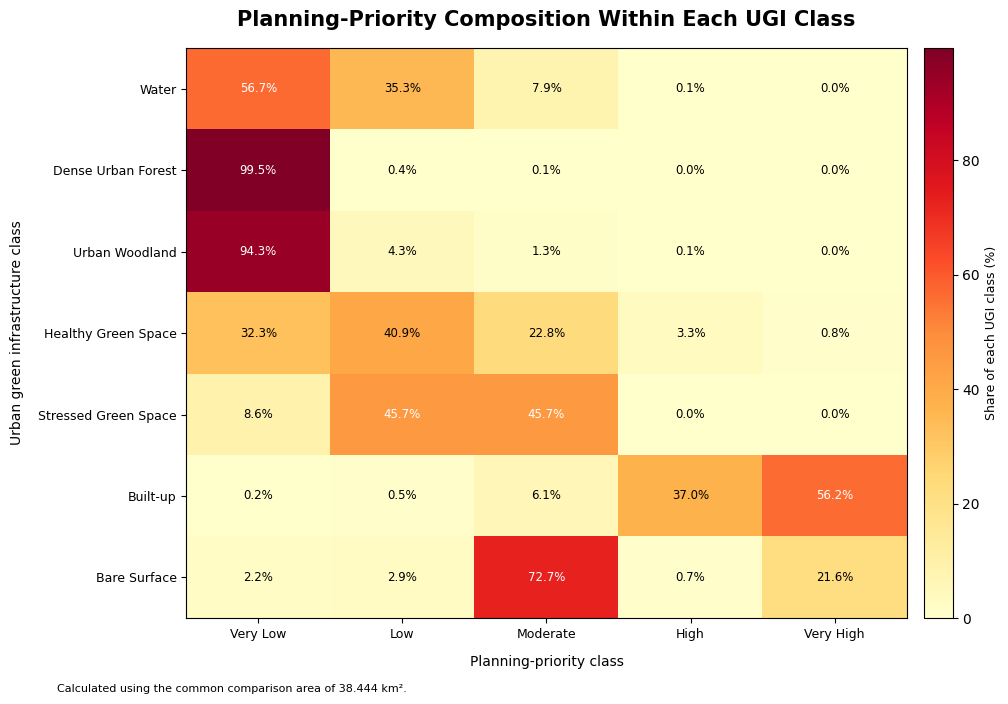


SECTION 10 VALIDATION


,Check,Expected,Observed,Passed
0,Common categorical cell count,384441,384441,True
1,Cross-tabulation pixel total,384441,384441,True
2,Cross-tab percentage total,100.0,100.0,True
3,High and Very High priority percentage,52.023288,52.023288,True
4,Heatmap PNG exported,True,True,True
5,Heatmap PDF exported,True,True,True
6,Key-results table exported,True,True,True
7,Key-findings text exported,True,True,True



SECTION 10 — PLANNING SYNTHESIS COMPLETE
Built-up area                    : 21.426 km² (55.10%)
Vegetated UGI area               : 16.619 km² (42.74%)
High + Very High priority area   : 20.230 km² (52.02%)
Very High priority area          : 12.092 km² (31.09%)
Built-up area in High/Very High  : 19.955 km²

Outputs:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_Project_Key_Results.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/04_Tables/Final_High_Very_High_Priority_by_UGI_Class.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/07_Portfolio/Final_Project_Key_Findings.txt
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/02_Charts/06_UGI_by_Planning_Priority_Heatmap.png
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/02_Charts/06_UGI_by_Planni

In [15]:
# ==============================================================================
# SECTION 10 — PLANNING SYNTHESIS AND CROSS-CLASSIFICATION
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("=" * 110)
print("SECTION 10 — PLANNING SYNTHESIS AND CROSS-CLASSIFICATION")
print("=" * 110)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
PORTFOLIO_DIR.mkdir(parents=True, exist_ok=True)


# ==============================================================================
# COMMON-MASK CATEGORICAL VALUES
# ==============================================================================

ugi_common_values = ugi_project.compressed().astype(int)
priority_common_values = priority_project.compressed().astype(int)

if len(ugi_common_values) != len(priority_common_values):
    raise ValueError(
        "UGI and priority common-mask arrays do not contain the same "
        "number of valid cells."
    )

if len(ugi_common_values) != authoritative_valid_cells:
    raise ValueError(
        "Common-mask categorical arrays do not match the authoritative "
        "common valid-cell count."
    )


# ==============================================================================
# UGI × PRIORITY CROSS-TABULATION
# ==============================================================================

cross_tab_pixels = pd.crosstab(
    pd.Series(
        ugi_common_values,
        name="UGI_Code"
    ),
    pd.Series(
        priority_common_values,
        name="Priority_Code"
    )
)

# Ensure all expected classes are included
cross_tab_pixels = cross_tab_pixels.reindex(
    index=list(UGI_CLASSES.keys()),
    columns=list(PRIORITY_CLASSES.keys()),
    fill_value=0
)

cross_tab_area_ha = (
    cross_tab_pixels
    * pixel_area_m2
    / 10_000
)

cross_tab_area_km2 = (
    cross_tab_pixels
    * pixel_area_m2
    / 1_000_000
)

# Percentage of the complete common comparison area
cross_tab_percent_total = (
    cross_tab_pixels
    / authoritative_valid_cells
    * 100
)

# Percentage within each UGI class
cross_tab_percent_within_ugi = (
    cross_tab_pixels
    .div(
        cross_tab_pixels.sum(axis=1),
        axis=0
    )
    * 100
)

# Percentage within each priority class
cross_tab_percent_within_priority = (
    cross_tab_pixels
    .div(
        cross_tab_pixels.sum(axis=0),
        axis=1
    )
    * 100
)


# ==============================================================================
# APPLY HUMAN-READABLE LABELS
# ==============================================================================

ugi_labels = [
    UGI_CLASSES[code]
    for code in cross_tab_pixels.index
]

priority_labels = [
    PRIORITY_CLASSES[code]
    for code in cross_tab_pixels.columns
]

for table in [
    cross_tab_pixels,
    cross_tab_area_ha,
    cross_tab_area_km2,
    cross_tab_percent_total,
    cross_tab_percent_within_ugi,
    cross_tab_percent_within_priority,
]:
    table.index = ugi_labels
    table.columns = priority_labels
    table.index.name = "UGI Class"
    table.columns.name = "Planning Priority"


print("\nUGI × PLANNING-PRIORITY AREA MATRIX — KM²")
display(
    cross_tab_area_km2.round(3)
)

print("\nPRIORITY DISTRIBUTION WITHIN EACH UGI CLASS — %")
display(
    cross_tab_percent_within_ugi.round(2)
)


# ==============================================================================
# HIGH-URGENCY SUMMARY BY UGI CLASS
# ==============================================================================

high_priority_codes = [4, 5]

high_priority_selector = np.isin(
    priority_common_values,
    high_priority_codes
)

high_priority_records = []

for ugi_code, ugi_name in UGI_CLASSES.items():

    ugi_selector = (
        ugi_common_values == ugi_code
    )

    class_total_cells = int(
        ugi_selector.sum()
    )

    high_priority_cells = int(
        (
            ugi_selector
            & high_priority_selector
        ).sum()
    )

    high_priority_area_ha = (
        high_priority_cells
        * pixel_area_m2
        / 10_000
    )

    high_priority_area_km2 = (
        high_priority_cells
        * pixel_area_m2
        / 1_000_000
    )

    share_of_class = (
        high_priority_cells
        / class_total_cells
        * 100
        if class_total_cells
        else 0
    )

    share_of_all_high_priority = (
        high_priority_cells
        / high_priority_selector.sum()
        * 100
        if high_priority_selector.sum()
        else 0
    )

    high_priority_records.append({
        "UGI_Code": ugi_code,
        "UGI_Class": ugi_name,
        "Total_Class_Cells": class_total_cells,
        "High_Very_High_Cells": high_priority_cells,
        "High_Very_High_Area_ha": high_priority_area_ha,
        "High_Very_High_Area_km2": high_priority_area_km2,
        "Percent_of_UGI_Class_High_Very_High": share_of_class,
        "Share_of_All_High_Very_High_Area_Percent":
            share_of_all_high_priority,
    })

high_priority_by_ugi = pd.DataFrame(
    high_priority_records
)

print("\nHIGH AND VERY HIGH PRIORITY AREA BY UGI CLASS")
display(
    high_priority_by_ugi.round({
        "High_Very_High_Area_ha": 2,
        "High_Very_High_Area_km2": 3,
        "Percent_of_UGI_Class_High_Very_High": 2,
        "Share_of_All_High_Very_High_Area_Percent": 2,
    })
)


# ==============================================================================
# HEADLINE PLANNING INDICATORS
# ==============================================================================

ugi_lookup = (
    ugi_final_stats
    .set_index("Code")
)

priority_lookup = (
    priority_final_stats
    .set_index("Code")
)

built_up_area_km2 = float(
    ugi_lookup.loc[6, "Area_km2"]
)

built_up_percent = float(
    ugi_lookup.loc[6, "Percent"]
)

vegetated_codes = [2, 3, 4, 5]

vegetated_area_km2 = float(
    ugi_lookup.loc[
        vegetated_codes,
        "Area_km2"
    ].sum()
)

vegetated_percent = float(
    ugi_lookup.loc[
        vegetated_codes,
        "Percent"
    ].sum()
)

tree_based_codes = [2, 3]

tree_based_area_km2 = float(
    ugi_lookup.loc[
        tree_based_codes,
        "Area_km2"
    ].sum()
)

tree_based_percent = float(
    ugi_lookup.loc[
        tree_based_codes,
        "Percent"
    ].sum()
)

high_very_high_area_km2 = float(
    priority_lookup.loc[
        [4, 5],
        "Area_km2"
    ].sum()
)

high_very_high_percent = float(
    priority_lookup.loc[
        [4, 5],
        "Percent"
    ].sum()
)

very_high_area_km2 = float(
    priority_lookup.loc[
        5,
        "Area_km2"
    ]
)

very_high_percent = float(
    priority_lookup.loc[
        5,
        "Percent"
    ]
)

low_very_low_area_km2 = float(
    priority_lookup.loc[
        [1, 2],
        "Area_km2"
    ].sum()
)

low_very_low_percent = float(
    priority_lookup.loc[
        [1, 2],
        "Percent"
    ].sum()
)

high_priority_built_up_row = (
    high_priority_by_ugi
    .set_index("UGI_Code")
    .loc[6]
)

built_up_high_priority_area_km2 = float(
    high_priority_built_up_row[
        "High_Very_High_Area_km2"
    ]
)

built_up_high_priority_share = float(
    high_priority_built_up_row[
        "Percent_of_UGI_Class_High_Very_High"
    ]
)

mean_capacity = float(
    continuous_statistics.loc[
        continuous_statistics["Dataset"]
        == "Ecosystem Service Capacity",
        "Mean"
    ].iloc[0]
)

mean_demand = float(
    continuous_statistics.loc[
        continuous_statistics["Dataset"]
        == "Ecosystem Service Demand",
        "Mean"
    ].iloc[0]
)

mean_deficit = float(
    continuous_statistics.loc[
        continuous_statistics["Dataset"]
        == "Ecosystem Service Deficit",
        "Mean"
    ].iloc[0]
)

capacity_deficit_correlation = float(
    cross_dataset_correlations.loc[
        "Capacity",
        "Deficit"
    ]
)

demand_deficit_correlation = float(
    cross_dataset_correlations.loc[
        "Demand",
        "Deficit"
    ]
)


key_results = pd.DataFrame([
    {
        "Indicator_ID": "KR01",
        "Indicator": "Authoritative compact urban study area",
        "Value": boundary_vector_area_km2,
        "Unit": "km²",
        "Interpretation": (
            "Validated spatial extent used for final cartographic "
            "and planning outputs."
        ),
    },
    {
        "Indicator_ID": "KR02",
        "Indicator": "Built-up surface",
        "Value": built_up_percent,
        "Unit": "%",
        "Interpretation": (
            f"Built-up land occupies {built_up_area_km2:.3f} km² "
            "and represents the dominant mapped class."
        ),
    },
    {
        "Indicator_ID": "KR03",
        "Indicator": "Vegetated UGI coverage",
        "Value": vegetated_percent,
        "Unit": "%",
        "Interpretation": (
            f"Dense forest, woodland, healthy green space and stressed "
            f"green space collectively occupy {vegetated_area_km2:.3f} km²."
        ),
    },
    {
        "Indicator_ID": "KR04",
        "Indicator": "Tree-based UGI coverage",
        "Value": tree_based_percent,
        "Unit": "%",
        "Interpretation": (
            f"Dense urban forest and urban woodland collectively occupy "
            f"{tree_based_area_km2:.3f} km²."
        ),
    },
    {
        "Indicator_ID": "KR05",
        "Indicator": "High and Very High planning priority",
        "Value": high_very_high_percent,
        "Unit": "%",
        "Interpretation": (
            f"Approximately {high_very_high_area_km2:.3f} km² requires "
            "high or very high planning attention."
        ),
    },
    {
        "Indicator_ID": "KR06",
        "Indicator": "Very High planning priority",
        "Value": very_high_percent,
        "Unit": "%",
        "Interpretation": (
            f"The most urgent intervention class covers "
            f"{very_high_area_km2:.3f} km²."
        ),
    },
    {
        "Indicator_ID": "KR07",
        "Indicator": "Low and Very Low planning priority",
        "Value": low_very_low_percent,
        "Unit": "%",
        "Interpretation": (
            f"Lower-priority areas cover approximately "
            f"{low_very_low_area_km2:.3f} km²."
        ),
    },
    {
        "Indicator_ID": "KR08",
        "Indicator": "Built-up land in High or Very High priority zones",
        "Value": built_up_high_priority_area_km2,
        "Unit": "km²",
        "Interpretation": (
            f"{built_up_high_priority_share:.2f}% of mapped built-up land "
            "falls within the two highest intervention classes."
        ),
    },
    {
        "Indicator_ID": "KR09",
        "Indicator": "Mean ecosystem service capacity",
        "Value": mean_capacity,
        "Unit": "score",
        "Interpretation": (
            "Mean capacity across the mapped study area on the "
            "project's 0–100 capacity scale."
        ),
    },
    {
        "Indicator_ID": "KR10",
        "Indicator": "Mean ecosystem service demand",
        "Value": mean_demand,
        "Unit": "index",
        "Interpretation": (
            "Mean normalized demand across cells with valid demand data."
        ),
    },
    {
        "Indicator_ID": "KR11",
        "Indicator": "Mean ecosystem service deficit",
        "Value": mean_deficit,
        "Unit": "index",
        "Interpretation": (
            "Mean normalized mismatch between ecosystem service "
            "capacity and demand."
        ),
    },
    {
        "Indicator_ID": "KR12",
        "Indicator": "Capacity–deficit correlation",
        "Value": capacity_deficit_correlation,
        "Unit": "Pearson r",
        "Interpretation": (
            "Strong inverse internal model relationship; this should "
            "not be interpreted as independent causal evidence."
        ),
    },
    {
        "Indicator_ID": "KR13",
        "Indicator": "Demand–deficit correlation",
        "Value": demand_deficit_correlation,
        "Unit": "Pearson r",
        "Interpretation": (
            "Strong positive internal model relationship; this reflects "
            "the deficit-model structure."
        ),
    },
])

print("\nDEFINITIVE PROJECT KEY RESULTS")
display(
    key_results.round({
        "Value": 4
    })
)


# ==============================================================================
# HEATMAP — UGI CLASS BY PLANNING PRIORITY
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(11.2, 7.4)
)

heatmap_values = (
    cross_tab_percent_within_ugi
    .values
)

image = ax.imshow(
    heatmap_values,
    aspect="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=max(
        50,
        np.nanmax(heatmap_values)
    )
)

ax.set_xticks(
    np.arange(
        len(priority_labels)
    )
)

ax.set_xticklabels(
    priority_labels,
    fontsize=9
)

ax.set_yticks(
    np.arange(
        len(ugi_labels)
    )
)

ax.set_yticklabels(
    ugi_labels,
    fontsize=9
)

for row_index in range(
    heatmap_values.shape[0]
):
    for column_index in range(
        heatmap_values.shape[1]
    ):

        value = heatmap_values[
            row_index,
            column_index
        ]

        text_color = (
            "white"
            if value >= 45
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_color
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Share of each UGI class (%)",
    fontsize=9
)

ax.set_title(
    "Planning-Priority Composition Within Each UGI Class",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Planning-priority class",
    fontsize=10,
    labelpad=10
)

ax.set_ylabel(
    "Urban green infrastructure class",
    fontsize=10,
    labelpad=10
)

fig.text(
    0.01,
    0.01,
    (
        f"Calculated using the common comparison area of "
        f"{authoritative_valid_area_km2:.3f} km²."
    ),
    fontsize=8
)

heatmap_png, heatmap_pdf = save_chart(
    fig,
    "06_UGI_by_Planning_Priority_Heatmap"
)

plt.show()
plt.close(fig)


# ==============================================================================
# EXPORT DEFINITIVE TABLES
# ==============================================================================

UGI_PRIORITY_PIXELS_FILE = (
    TABLE_DIR
    / "Final_UGI_by_Planning_Priority_Pixels.csv"
)

UGI_PRIORITY_AREA_HA_FILE = (
    TABLE_DIR
    / "Final_UGI_by_Planning_Priority_Area_ha.csv"
)

UGI_PRIORITY_AREA_KM2_FILE = (
    TABLE_DIR
    / "Final_UGI_by_Planning_Priority_Area_km2.csv"
)

UGI_PRIORITY_PERCENT_FILE = (
    TABLE_DIR
    / "Final_UGI_by_Planning_Priority_Percent_of_Total.csv"
)

UGI_PRIORITY_WITHIN_UGI_FILE = (
    TABLE_DIR
    / "Final_Priority_Percent_Within_Each_UGI_Class.csv"
)

HIGH_PRIORITY_BY_UGI_FILE = (
    TABLE_DIR
    / "Final_High_Very_High_Priority_by_UGI_Class.csv"
)

KEY_RESULTS_FILE = (
    TABLE_DIR
    / "Final_Project_Key_Results.csv"
)

cross_tab_pixels.to_csv(
    UGI_PRIORITY_PIXELS_FILE
)

cross_tab_area_ha.to_csv(
    UGI_PRIORITY_AREA_HA_FILE
)

cross_tab_area_km2.to_csv(
    UGI_PRIORITY_AREA_KM2_FILE
)

cross_tab_percent_total.to_csv(
    UGI_PRIORITY_PERCENT_FILE
)

cross_tab_percent_within_ugi.to_csv(
    UGI_PRIORITY_WITHIN_UGI_FILE
)

high_priority_by_ugi.to_csv(
    HIGH_PRIORITY_BY_UGI_FILE,
    index=False
)

key_results.to_csv(
    KEY_RESULTS_FILE,
    index=False
)


# ==============================================================================
# CREATE HUMAN-READABLE KEY-FINDINGS TEXT
# ==============================================================================

KEY_FINDINGS_TEXT_FILE = (
    PORTFOLIO_DIR
    / "Final_Project_Key_Findings.txt"
)

key_findings_text = f"""
URBAN GREEN INFRASTRUCTURE AND ECOSYSTEM SERVICE DEFICIT MAPPING
TARTU, ESTONIA

DEFINITIVE KEY FINDINGS

1. The validated compact urban study area covers
   {boundary_vector_area_km2:.3f} km².

2. Built-up surfaces are the dominant land-cover class, occupying
   {built_up_area_km2:.3f} km² or {built_up_percent:.2f}% of the mapped area.

3. Vegetated urban green infrastructure covers
   {vegetated_area_km2:.3f} km² or {vegetated_percent:.2f}% of the mapped area.

4. Tree-based green infrastructure, comprising dense urban forest and
   urban woodland, covers {tree_based_area_km2:.3f} km² or
   {tree_based_percent:.2f}% of the mapped area.

5. High and Very High planning-priority zones collectively cover
   {high_very_high_area_km2:.3f} km² or {high_very_high_percent:.2f}%
   of the study area.

6. Very High priority zones alone cover {very_high_area_km2:.3f} km²,
   representing {very_high_percent:.2f}% of the mapped area.

7. Built-up areas account for {built_up_high_priority_area_km2:.3f} km²
   within High and Very High priority zones. This represents
   {built_up_high_priority_share:.2f}% of all mapped built-up land.

8. The mean ecosystem service capacity score is {mean_capacity:.2f}
   on the project scale of 0–100.

9. Mean ecosystem service demand is {mean_demand:.3f}, while the mean
   ecosystem service deficit is {mean_deficit:.3f} on normalized
   0–1 scales.

10. Mean deficit increases systematically from 0.104 in Very Low
    priority areas to 0.859 in Very High priority areas, confirming
    the internal consistency of the planning-priority classification.

INTERPRETATION NOTE

The reported capacity–deficit and demand–deficit correlations are internal
model relationships because the deficit surface was derived from capacity
and demand. They demonstrate model consistency but should not be presented
as independent causal relationships.
""".strip()

KEY_FINDINGS_TEXT_FILE.write_text(
    key_findings_text,
    encoding="utf-8"
)


# ==============================================================================
# VALIDATION REGISTER
# ==============================================================================

section_10_validation = pd.DataFrame([
    {
        "Check": "Common categorical cell count",
        "Expected": authoritative_valid_cells,
        "Observed": len(ugi_common_values),
        "Passed": (
            len(ugi_common_values)
            == authoritative_valid_cells
        ),
    },
    {
        "Check": "Cross-tabulation pixel total",
        "Expected": authoritative_valid_cells,
        "Observed": int(
            cross_tab_pixels.values.sum()
        ),
        "Passed": (
            int(
                cross_tab_pixels.values.sum()
            )
            == authoritative_valid_cells
        ),
    },
    {
        "Check": "Cross-tab percentage total",
        "Expected": 100.0,
        "Observed": float(
            cross_tab_percent_total
            .values
            .sum()
        ),
        "Passed": np.isclose(
            cross_tab_percent_total
            .values
            .sum(),
            100,
            atol=0.01
        ),
    },
    {
        "Check": "High and Very High priority percentage",
        "Expected": high_very_high_percent,
        "Observed": float(
            priority_final_stats.loc[
                priority_final_stats[
                    "Code"
                ].isin([4, 5]),
                "Percent"
            ].sum()
        ),
        "Passed": np.isclose(
            high_very_high_percent,
            priority_final_stats.loc[
                priority_final_stats[
                    "Code"
                ].isin([4, 5]),
                "Percent"
            ].sum(),
            atol=0.001
        ),
    },
    {
        "Check": "Heatmap PNG exported",
        "Expected": True,
        "Observed": heatmap_png.exists(),
        "Passed": heatmap_png.exists(),
    },
    {
        "Check": "Heatmap PDF exported",
        "Expected": True,
        "Observed": heatmap_pdf.exists(),
        "Passed": heatmap_pdf.exists(),
    },
    {
        "Check": "Key-results table exported",
        "Expected": True,
        "Observed": KEY_RESULTS_FILE.exists(),
        "Passed": KEY_RESULTS_FILE.exists(),
    },
    {
        "Check": "Key-findings text exported",
        "Expected": True,
        "Observed": KEY_FINDINGS_TEXT_FILE.exists(),
        "Passed": KEY_FINDINGS_TEXT_FILE.exists(),
    },
])

SECTION_10_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_10_Planning_Synthesis_Validation.csv"
)

section_10_validation.to_csv(
    SECTION_10_VALIDATION_FILE,
    index=False
)

print("\n" + "=" * 110)
print("SECTION 10 VALIDATION")
print("=" * 110)

display(section_10_validation)


if not section_10_validation["Passed"].all():
    failed_checks = section_10_validation.loc[
        ~section_10_validation["Passed"],
        "Check"
    ].tolist()

    raise ValueError(
        f"Section 10 validation failed: {failed_checks}"
    )


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 10 — PLANNING SYNTHESIS COMPLETE")
print("=" * 110)

print(
    f"Built-up area                    : "
    f"{built_up_area_km2:.3f} km² "
    f"({built_up_percent:.2f}%)"
)

print(
    f"Vegetated UGI area               : "
    f"{vegetated_area_km2:.3f} km² "
    f"({vegetated_percent:.2f}%)"
)

print(
    f"High + Very High priority area   : "
    f"{high_very_high_area_km2:.3f} km² "
    f"({high_very_high_percent:.2f}%)"
)

print(
    f"Very High priority area          : "
    f"{very_high_area_km2:.3f} km² "
    f"({very_high_percent:.2f}%)"
)

print(
    f"Built-up area in High/Very High  : "
    f"{built_up_high_priority_area_km2:.3f} km²"
)

print("\nOutputs:")
print(f"  {KEY_RESULTS_FILE}")
print(f"  {HIGH_PRIORITY_BY_UGI_FILE}")
print(f"  {KEY_FINDINGS_TEXT_FILE}")
print(f"  {heatmap_png}")
print(f"  {heatmap_pdf}")
print(f"  {SECTION_10_VALIDATION_FILE}")

print("\n✓ UGI and planning-priority rasters cross-classified.")
print("✓ High-urgency areas summarized by UGI class.")
print("✓ Definitive project indicators calculated.")
print("✓ Report- and portfolio-ready key findings exported.")
print("✓ UGI–priority heatmap exported as PNG and PDF.")
print("✓ All planning-synthesis checks passed.")

In [18]:
# ==============================================================================
# SECTION 11 — RESULTS INTERPRETATION AND PLANNING RECOMMENDATIONS
# ==============================================================================

import pandas as pd
from pathlib import Path

print("=" * 110)
print("SECTION 11 — RESULTS INTERPRETATION AND PLANNING RECOMMENDATIONS")
print("=" * 110)


# ==============================================================================
# OUTPUT DIRECTORY
# ==============================================================================

REPORT_CONTENT_DIR = (
    FINAL_DELIVERABLES_DIR
    / "06_Final_Report"
    / "Report_Content"
)

REPORT_CONTENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PORTFOLIO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==============================================================================
# VERIFIED NUMERIC VALUES
# ==============================================================================

built_up_high_priority_percent = float(
    high_priority_by_ugi
    .set_index("UGI_Code")
    .loc[
        6,
        "Percent_of_UGI_Class_High_Very_High"
    ]
)

built_up_share_of_urgent_area = float(
    high_priority_by_ugi
    .set_index("UGI_Code")
    .loc[
        6,
        "Share_of_All_High_Very_High_Area_Percent"
    ]
)

dense_forest_very_low_percent = float(
    cross_tab_percent_within_ugi.loc[
        "Dense Urban Forest",
        "Very Low"
    ]
)

woodland_very_low_percent = float(
    cross_tab_percent_within_ugi.loc[
        "Urban Woodland",
        "Very Low"
    ]
)

healthy_green_low_very_low_percent = float(
    cross_tab_percent_within_ugi.loc[
        "Healthy Green Space",
        ["Very Low", "Low"]
    ].sum()
)

healthy_green_high_very_high_percent = float(
    cross_tab_percent_within_ugi.loc[
        "Healthy Green Space",
        ["High", "Very High"]
    ].sum()
)

water_low_very_low_percent = float(
    cross_tab_percent_within_ugi.loc[
        "Water",
        ["Very Low", "Low"]
    ].sum()
)

moderate_priority_percent = float(
    priority_lookup.loc[
        3,
        "Percent"
    ]
)

moderate_priority_area_km2 = float(
    priority_lookup.loc[
        3,
        "Area_km2"
    ]
)

very_low_mean_deficit = float(
    priority_deficit_summary
    .set_index("Priority_Code")
    .loc[
        1,
        "Mean_Deficit"
    ]
)

very_high_mean_deficit = float(
    priority_deficit_summary
    .set_index("Priority_Code")
    .loc[
        5,
        "Mean_Deficit"
    ]
)

deficit_gradient_ratio = (
    very_high_mean_deficit
    / very_low_mean_deficit
)


# ==============================================================================
# EXECUTIVE RESULTS SUMMARY
# ==============================================================================

executive_results_summary = f"""
EXECUTIVE RESULTS SUMMARY

The validated compact urban study area covers {boundary_vector_area_km2:.3f} km².
Built-up land is the dominant mapped surface, occupying {built_up_area_km2:.3f} km²,
equivalent to {built_up_percent:.2f}% of the study area. Vegetated urban green
infrastructure—including dense urban forest, urban woodland, healthy green space
and stressed green space—covers {vegetated_area_km2:.3f} km² or
{vegetated_percent:.2f}% of the area.

The ecosystem-service planning-priority assessment identifies
{high_very_high_area_km2:.3f} km², or {high_very_high_percent:.2f}% of the study
area, as High or Very High priority. Very High priority zones alone occupy
{very_high_area_km2:.3f} km², representing {very_high_percent:.2f}% of the
mapped area.

The spatial concentration of urgent planning need is strongly associated with
built-up surfaces. Approximately {built_up_high_priority_area_km2:.3f} km² of
built-up land falls within High or Very High priority zones. This represents
{built_up_high_priority_percent:.2f}% of all mapped built-up land and
{built_up_share_of_urgent_area:.2f}% of the total High and Very High priority area.

Mean ecosystem-service deficit increases systematically from
{very_low_mean_deficit:.3f} in Very Low priority areas to
{very_high_mean_deficit:.3f} in Very High priority areas. The Very High priority
mean is approximately {deficit_gradient_ratio:.1f} times the mean recorded in
Very Low priority areas, demonstrating a clear and internally consistent planning
gradient.
""".strip()


# ==============================================================================
# RESULTS INTERPRETATION
# ==============================================================================

results_interpretation = f"""
RESULTS INTERPRETATION

1. Urban Green Infrastructure Structure

The urban green infrastructure classification shows that Tartu's compact urban
study area contains a substantial but spatially uneven green-infrastructure
resource. Built-up land occupies {built_up_percent:.2f}% of the area, while
vegetated UGI classes collectively account for {vegetated_percent:.2f}%.
Tree-based green infrastructure, comprising dense urban forest and urban woodland,
covers {tree_based_area_km2:.3f} km² or {tree_based_percent:.2f}% of the mapped
area.

Dense urban forest is the largest individual green-infrastructure class,
occupying 8.549 km² or 21.99% of the study area. Healthy green space occupies
6.759 km² or 17.38%, while urban woodland accounts for 1.295 km² or 3.33%.
Water covers 0.828 km² or 2.13%.

2. Ecosystem Service Capacity

The mean ecosystem-service capacity score is {mean_capacity:.2f} on the project's
0–100 scale. The capacity distribution is strongly influenced by the contrast
between vegetated and built-up surfaces. High-capacity areas are associated
primarily with dense forest, woodland and healthy green space, while low-capacity
values dominate extensively developed surfaces.

The very high share of dense urban forest classified as Very Low planning
priority ({dense_forest_very_low_percent:.2f}%) confirms the strong service
capacity assigned to this class. Similarly, {woodland_very_low_percent:.2f}% of
urban woodland lies within the Very Low priority category.

3. Ecosystem Service Demand

The mean normalized ecosystem-service demand index is {mean_demand:.3f}. Demand
varies across the compact urban area, reflecting differences in urban intensity
and the spatial concentration of environmental and population-related need.
Demand data cover {authoritative_valid_area_km2:.3f} km² of the study area,
equivalent to approximately 98.86% of the authoritative boundary.

4. Ecosystem Service Deficit

The mean ecosystem-service deficit index is {mean_deficit:.3f}. The deficit
surface represents the spatial mismatch between ecosystem-service capacity and
demand. High values occur where demand is relatively strong but existing
green-infrastructure capacity is limited.

The internal model relationships are strong: capacity and deficit have a
correlation of {capacity_deficit_correlation:.4f}, while demand and deficit have
a correlation of {demand_deficit_correlation:.4f}. These values confirm the
mathematical consistency of the deficit model because deficit was derived from
capacity and demand. They should not be interpreted as independent causal
relationships.

5. Planning-Priority Distribution

High and Very High planning-priority zones jointly occupy
{high_very_high_area_km2:.3f} km² or {high_very_high_percent:.2f}% of the study
area. Moderate-priority areas occupy {moderate_priority_area_km2:.3f} km² or
{moderate_priority_percent:.2f}%. Low and Very Low priority zones jointly cover
{low_very_low_area_km2:.3f} km² or {low_very_low_percent:.2f}%.

The deficit gradient supports the priority classification. Mean deficit rises
from {very_low_mean_deficit:.3f} in Very Low priority areas to 0.290 in Low,
0.500 in Moderate, 0.725 in High and {very_high_mean_deficit:.3f} in Very High
priority areas.

6. Relationship Between UGI Classes and Planning Priority

The cross-classification reveals a pronounced division between developed and
green surfaces. Built-up land dominates the highest-priority categories:
{built_up_high_priority_percent:.2f}% of built-up land is classified as High or
Very High priority. Built-up areas also account for
{built_up_share_of_urgent_area:.2f}% of all High and Very High priority land.

In contrast, dense urban forest and urban woodland are overwhelmingly
concentrated in the Very Low priority category. Healthy green space has a more
mixed profile: {healthy_green_low_very_low_percent:.2f}% lies within Low or Very
Low priority zones, while only {healthy_green_high_very_high_percent:.2f}% occurs
within High or Very High priority zones.

Water surfaces also show a predominantly low-priority profile, with
{water_low_very_low_percent:.2f}% classified as Low or Very Low priority.

The results indicate that existing green infrastructure largely performs a
protective ecosystem-service role, while the most significant service deficits
are concentrated in extensively built-up parts of the urban area.
""".strip()


# ==============================================================================
# PLANNING IMPLICATIONS
# ==============================================================================

planning_implications = f"""
PLANNING IMPLICATIONS

1. Prioritize Built-Up Deficit Hotspots

The primary intervention focus should be the {built_up_high_priority_area_km2:.3f}
km² of built-up land located within High and Very High priority zones. Because
these surfaces comprise {built_up_share_of_urgent_area:.2f}% of the total urgent
area, strategies focused on developed land will address the largest share of the
identified ecosystem-service deficit.

2. Protect Existing High-Capacity Green Infrastructure

Dense urban forest and urban woodland should be treated as critical green
infrastructure assets. Their concentration in Very Low priority zones indicates
that they provide substantial ecosystem-service capacity relative to local
demand. Planning controls should therefore emphasize retention, connectivity and
avoidance of unnecessary fragmentation.

3. Enhance Green Infrastructure Within Developed Areas

High-priority built-up zones are suitable locations for interventions that can be
integrated into the existing urban fabric. Relevant measures include street-tree
planting, vegetated corridors, pocket parks, green roofs, green walls, permeable
surfaces and the greening of public institutional land.

4. Strengthen Green-Space Connectivity

Existing forests, woodland, healthy green spaces and water-related open spaces
should be connected where spatial opportunities exist. Improved connectivity can
support continuity between high-capacity areas and reduce isolated deficit
hotspots.

5. Use Moderate-Priority Zones for Preventive Planning

The {moderate_priority_area_km2:.3f} km² of Moderate priority land should not be
ignored. These areas represent transitional locations where targeted,
lower-intensity intervention may prevent future escalation into High or Very High
priority conditions.

6. Apply Context-Specific Intervention Design

The priority map identifies where intervention need is greatest, but it does not
prescribe one uniform solution. Site-level planning should consider land
ownership, current land use, development intensity, public-space availability,
infrastructure constraints and implementation feasibility.

7. Integrate the Priority Surface Into Planning Decisions

The final planning-priority raster can support preliminary screening for urban
development review, green-space investment, neighbourhood upgrading and
ecosystem-service enhancement. It should be used as a strategic decision-support
layer rather than as a substitute for detailed site assessment.
""".strip()


# ==============================================================================
# LIMITATIONS
# ==============================================================================

limitations_text = """
LIMITATIONS

1. The ecosystem-service capacity, demand, deficit and priority outputs are
   model-derived indicators. They represent comparative spatial conditions rather
   than direct measurements of every ecosystem service.

2. The demand raster contains limited NoData coverage. Cross-dataset statistics
   therefore use a common valid area of 38.444 km², while individual UGI and
   priority summaries use the full rasterized boundary area of 38.887 km².

3. The priority classification depends on the indicators, normalization methods,
   thresholds and weighting framework established during the analytical stages.

4. The results identify strategic planning priorities at the project raster
   resolution. Detailed intervention design requires field verification and
   site-specific assessment.

5. The reported correlations are internal model relationships because the
   ecosystem-service deficit was calculated from capacity and demand. They must
   not be presented as independent evidence of causation.

6. Small classes such as stressed green space and bare surface contain relatively
   few pixels. Percentage interpretations for these classes should therefore be
   treated cautiously.

7. The outputs represent the project reference period and should be updated when
   newer land-cover, population or planning data become available.
""".strip()


# ==============================================================================
# CONCLUSION
# ==============================================================================

conclusion_text = f"""
CONCLUSION

The analysis demonstrates that Tartu's compact urban area contains substantial
green infrastructure, but ecosystem-service capacity and planning need are
unevenly distributed. Vegetated UGI covers {vegetated_percent:.2f}% of the mapped
area, while built-up surfaces account for {built_up_percent:.2f}%.

More than half of the study area—{high_very_high_percent:.2f}% or
{high_very_high_area_km2:.3f} km²—is classified as High or Very High planning
priority. The urgent planning burden is concentrated almost entirely within
built-up surfaces: {built_up_high_priority_percent:.2f}% of built-up land lies in
the two highest priority categories, and built-up areas constitute
{built_up_share_of_urgent_area:.2f}% of all High and Very High priority land.

The results support a two-part planning strategy. Existing high-capacity forests,
woodlands and healthy green spaces should be protected and connected, while
built-up deficit hotspots should receive targeted green-infrastructure
interventions. The final priority map provides a consistent spatial framework for
screening, investment prioritization and further site-level planning.
""".strip()


# ==============================================================================
# COMBINED REPORT CONTENT
# ==============================================================================

combined_report_content = "\n\n".join([
    executive_results_summary,
    results_interpretation,
    planning_implications,
    limitations_text,
    conclusion_text
])


# ==============================================================================
# PORTFOLIO-READY SUMMARY
# ==============================================================================

portfolio_summary = f"""
PROJECT TITLE
Urban Green Infrastructure and Ecosystem Service Deficit Mapping — Tartu, Estonia

PROJECT PURPOSE
To assess the spatial distribution of urban green infrastructure, quantify
ecosystem-service capacity and demand, identify areas of ecosystem-service
deficit, and classify planning-priority zones for targeted urban green
infrastructure intervention.

STUDY AREA
Tartu compact urban area, Estonia — {boundary_vector_area_km2:.3f} km².

CORE METHODS
• Urban green infrastructure classification
• Ecosystem-service capacity modelling
• Spatial demand assessment
• Capacity–demand deficit analysis
• Planning-priority classification
• Raster cross-classification and area statistics
• Professional cartographic production

KEY RESULTS
• Built-up area: {built_up_area_km2:.3f} km² ({built_up_percent:.2f}%)
• Vegetated UGI: {vegetated_area_km2:.3f} km² ({vegetated_percent:.2f}%)
• High and Very High priority: {high_very_high_area_km2:.3f} km²
  ({high_very_high_percent:.2f}%)
• Very High priority: {very_high_area_km2:.3f} km²
  ({very_high_percent:.2f}%)
• Built-up land in High/Very High zones:
  {built_up_high_priority_area_km2:.3f} km²
• Share of built-up land classified High/Very High:
  {built_up_high_priority_percent:.2f}%

PLANNING INTERPRETATION
The highest ecosystem-service deficits are concentrated in built-up parts of the
city, while forest, woodland and established green spaces generally provide
higher ecosystem-service capacity. The results support targeted greening of
developed areas alongside protection and connectivity of existing high-capacity
green infrastructure.

TOOLS AND SKILLS
Python, GeoPandas, Rasterio, NumPy, Pandas, Matplotlib, spatial modelling,
raster analysis, ecosystem-service assessment, urban planning analysis,
cartographic design and reproducible geospatial workflows.
""".strip()


# ==============================================================================
# SAVE TEXT OUTPUTS
# ==============================================================================

EXECUTIVE_SUMMARY_FILE = (
    REPORT_CONTENT_DIR
    / "01_Executive_Results_Summary.txt"
)

RESULTS_INTERPRETATION_FILE = (
    REPORT_CONTENT_DIR
    / "02_Results_Interpretation.txt"
)

PLANNING_IMPLICATIONS_FILE = (
    REPORT_CONTENT_DIR
    / "03_Planning_Implications.txt"
)

LIMITATIONS_FILE = (
    REPORT_CONTENT_DIR
    / "04_Limitations.txt"
)

CONCLUSION_FILE = (
    REPORT_CONTENT_DIR
    / "05_Conclusion.txt"
)

COMBINED_REPORT_CONTENT_FILE = (
    REPORT_CONTENT_DIR
    / "06_Combined_Results_Discussion_Recommendations.txt"
)

PORTFOLIO_SUMMARY_FILE = (
    PORTFOLIO_DIR
    / "Final_Portfolio_Project_Summary.txt"
)


text_outputs = {
    EXECUTIVE_SUMMARY_FILE:
        executive_results_summary,

    RESULTS_INTERPRETATION_FILE:
        results_interpretation,

    PLANNING_IMPLICATIONS_FILE:
        planning_implications,

    LIMITATIONS_FILE:
        limitations_text,

    CONCLUSION_FILE:
        conclusion_text,

    COMBINED_REPORT_CONTENT_FILE:
        combined_report_content,

    PORTFOLIO_SUMMARY_FILE:
        portfolio_summary,
}


for output_path, content in text_outputs.items():

    output_path.write_text(
        content,
        encoding="utf-8"
    )


# ==============================================================================
# PLANNING ACTION REGISTER
# ==============================================================================

planning_action_register = pd.DataFrame([
    {
        "Priority_Order": 1,
        "Planning_Action": "Target built-up High and Very High priority zones",
        "Spatial_Evidence": (
            f"{built_up_high_priority_area_km2:.3f} km² of built-up land "
            "falls within High or Very High priority zones."
        ),
        "Recommended_Approach": (
            "Street trees, pocket parks, green roofs, vegetated corridors, "
            "permeable surfaces and institutional-land greening."
        ),
    },
    {
        "Priority_Order": 2,
        "Planning_Action": "Protect dense urban forest",
        "Spatial_Evidence": (
            f"{dense_forest_very_low_percent:.2f}% of dense urban forest "
            "is classified as Very Low priority."
        ),
        "Recommended_Approach": (
            "Retention, development buffers, fragmentation control and "
            "ecological-management measures."
        ),
    },
    {
        "Priority_Order": 3,
        "Planning_Action": "Protect and connect urban woodland",
        "Spatial_Evidence": (
            f"{woodland_very_low_percent:.2f}% of urban woodland lies in "
            "Very Low priority zones."
        ),
        "Recommended_Approach": (
            "Improve connectivity between woodland, forest, parks and "
            "water-related green spaces."
        ),
    },
    {
        "Priority_Order": 4,
        "Planning_Action": "Strengthen healthy green spaces",
        "Spatial_Evidence": (
            f"{healthy_green_high_very_high_percent:.2f}% of healthy green "
            "space occurs in High or Very High priority zones."
        ),
        "Recommended_Approach": (
            "Improve vegetation structure, accessibility, connectivity and "
            "ecological performance where local deficits remain."
        ),
    },
    {
        "Priority_Order": 5,
        "Planning_Action": "Apply preventive action in Moderate zones",
        "Spatial_Evidence": (
            f"Moderate priority areas occupy "
            f"{moderate_priority_area_km2:.3f} km²."
        ),
        "Recommended_Approach": (
            "Use early-stage greening and development controls to prevent "
            "further ecosystem-service decline."
        ),
    },
])

PLANNING_ACTION_REGISTER_FILE = (
    TABLE_DIR
    / "Final_Planning_Action_Register.csv"
)

planning_action_register.to_csv(
    PLANNING_ACTION_REGISTER_FILE,
    index=False
)

print("\nPLANNING ACTION REGISTER")
display(planning_action_register)


# ==============================================================================
# VALIDATION
# ==============================================================================

section_11_validation_rows = []

for output_path in text_outputs.keys():

    section_11_validation_rows.append({
        "Check": f"Text output exists: {output_path.name}",
        "Expected": True,
        "Observed": output_path.exists(),
        "Passed": output_path.exists(),
    })

section_11_validation_rows.extend([
    {
        "Check": "Planning action register exported",
        "Expected": True,
        "Observed": PLANNING_ACTION_REGISTER_FILE.exists(),
        "Passed": PLANNING_ACTION_REGISTER_FILE.exists(),
    },
    {
        "Check": "Built-up urgent-area share within valid range",
        "Expected": "0–100%",
        "Observed": built_up_high_priority_percent,
        "Passed": (
            0
            <= built_up_high_priority_percent
            <= 100
        ),
    },
    {
        "Check": "Urgent-area built-up composition within valid range",
        "Expected": "0–100%",
        "Observed": built_up_share_of_urgent_area,
        "Passed": (
            0
            <= built_up_share_of_urgent_area
            <= 100
        ),
    },
    {
        "Check": "Deficit increases from Very Low to Very High priority",
        "Expected": True,
        "Observed": (
            very_high_mean_deficit
            > very_low_mean_deficit
        ),
        "Passed": (
            very_high_mean_deficit
            > very_low_mean_deficit
        ),
    },
])

section_11_validation = pd.DataFrame(
    section_11_validation_rows
)

SECTION_11_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_11_Report_Content_Validation.csv"
)

section_11_validation.to_csv(
    SECTION_11_VALIDATION_FILE,
    index=False
)

print("\n" + "=" * 110)
print("SECTION 11 VALIDATION")
print("=" * 110)

display(section_11_validation)


if not section_11_validation["Passed"].all():

    failed_checks = section_11_validation.loc[
        ~section_11_validation["Passed"],
        "Check"
    ].tolist()

    raise ValueError(
        f"Section 11 validation failed: {failed_checks}"
    )


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 11 — REPORT INTERPRETATION COMPLETE")
print("=" * 110)

print(
    f"Built-up area in High/Very High zones : "
    f"{built_up_high_priority_area_km2:.3f} km²"
)

print(
    f"Share of built-up land affected       : "
    f"{built_up_high_priority_percent:.2f}%"
)

print(
    f"Built-up share of urgent area         : "
    f"{built_up_share_of_urgent_area:.2f}%"
)

print(
    f"Very Low mean deficit                 : "
    f"{very_low_mean_deficit:.3f}"
)

print(
    f"Very High mean deficit                : "
    f"{very_high_mean_deficit:.3f}"
)

print("\nReport content outputs:")

for output_path in text_outputs.keys():
    print(f"  {output_path}")

print("\nAdditional outputs:")
print(f"  {PLANNING_ACTION_REGISTER_FILE}")
print(f"  {SECTION_11_VALIDATION_FILE}")

print("\n✓ Executive results summary generated.")
print("✓ Detailed results interpretation generated.")
print("✓ Planning implications and recommendations generated.")
print("✓ Limitations and conclusion generated.")
print("✓ Portfolio-ready project summary generated.")
print("✓ Planning action register exported.")
print("✓ All narrative outputs are derived from validated project results.")
print("✓ Section 11 validation passed.")

SECTION 11 — RESULTS INTERPRETATION AND PLANNING RECOMMENDATIONS

PLANNING ACTION REGISTER


,Priority_Order,Planning_Action,Spatial_Evidence,Recommended_Approach
0,1,Target built-up High and Very High priority zones,19.955 km² of built-up land falls within High ...,"Street trees, pocket parks, green roofs, veget..."
1,2,Protect dense urban forest,99.54% of dense urban forest is classified as ...,"Retention, development buffers, fragmentation ..."
2,3,Protect and connect urban woodland,94.27% of urban woodland lies in Very Low prio...,"Improve connectivity between woodland, forest,..."
3,4,Strengthen healthy green spaces,4.07% of healthy green space occurs in High or...,"Improve vegetation structure, accessibility, c..."
4,5,Apply preventive action in Moderate zones,Moderate priority areas occupy 2.935 km².,Use early-stage greening and development contr...



SECTION 11 VALIDATION


,Check,Expected,Observed,Passed
0,Text output exists: 01_Executive_Results_Summa...,True,True,True
1,Text output exists: 02_Results_Interpretation.txt,True,True,True
2,Text output exists: 03_Planning_Implications.txt,True,True,True
3,Text output exists: 04_Limitations.txt,True,True,True
4,Text output exists: 05_Conclusion.txt,True,True,True
5,Text output exists: 06_Combined_Results_Discus...,True,True,True
6,Text output exists: Final_Portfolio_Project_Su...,True,True,True
7,Planning action register exported,True,True,True
8,Built-up urgent-area share within valid range,0–100%,93.135443,True
9,Urgent-area built-up composition within valid ...,0–100%,98.640646,True



SECTION 11 — REPORT INTERPRETATION COMPLETE
Built-up area in High/Very High zones : 19.955 km²
Share of built-up land affected       : 93.14%
Built-up share of urgent area         : 98.64%
Very Low mean deficit                 : 0.104
Very High mean deficit                : 0.858

Report content outputs:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Report_Content/01_Executive_Results_Summary.txt
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Report_Content/02_Results_Interpretation.txt
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Report_Content/03_Planning_Implications.txt
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Report_Content/04_Limitations.txt
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Delive

In [17]:
# ==============================================================================
# SECTION 11 DIRECTORY VARIABLE FIX
# ==============================================================================

from pathlib import Path

print("=" * 110)
print("SECTION 11 — DIRECTORY VARIABLE FIX")
print("=" * 110)


# Derive the final-deliverables folder from the already validated tables folder.
# TABLE_DIR points to:
# 18_Final_Deliverables/04_Tables

if "TABLE_DIR" in globals():

    FINAL_DELIVERABLES_DIR = Path(TABLE_DIR).parent

elif "MAP_DIR" in globals():

    FINAL_DELIVERABLES_DIR = Path(MAP_DIR).parent

elif "VALIDATION_DIR" in globals():

    FINAL_DELIVERABLES_DIR = Path(VALIDATION_DIR).parent

elif "PROJECT_ROOT" in globals():

    FINAL_DELIVERABLES_DIR = (
        Path(PROJECT_ROOT)
        / "18_Final_Deliverables"
    )

else:

    FINAL_DELIVERABLES_DIR = Path(
        "/content/drive/MyDrive/"
        "Project_9_Tartu_UGI_Ecosystem_Service_Deficit/"
        "18_Final_Deliverables"
    )


# Confirm and create the required report-content directory
REPORT_CONTENT_DIR = (
    FINAL_DELIVERABLES_DIR
    / "06_Final_Report"
    / "Report_Content"
)

REPORT_CONTENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Validation
if not FINAL_DELIVERABLES_DIR.exists():
    raise FileNotFoundError(
        f"Final deliverables directory not found: "
        f"{FINAL_DELIVERABLES_DIR}"
    )

if not REPORT_CONTENT_DIR.exists():
    raise FileNotFoundError(
        f"Report content directory could not be created: "
        f"{REPORT_CONTENT_DIR}"
    )


print(f"Final deliverables directory : {FINAL_DELIVERABLES_DIR}")
print(f"Report content directory     : {REPORT_CONTENT_DIR}")

print("\n✓ FINAL_DELIVERABLES_DIR restored.")
print("✓ REPORT_CONTENT_DIR created and validated.")
print("✓ Section 11 can now be rerun safely.")

SECTION 11 — DIRECTORY VARIABLE FIX
Final deliverables directory : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables
Report content directory     : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Report_Content

✓ FINAL_DELIVERABLES_DIR restored.
✓ REPORT_CONTENT_DIR created and validated.
✓ Section 11 can now be rerun safely.


In [20]:
# ==============================================================================
# SECTION 12 — FINAL TECHNICAL REPORT ASSEMBLY
# ==============================================================================

import os
import re
import shutil
import subprocess
import textwrap
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
from PIL import Image

print("=" * 110)
print("SECTION 12 — FINAL TECHNICAL REPORT ASSEMBLY")
print("=" * 110)


# ==============================================================================
# PACKAGE REQUIREMENTS
# ==============================================================================

try:
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.section import WD_SECTION
    from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
    from docx.enum.style import WD_STYLE_TYPE
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn

except ImportError:
    subprocess.run(
        ["pip", "install", "-q", "python-docx"],
        check=True
    )

    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.section import WD_SECTION
    from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
    from docx.enum.style import WD_STYLE_TYPE
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn


# ==============================================================================
# DIRECTORY CONFIGURATION
# ==============================================================================

FINAL_REPORT_DIR = (
    FINAL_DELIVERABLES_DIR
    / "06_Final_Report"
)

REPORT_CONTENT_DIR = (
    FINAL_REPORT_DIR
    / "Report_Content"
)

FINAL_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_CONTENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_REPORT_DOCX = (
    FINAL_REPORT_DIR
    / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.docx"
)

FINAL_REPORT_PDF = (
    FINAL_REPORT_DIR
    / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.pdf"
)

REPORT_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_12_Final_Report_Validation.csv"
)

REPORT_CONTENT_REGISTER_FILE = (
    VALIDATION_DIR
    / "Final_Report_Content_Register.csv"
)


# ==============================================================================
# AUTHOR AND PROJECT METADATA
# ==============================================================================

PROJECT_TITLE = (
    "Urban Green Infrastructure and Ecosystem Service "
    "Deficit Mapping — Tartu, Estonia"
)

PROJECT_SUBTITLE = (
    "Spatial Assessment of Green-Infrastructure Capacity, "
    "Demand, Deficit and Planning-Priority Zones"
)

PROJECT_AUTHOR = "Abdullah Abdazeez Ayomide"

REPORT_DATE = datetime.now(
    timezone.utc
).strftime("%B %Y")

SOFTWARE_TEXT = (
    "Python, GeoPandas, Rasterio, NumPy, Pandas, "
    "Matplotlib and GIS-based raster modelling"
)


# ==============================================================================
# FILE RESOLUTION
# ==============================================================================

def resolve_existing_file(
    directory,
    filename
):
    """
    Return a validated file path.
    """

    path = Path(directory) / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Required report input not found: {path}"
        )

    return path


map_files = [
    resolve_existing_file(
        MAP_DIR,
        "01_Urban_Green_Infrastructure.png"
    ),
    resolve_existing_file(
        MAP_DIR,
        "02_Ecosystem_Service_Capacity.png"
    ),
    resolve_existing_file(
        MAP_DIR,
        "03_Ecosystem_Service_Demand.png"
    ),
    resolve_existing_file(
        MAP_DIR,
        "04_Ecosystem_Service_Deficit.png"
    ),
    resolve_existing_file(
        MAP_DIR,
        "05_Planning_Priority_Zones.png"
    ),
]

chart_files = [
    resolve_existing_file(
        CHART_DIR,
        "01_UGI_Class_Distribution.png"
    ),
    resolve_existing_file(
        CHART_DIR,
        "02_Planning_Priority_Distribution.png"
    ),
    resolve_existing_file(
        CHART_DIR,
        "03_Ecosystem_Service_Indicator_Distributions.png"
    ),
    resolve_existing_file(
        CHART_DIR,
        "04_Mean_Deficit_by_Planning_Priority.png"
    ),
    resolve_existing_file(
        CHART_DIR,
        "05_Capacity_Demand_Deficit_Relationship.png"
    ),
    resolve_existing_file(
        CHART_DIR,
        "06_UGI_by_Planning_Priority_Heatmap.png"
    ),
]


# ==============================================================================
# LOAD VERIFIED REPORT CONTENT
# ==============================================================================

def read_text_file(
    filename
):
    """
    Read a validated UTF-8 report-content file.
    """

    path = resolve_existing_file(
        REPORT_CONTENT_DIR,
        filename
    )

    return path.read_text(
        encoding="utf-8"
    ).strip()


executive_summary_text = read_text_file(
    "01_Executive_Results_Summary.txt"
)

results_interpretation_text = read_text_file(
    "02_Results_Interpretation.txt"
)

planning_implications_text = read_text_file(
    "03_Planning_Implications.txt"
)

limitations_text = read_text_file(
    "04_Limitations.txt"
)

conclusion_text = read_text_file(
    "05_Conclusion.txt"
)


# ==============================================================================
# LOAD VERIFIED TABLES
# ==============================================================================

ugi_stats_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_UGI_Class_Statistics.csv"
    )
)

priority_stats_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_Planning_Priority_Statistics.csv"
    )
)

continuous_stats_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_Continuous_Raster_Statistics.csv"
    )
)

priority_deficit_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_Deficit_by_Planning_Priority.csv"
    )
)

high_priority_ugi_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_High_Very_High_Priority_by_UGI_Class.csv"
    )
)

planning_action_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_Planning_Action_Register.csv"
    )
)

key_results_report = pd.read_csv(
    resolve_existing_file(
        TABLE_DIR,
        "Final_Project_Key_Results.csv"
    )
)


# ==============================================================================
# DOCUMENT HELPER FUNCTIONS
# ==============================================================================

def set_cell_shading(
    cell,
    fill
):
    """
    Apply background shading to a Word table cell.
    """

    tc_pr = cell._tc.get_or_add_tcPr()

    shading = OxmlElement("w:shd")
    shading.set(
        qn("w:fill"),
        fill
    )

    tc_pr.append(shading)


def set_cell_text_color(
    cell,
    color
):
    """
    Apply font colour to all text in a cell.
    """

    for paragraph in cell.paragraphs:
        for run in paragraph.runs:
            run.font.color.rgb = RGBColor(
                *color
            )


def set_repeat_table_header(
    row
):
    """
    Repeat the first row of a table on new pages.
    """

    tr_pr = row._tr.get_or_add_trPr()

    tbl_header = OxmlElement(
        "w:tblHeader"
    )

    tbl_header.set(
        qn("w:val"),
        "true"
    )

    tr_pr.append(tbl_header)


def add_page_number(
    paragraph
):
    """
    Add dynamic page number field.
    """

    paragraph.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    run = paragraph.add_run()

    fld_char_1 = OxmlElement(
        "w:fldChar"
    )
    fld_char_1.set(
        qn("w:fldCharType"),
        "begin"
    )

    instruction = OxmlElement(
        "w:instrText"
    )
    instruction.set(
        qn("xml:space"),
        "preserve"
    )
    instruction.text = "PAGE"

    fld_char_2 = OxmlElement(
        "w:fldChar"
    )
    fld_char_2.set(
        qn("w:fldCharType"),
        "end"
    )

    run._r.append(fld_char_1)
    run._r.append(instruction)
    run._r.append(fld_char_2)


def add_heading_text(
    document,
    text,
    level=1
):
    """
    Add standardized report heading.
    """

    paragraph = document.add_heading(
        text,
        level=level
    )

    paragraph.paragraph_format.space_before = Pt(
        10
    )

    paragraph.paragraph_format.space_after = Pt(
        5
    )

    return paragraph


def add_body_paragraph(
    document,
    text,
    bold_prefix=None
):
    """
    Add formatted justified paragraph.
    """

    paragraph = document.add_paragraph()

    paragraph.alignment = (
        WD_ALIGN_PARAGRAPH.JUSTIFY
    )

    paragraph.paragraph_format.line_spacing = 1.15
    paragraph.paragraph_format.space_after = Pt(6)

    if bold_prefix and text.startswith(
        bold_prefix
    ):
        run = paragraph.add_run(
            bold_prefix
        )
        run.bold = True

        paragraph.add_run(
            text[len(bold_prefix):]
        )

    else:
        paragraph.add_run(text)

    return paragraph


def add_numbered_text_sections(
    document,
    content
):
    """
    Convert numbered narrative blocks into Word headings and paragraphs.
    """

    sections = re.split(
        r"\n(?=\d+\.\s)",
        content.strip()
    )

    for section in sections:

        lines = [
            line.strip()
            for line in section.splitlines()
            if line.strip()
        ]

        if not lines:
            continue

        first_line = lines[0]

        match = re.match(
            r"^(\d+)\.\s+(.+)$",
            first_line
        )

        if match:

            section_number = match.group(1)
            section_title = match.group(2)

            add_heading_text(
                document,
                f"{section_number}. {section_title}",
                level=2
            )

            paragraph_text = " ".join(
                lines[1:]
            )

            if paragraph_text:
                add_body_paragraph(
                    document,
                    paragraph_text
                )

        else:

            add_body_paragraph(
                document,
                " ".join(lines)
            )


def add_dataframe_table(
    document,
    dataframe,
    columns=None,
    column_labels=None,
    decimals=None,
    font_size=8
):
    """
    Add a professionally formatted DataFrame table.
    """

    table_df = dataframe.copy()

    if columns is not None:
        table_df = table_df[columns]

    if column_labels is not None:
        table_df.columns = column_labels

    if decimals is not None:

        for column, decimal_places in decimals.items():

            if column in table_df.columns:

                table_df[column] = table_df[
                    column
                ].apply(
                    lambda value: (
                        f"{value:.{decimal_places}f}"
                        if pd.notna(value)
                        and isinstance(
                            value,
                            (int, float)
                        )
                        else value
                    )
                )

    table = document.add_table(
        rows=1,
        cols=len(table_df.columns)
    )

    table.alignment = (
        WD_TABLE_ALIGNMENT.CENTER
    )

    table.style = "Table Grid"

    header_cells = table.rows[0].cells

    for index, column_name in enumerate(
        table_df.columns
    ):

        header_cells[index].text = str(
            column_name
        )

        set_cell_shading(
            header_cells[index],
            "1F4E79"
        )

        set_cell_text_color(
            header_cells[index],
            (255, 255, 255)
        )

        header_cells[
            index
        ].vertical_alignment = (
            WD_CELL_VERTICAL_ALIGNMENT.CENTER
        )

        for paragraph in header_cells[
            index
        ].paragraphs:

            paragraph.alignment = (
                WD_ALIGN_PARAGRAPH.CENTER
            )

            for run in paragraph.runs:
                run.bold = True
                run.font.size = Pt(
                    font_size
                )

    set_repeat_table_header(
        table.rows[0]
    )

    for row_number, (_, row) in enumerate(
        table_df.iterrows(),
        start=1
    ):

        cells = table.add_row().cells

        for column_number, value in enumerate(
            row
        ):

            cells[column_number].text = (
                "" if pd.isna(value)
                else str(value)
            )

            cells[
                column_number
            ].vertical_alignment = (
                WD_CELL_VERTICAL_ALIGNMENT.CENTER
            )

            if row_number % 2 == 0:
                set_cell_shading(
                    cells[column_number],
                    "EAF2F8"
                )

            for paragraph in cells[
                column_number
            ].paragraphs:

                paragraph.alignment = (
                    WD_ALIGN_PARAGRAPH.CENTER
                )

                for run in paragraph.runs:
                    run.font.size = Pt(
                        font_size
                    )

    document.add_paragraph()

    return table


def add_figure(
    document,
    image_path,
    caption,
    width_inches=6.7
):
    """
    Add a centered report figure and caption.
    """

    image_path = Path(
        image_path
    )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Figure not found: {image_path}"
        )

    paragraph = document.add_paragraph()

    paragraph.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    run = paragraph.add_run()

    run.add_picture(
        str(image_path),
        width=Inches(width_inches)
    )

    caption_paragraph = document.add_paragraph()

    caption_paragraph.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    caption_run = (
        caption_paragraph.add_run(
            caption
        )
    )

    caption_run.italic = True
    caption_run.font.size = Pt(9)

    caption_paragraph.paragraph_format.space_after = Pt(
        8
    )


def add_page_break(
    document
):
    document.add_page_break()


# ==============================================================================
# CREATE DOCUMENT
# ==============================================================================

document = Document()


# ==============================================================================
# PAGE CONFIGURATION
# ==============================================================================

for section in document.sections:

    section.top_margin = Inches(0.65)
    section.bottom_margin = Inches(0.65)
    section.left_margin = Inches(0.7)
    section.right_margin = Inches(0.7)

    footer = section.footer

    footer_paragraph = footer.paragraphs[0]

    footer_paragraph.text = (
        f"{PROJECT_AUTHOR} | "
        "Urban Green Infrastructure and Ecosystem Service Deficit Mapping | "
    )

    footer_paragraph.alignment = (
        WD_ALIGN_PARAGRAPH.CENTER
    )

    footer_paragraph.runs[0].font.size = Pt(8)

    add_page_number(
        footer_paragraph
    )


# ==============================================================================
# DOCUMENT STYLES
# ==============================================================================

styles = document.styles

styles["Normal"].font.name = "Aptos"
styles["Normal"].font.size = Pt(10)

styles["Title"].font.name = "Aptos Display"
styles["Title"].font.size = Pt(25)
styles["Title"].font.bold = True
styles["Title"].font.color.rgb = RGBColor(
    31,
    78,
    121
)

styles["Heading 1"].font.name = "Aptos Display"
styles["Heading 1"].font.size = Pt(16)
styles["Heading 1"].font.bold = True
styles["Heading 1"].font.color.rgb = RGBColor(
    31,
    78,
    121
)

styles["Heading 2"].font.name = "Aptos"
styles["Heading 2"].font.size = Pt(12)
styles["Heading 2"].font.bold = True
styles["Heading 2"].font.color.rgb = RGBColor(
    46,
    116,
    181
)


# ==============================================================================
# COVER PAGE
# ==============================================================================

document.add_paragraph("\n\n")

title_paragraph = document.add_paragraph()

title_paragraph.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

title_run = title_paragraph.add_run(
    PROJECT_TITLE
)

title_run.bold = True
title_run.font.size = Pt(25)
title_run.font.color.rgb = RGBColor(
    31,
    78,
    121
)

subtitle_paragraph = document.add_paragraph()

subtitle_paragraph.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

subtitle_run = subtitle_paragraph.add_run(
    PROJECT_SUBTITLE
)

subtitle_run.font.size = Pt(14)
subtitle_run.italic = True

document.add_paragraph("\n")

cover_map = map_files[4]

cover_image_paragraph = document.add_paragraph()

cover_image_paragraph.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

cover_image_paragraph.add_run().add_picture(
    str(cover_map),
    width=Inches(6.6)
)

document.add_paragraph("\n")

author_paragraph = document.add_paragraph()

author_paragraph.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

author_run = author_paragraph.add_run(
    PROJECT_AUTHOR
)

author_run.bold = True
author_run.font.size = Pt(13)

date_paragraph = document.add_paragraph()

date_paragraph.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

date_paragraph.add_run(
    REPORT_DATE
).font.size = Pt(11)

tools_paragraph = document.add_paragraph()

tools_paragraph.alignment = (
    WD_ALIGN_PARAGRAPH.CENTER
)

tools_run = tools_paragraph.add_run(
    SOFTWARE_TEXT
)

tools_run.font.size = Pt(9)
tools_run.italic = True

add_page_break(
    document
)


# ==============================================================================
# REPORT OVERVIEW
# ==============================================================================

add_heading_text(
    document,
    "Executive Summary",
    level=1
)

summary_without_heading = re.sub(
    r"^EXECUTIVE RESULTS SUMMARY\s*",
    "",
    executive_summary_text
).strip()

for paragraph_text in summary_without_heading.split(
    "\n\n"
):

    add_body_paragraph(
        document,
        " ".join(
            paragraph_text.splitlines()
        )
    )


# ==============================================================================
# KEY RESULTS TABLE
# ==============================================================================

add_heading_text(
    document,
    "Project at a Glance",
    level=1
)

headline_table = pd.DataFrame([
    {
        "Indicator": "Study area",
        "Result": f"{boundary_vector_area_km2:.3f} km²",
    },
    {
        "Indicator": "Built-up area",
        "Result": (
            f"{built_up_area_km2:.3f} km² "
            f"({built_up_percent:.2f}%)"
        ),
    },
    {
        "Indicator": "Vegetated UGI",
        "Result": (
            f"{vegetated_area_km2:.3f} km² "
            f"({vegetated_percent:.2f}%)"
        ),
    },
    {
        "Indicator": "High and Very High priority",
        "Result": (
            f"{high_very_high_area_km2:.3f} km² "
            f"({high_very_high_percent:.2f}%)"
        ),
    },
    {
        "Indicator": "Built-up land in High/Very High zones",
        "Result": (
            f"{built_up_high_priority_area_km2:.3f} km² "
            f"({built_up_high_priority_percent:.2f}% of built-up land)"
        ),
    },
    {
        "Indicator": "Mean ecosystem-service deficit",
        "Result": f"{mean_deficit:.3f}",
    },
])

add_dataframe_table(
    document,
    headline_table,
    font_size=9
)

add_page_break(
    document
)


# ==============================================================================
# 1. INTRODUCTION
# ==============================================================================

add_heading_text(
    document,
    "1. Introduction",
    level=1
)

introduction_text = """
Urban green infrastructure comprises interconnected natural, semi-natural and
designed green and blue spaces that support ecological functions and contribute
to urban environmental quality. In compact urban areas, the distribution of
green infrastructure is often uneven, producing spatial differences in
ecosystem-service capacity and access to environmental benefits.

This project evaluates the spatial relationship between urban green
infrastructure, ecosystem-service capacity, ecosystem-service demand and the
resulting service deficit within the compact urban area of Tartu, Estonia. The
analysis provides a reproducible planning framework for identifying locations
where green-infrastructure protection, enhancement or new intervention should
receive priority.

The final planning-priority surface is intended as a strategic decision-support
layer. It indicates relative intervention urgency across the study area but does
not replace detailed neighbourhood assessment, land-ownership investigation,
engineering analysis or field verification.
""".strip()

for paragraph_text in introduction_text.split(
    "\n\n"
):
    add_body_paragraph(
        document,
        " ".join(
            paragraph_text.splitlines()
        )
    )


# ==============================================================================
# 2. PROJECT OBJECTIVES
# ==============================================================================

add_heading_text(
    document,
    "2. Project Objectives",
    level=1
)

objectives = [
    "Classify and quantify major urban green-infrastructure and surface-cover classes.",
    "Model the spatial distribution of ecosystem-service capacity.",
    "represent spatial variation in ecosystem-service demand.",
    "Identify ecosystem-service deficit through capacity–demand comparison.",
    "Classify intervention need into five planning-priority categories.",
    "Generate validated maps, statistics, planning actions and portfolio-ready outputs.",
]

for objective in objectives:

    paragraph = document.add_paragraph(
        style="List Bullet"
    )

    paragraph.add_run(
        objective[0].upper()
        + objective[1:]
    )

    paragraph.paragraph_format.space_after = Pt(
        4
    )


# ==============================================================================
# 3. STUDY AREA
# ==============================================================================

add_heading_text(
    document,
    "3. Study Area",
    level=1
)

study_area_text = f"""
The analysis covers the validated compact urban area of Tartu, Estonia. The
authoritative vector boundary has an area of {boundary_vector_area_km2:.3f} km².
Rasterization at the project resolution produced an area of 38.887 km², differing
from the vector area by less than 0.01%. The common valid comparison area used
for analyses requiring complete capacity, demand, deficit and priority data is
{authoritative_valid_area_km2:.3f} km².
""".strip()

add_body_paragraph(
    document,
    " ".join(
        study_area_text.splitlines()
    )
)


# ==============================================================================
# 4. DATA AND METHODOLOGY
# ==============================================================================

add_heading_text(
    document,
    "4. Data and Methodology",
    level=1
)

methodology_sections = {
    "4.1 Spatial framework":
        (
            "All analytical raster layers were harmonized to a common "
            "10-metre grid and validated for identical coordinate reference "
            "system, dimensions, affine transform, bounds and spatial resolution. "
            "The authoritative compact urban boundary was rasterized to create "
            "the final production mask."
        ),

    "4.2 Urban green-infrastructure classification":
        (
            "The final classification distinguishes Water, Dense Urban Forest, "
            "Urban Woodland, Healthy Green Space, Stressed Green Space, Built-up "
            "and Bare Surface. Class areas were calculated from validated pixel "
            "counts within the authoritative study boundary."
        ),

    "4.3 Ecosystem-service capacity":
        (
            "A continuous ecosystem-service capacity score was developed on a "
            "0–100 scale. Higher values indicate greater modelled capacity to "
            "provide the ecosystem services represented in the project framework."
        ),

    "4.4 Ecosystem-service demand":
        (
            "A normalized demand index was used to represent spatial variation "
            "in the need for ecosystem services. The final demand surface ranges "
            "from 0 to 1."
        ),

    "4.5 Ecosystem-service deficit":
        (
            "The deficit index represents the spatial mismatch between capacity "
            "and demand. Higher values identify locations where demand is strong "
            "relative to existing ecosystem-service capacity."
        ),

    "4.6 Planning-priority classification":
        (
            "The deficit assessment was translated into five intervention classes: "
            "Very Low, Low, Moderate, High and Very High. The classes provide a "
            "relative planning hierarchy rather than fixed regulatory zones."
        ),

    "4.7 Validation and reproducibility":
        (
            "Each production stage included file-existence checks, percentage-total "
            "validation, spatial alignment checks, raster-mask validation, output "
            "metadata and cross-tabulation controls. Final maps were exported as "
            "300-DPI PNG files and corresponding PDF files."
        ),
}

for subsection_title, subsection_text in methodology_sections.items():

    add_heading_text(
        document,
        subsection_title,
        level=2
    )

    add_body_paragraph(
        document,
        subsection_text
    )


# ==============================================================================
# 5. RESULTS
# ==============================================================================

add_page_break(
    document
)

add_heading_text(
    document,
    "5. Results",
    level=1
)


# ------------------------------------------------------------------------------
# 5.1 UGI classification
# ------------------------------------------------------------------------------

add_heading_text(
    document,
    "5.1 Urban Green Infrastructure Distribution",
    level=2
)

add_figure(
    document,
    map_files[0],
    (
        "Figure 1. Urban green infrastructure classification "
        "within the Tartu compact urban study area."
    )
)

ugi_table = ugi_stats_report[
    [
        "Class",
        "Area_ha",
        "Area_km2",
        "Percent",
    ]
].copy()

add_dataframe_table(
    document,
    ugi_table,
    column_labels=[
        "UGI class",
        "Area (ha)",
        "Area (km²)",
        "Share (%)",
    ],
    decimals={
        "Area (ha)": 2,
        "Area (km²)": 3,
        "Share (%)": 2,
    },
    font_size=8
)

add_figure(
    document,
    chart_files[0],
    (
        "Figure 2. Percentage distribution of urban "
        "green-infrastructure classes."
    )
)


# ------------------------------------------------------------------------------
# 5.2 Capacity
# ------------------------------------------------------------------------------

add_heading_text(
    document,
    "5.2 Ecosystem Service Capacity",
    level=2
)

add_figure(
    document,
    map_files[1],
    (
        "Figure 3. Modelled ecosystem-service capacity "
        "across the study area."
    )
)


# ------------------------------------------------------------------------------
# 5.3 Demand
# ------------------------------------------------------------------------------

add_heading_text(
    document,
    "5.3 Ecosystem Service Demand",
    level=2
)

add_figure(
    document,
    map_files[2],
    (
        "Figure 4. Normalized ecosystem-service demand "
        "across the study area."
    )
)
# ------------------------------------------------------------------------------
# 5.4 Deficit
# ------------------------------------------------------------------------------

add_heading_text(
    document,
    "5.4 Ecosystem Service Deficit",
    level=2
)

add_figure(
    document,
    map_files[3],
    (
        "Figure 5. Spatial mismatch between ecosystem-service "
        "capacity and demand."
    )
)

continuous_table = continuous_stats_report[
    [
        "Dataset",
        "Minimum",
        "Median",
        "Mean",
        "Maximum",
        "Standard_Deviation",
    ]
].copy()

add_dataframe_table(
    document,
    continuous_table,
    column_labels=[
        "Indicator",
        "Minimum",
        "Median",
        "Mean",
        "Maximum",
        "Standard deviation",
    ],
    decimals={
        "Minimum": 3,
        "Median": 3,
        "Mean": 3,
        "Maximum": 3,
        "Standard deviation": 3,
    },
    font_size=8
)

add_figure(
    document,
    chart_files[2],
    (
        "Figure 6. Statistical distributions of ecosystem-service "
        "capacity, demand and deficit."
    )
)

add_figure(
    document,
    chart_files[4],
    (
        "Figure 7. Relationship among ecosystem-service capacity, "
        "demand and deficit."
    )
)


# ------------------------------------------------------------------------------
# 5.5 Priority
# ------------------------------------------------------------------------------

add_page_break(document)

add_heading_text(
    document,
    "5.5 Planning-Priority Zones",
    level=2
)

add_figure(
    document,
    map_files[4],
    (
        "Figure 8. Urban green-infrastructure planning-priority "
        "zones in Tartu."
    )
)

priority_table = priority_stats_report[
    [
        "Class",
        "Area_ha",
        "Area_km2",
        "Percent",
    ]
].copy()

add_dataframe_table(
    document,
    priority_table,
    column_labels=[
        "Priority class",
        "Area (ha)",
        "Area (km²)",
        "Share (%)",
    ],
    decimals={
        "Area (ha)": 2,
        "Area (km²)": 3,
        "Share (%)": 2,
    },
    font_size=8
)

add_figure(
    document,
    chart_files[1],
    (
        "Figure 9. Distribution of the five planning-priority classes."
    )
)

add_figure(
    document,
    chart_files[3],
    (
        "Figure 10. Mean ecosystem-service deficit by "
        "planning-priority class."
    )
)



# ------------------------------------------------------------------------------
# 5.6 Cross-classification
# ------------------------------------------------------------------------------

add_heading_text(
    document,
    "5.6 UGI and Planning-Priority Cross-Classification",
    level=2
)

add_figure(
    document,
    chart_files[5],
    (
        "Figure 11. Planning-priority composition within each "
        "urban green-infrastructure class."
    )
)

high_urgency_table = high_priority_ugi_report[
    [
        "UGI_Class",
        "High_Very_High_Area_km2",
        "Percent_of_UGI_Class_High_Very_High",
        "Share_of_All_High_Very_High_Area_Percent",
    ]
].copy()

add_dataframe_table(
    document,
    high_urgency_table,
    column_labels=[
        "UGI class",
        "High/Very High area (km²)",
        "Share of class in High/Very High (%)",
        "Share of urgent area (%)",
    ],
    decimals={
        "High/Very High area (km²)": 3,
        "Share of class in High/Very High (%)": 2,
        "Share of urgent area (%)": 2,
    },
    font_size=7
)


# ==============================================================================
# 6. RESULTS INTERPRETATION
# ==============================================================================

add_page_break(
    document
)

add_heading_text(
    document,
    "6. Results Interpretation",
    level=1
)

clean_results_text = re.sub(
    r"^RESULTS INTERPRETATION\s*",
    "",
    results_interpretation_text
).strip()

add_numbered_text_sections(
    document,
    clean_results_text
)


# ==============================================================================
# 7. PLANNING IMPLICATIONS AND RECOMMENDATIONS
# ==============================================================================

add_heading_text(
    document,
    "7. Planning Implications and Recommendations",
    level=1
)

clean_planning_text = re.sub(
    r"^PLANNING IMPLICATIONS\s*",
    "",
    planning_implications_text
).strip()

add_numbered_text_sections(
    document,
    clean_planning_text
)

add_heading_text(
    document,
    "7.1 Planning Action Register",
    level=2
)

planning_table = planning_action_report[
    [
        "Priority_Order",
        "Planning_Action",
        "Spatial_Evidence",
        "Recommended_Approach",
    ]
].copy()

add_dataframe_table(
    document,
    planning_table,
    column_labels=[
        "Order",
        "Planning action",
        "Spatial evidence",
        "Recommended approach",
    ],
    font_size=7
)


# ==============================================================================
# 8. LIMITATIONS
# ==============================================================================

add_heading_text(
    document,
    "8. Limitations",
    level=1
)

clean_limitations_text = re.sub(
    r"^LIMITATIONS\s*",
    "",
    limitations_text
).strip()

add_numbered_text_sections(
    document,
    clean_limitations_text
)


# ==============================================================================
# 9. CONCLUSION
# ==============================================================================

add_heading_text(
    document,
    "9. Conclusion",
    level=1
)

clean_conclusion_text = re.sub(
    r"^CONCLUSION\s*",
    "",
    conclusion_text
).strip()

for paragraph_text in clean_conclusion_text.split(
    "\n\n"
):

    add_body_paragraph(
        document,
        " ".join(
            paragraph_text.splitlines()
        )
    )


# ==============================================================================
# 10. TECHNICAL OUTPUT SUMMARY
# ==============================================================================

add_heading_text(
    document,
    "10. Technical Output Summary",
    level=1
)

technical_output_summary = pd.DataFrame([
    {
        "Output category": "Final maps",
        "Quantity": 5,
        "Formats": "PNG and PDF",
    },
    {
        "Output category": "Analytical charts",
        "Quantity": 6,
        "Formats": "PNG and PDF",
    },
    {
        "Output category": "Final statistical tables",
        "Quantity": 12,
        "Formats": "CSV",
    },
    {
        "Output category": "Report narrative components",
        "Quantity": 7,
        "Formats": "TXT",
    },
    {
        "Output category": "Authoritative mask",
        "Quantity": 1,
        "Formats": "GeoTIFF",
    },
    {
        "Output category": "Final technical report",
        "Quantity": 2,
        "Formats": "DOCX and PDF",
    },
])

add_dataframe_table(
    document,
    technical_output_summary,
    font_size=8
)

add_body_paragraph(
    document,
    (
        "All results presented in this report were derived from the "
        "validated final analytical outputs. The report-assembly stage "
        "did not alter or rerun the underlying spatial analysis."
    )
)


# ==============================================================================
# SAVE WORD DOCUMENT
# ==============================================================================

document.save(
    FINAL_REPORT_DOCX
)

if not FINAL_REPORT_DOCX.exists():
    raise FileNotFoundError(
        "The final Word report was not created."
    )

print(
    f"\n✓ Word report created: "
    f"{FINAL_REPORT_DOCX}"
)


# ==============================================================================
# CONVERT WORD REPORT TO PDF
# ==============================================================================

libreoffice_path = shutil.which(
    "libreoffice"
)

if libreoffice_path is None:

    print(
        "\nLibreOffice not found. Installing required package..."
    )

    subprocess.run(
        [
            "apt-get",
            "update",
            "-qq",
        ],
        check=True
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "libreoffice-writer",
        ],
        check=True
    )

    libreoffice_path = shutil.which(
        "libreoffice"
    )

if libreoffice_path is None:
    raise RuntimeError(
        "LibreOffice installation failed."
    )

conversion_result = subprocess.run(
    [
        libreoffice_path,
        "--headless",
        "--convert-to",
        "pdf",
        "--outdir",
        str(FINAL_REPORT_DIR),
        str(FINAL_REPORT_DOCX),
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
)

if conversion_result.returncode != 0:

    raise RuntimeError(
        "PDF conversion failed:\n"
        f"{conversion_result.stderr}"
    )

if not FINAL_REPORT_PDF.exists():

    converted_candidates = list(
        FINAL_REPORT_DIR.glob(
            "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report*.pdf"
        )
    )

    if converted_candidates:

        converted_candidates[0].replace(
            FINAL_REPORT_PDF
        )

if not FINAL_REPORT_PDF.exists():

    raise FileNotFoundError(
        "The final PDF report was not created."
    )

print(
    f"✓ PDF report created : "
    f"{FINAL_REPORT_PDF}"
)


# ==============================================================================
# REPORT CONTENT REGISTER
# ==============================================================================

report_inputs = []

for file_path in map_files:

    report_inputs.append({
        "Category": "Map",
        "File": file_path.name,
        "Path": str(file_path),
        "Exists": file_path.exists(),
        "Size_MB": (
            file_path.stat().st_size
            / (1024 ** 2)
        ),
    })

for file_path in chart_files:

    report_inputs.append({
        "Category": "Chart",
        "File": file_path.name,
        "Path": str(file_path),
        "Exists": file_path.exists(),
        "Size_MB": (
            file_path.stat().st_size
            / (1024 ** 2)
        ),
    })

for file_path in [
    FINAL_REPORT_DOCX,
    FINAL_REPORT_PDF,
]:

    report_inputs.append({
        "Category": "Final report",
        "File": file_path.name,
        "Path": str(file_path),
        "Exists": file_path.exists(),
        "Size_MB": (
            file_path.stat().st_size
            / (1024 ** 2)
        ),
    })

report_content_register = pd.DataFrame(
    report_inputs
)

report_content_register.to_csv(
    REPORT_CONTENT_REGISTER_FILE,
    index=False
)

print("\n" + "=" * 110)
print("FINAL REPORT CONTENT REGISTER")
print("=" * 110)

display(
    report_content_register.round({
        "Size_MB": 3
    })
)


# ==============================================================================
# FINAL REPORT VALIDATION
# ==============================================================================

docx_size_mb = (
    FINAL_REPORT_DOCX.stat().st_size
    / (1024 ** 2)
)

pdf_size_mb = (
    FINAL_REPORT_PDF.stat().st_size
    / (1024 ** 2)
)

report_validation = pd.DataFrame([
    {
        "Check": "All five final map PNG files exist",
        "Expected": 5,
        "Observed": sum(
            path.exists()
            for path in map_files
        ),
        "Passed": all(
            path.exists()
            for path in map_files
        ),
    },
    {
        "Check": "All six chart PNG files exist",
        "Expected": 6,
        "Observed": sum(
            path.exists()
            for path in chart_files
        ),
        "Passed": all(
            path.exists()
            for path in chart_files
        ),
    },
    {
        "Check": "Final Word report exists",
        "Expected": True,
        "Observed": FINAL_REPORT_DOCX.exists(),
        "Passed": FINAL_REPORT_DOCX.exists(),
    },
    {
        "Check": "Final PDF report exists",
        "Expected": True,
        "Observed": FINAL_REPORT_PDF.exists(),
        "Passed": FINAL_REPORT_PDF.exists(),
    },
    {
        "Check": "Word report is non-empty",
        "Expected": "> 0.5 MB",
        "Observed": docx_size_mb,
        "Passed": docx_size_mb > 0.5,
    },
    {
        "Check": "PDF report is non-empty",
        "Expected": "> 0.5 MB",
        "Observed": pdf_size_mb,
        "Passed": pdf_size_mb > 0.5,
    },
    {
        "Check": "All report-input files registered",
        "Expected": 13,
        "Observed": len(
            report_content_register
        ),
        "Passed": (
            len(
                report_content_register
            )
            == 13
        ),
    },
])

report_validation.to_csv(
    REPORT_VALIDATION_FILE,
    index=False
)

print("\n" + "=" * 110)
print("SECTION 12 VALIDATION")
print("=" * 110)

display(
    report_validation.round({
        "Observed": 3
    })
)

if not report_validation[
    "Passed"
].all():

    failed_checks = report_validation.loc[
        ~report_validation["Passed"],
        "Check"
    ].tolist()

    raise ValueError(
        f"Final report validation failed: "
        f"{failed_checks}"
    )


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 12 — FINAL TECHNICAL REPORT COMPLETE")
print("=" * 110)

print(
    f"Word report                    : "
    f"{FINAL_REPORT_DOCX}"
)

print(
    f"Word report size               : "
    f"{docx_size_mb:.2f} MB"
)

print(
    f"PDF report                     : "
    f"{FINAL_REPORT_PDF}"
)

print(
    f"PDF report size                : "
    f"{pdf_size_mb:.2f} MB"
)

print(
    f"Maps included                  : "
    f"{len(map_files)}"
)

print(
    f"Charts included                : "
    f"{len(chart_files)}"
)

print(
    f"Registered report files        : "
    f"{len(report_content_register)}"
)

print("\nValidation records:")
print(f"  {REPORT_CONTENT_REGISTER_FILE}")
print(f"  {REPORT_VALIDATION_FILE}")

print("\n✓ Final technical report assembled.")
print("✓ Five definitive maps included.")
print("✓ Six analytical charts included.")
print("✓ Validated statistical tables included.")
print("✓ Results, recommendations, limitations and conclusion included.")
print("✓ Word and PDF report versions created.")
print("✓ Final report validation passed.")

SECTION 12 — FINAL TECHNICAL REPORT ASSEMBLY

✓ Word report created: /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.docx

LibreOffice not found. Installing required package...
✓ PDF report created : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.pdf

FINAL REPORT CONTENT REGISTER


,Category,File,Path,Exists,Size_MB
0,Map,01_Urban_Green_Infrastructure.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.519
1,Map,02_Ecosystem_Service_Capacity.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,2.091
2,Map,03_Ecosystem_Service_Demand.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,1.983
3,Map,04_Ecosystem_Service_Deficit.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,2.871
4,Map,05_Planning_Priority_Zones.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.505
5,Chart,01_UGI_Class_Distribution.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.175
6,Chart,02_Planning_Priority_Distribution.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.154
7,Chart,03_Ecosystem_Service_Indicator_Distributions.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.138
8,Chart,04_Mean_Deficit_by_Planning_Priority.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.138
9,Chart,05_Capacity_Demand_Deficit_Relationship.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.723



SECTION 12 VALIDATION


,Check,Expected,Observed,Passed
0,All five final map PNG files exist,5,5,True
1,All six chart PNG files exist,6,6,True
2,Final Word report exists,True,True,True
3,Final PDF report exists,True,True,True
4,Word report is non-empty,> 0.5 MB,9.044621,True
5,PDF report is non-empty,> 0.5 MB,3.098533,True
6,All report-input files registered,13,13,True



SECTION 12 — FINAL TECHNICAL REPORT COMPLETE
Word report                    : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.docx
Word report size               : 9.04 MB
PDF report                     : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/06_Final_Report/Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.pdf
PDF report size                : 3.10 MB
Maps included                  : 5
Charts included                : 6
Registered report files        : 13

Validation records:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/09_Validation/Final_Report_Content_Register.csv
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/09_Validation/Section_12_Final_Report_Validation.csv

✓ Final technical report assembled.
✓ Five definit

In [21]:
# ==============================================================================
# SECTION 13A — PORTFOLIO, GITHUB AND INFOGRAPHIC CONTENT
# ==============================================================================

import json
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd

print("=" * 110)
print("SECTION 13A — PORTFOLIO, GITHUB AND INFOGRAPHIC CONTENT")
print("=" * 110)


# ==============================================================================
# DIRECTORY CONFIGURATION
# ==============================================================================

PORTFOLIO_DIR = (
    FINAL_DELIVERABLES_DIR
    / "07_Portfolio"
)

INFOGRAPHIC_DIR = (
    FINAL_DELIVERABLES_DIR
    / "08_Infographic"
)

GITHUB_DIR = (
    FINAL_DELIVERABLES_DIR
    / "10_GitHub_Documentation"
)

VALIDATION_DIR = (
    FINAL_DELIVERABLES_DIR
    / "09_Validation"
)

for directory in [
    PORTFOLIO_DIR,
    INFOGRAPHIC_DIR,
    GITHUB_DIR,
    VALIDATION_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ==============================================================================
# VERIFIED PROJECT VALUES
# ==============================================================================

project_metrics = {
    "Study_Area_km2": round(
        boundary_vector_area_km2,
        3
    ),
    "Common_Analysis_Area_km2": round(
        authoritative_valid_area_km2,
        3
    ),
    "Built_Up_Area_km2": round(
        built_up_area_km2,
        3
    ),
    "Built_Up_Percent": round(
        built_up_percent,
        2
    ),
    "Vegetated_UGI_Area_km2": round(
        vegetated_area_km2,
        3
    ),
    "Vegetated_UGI_Percent": round(
        vegetated_percent,
        2
    ),
    "Tree_Based_UGI_Area_km2": round(
        tree_based_area_km2,
        3
    ),
    "Tree_Based_UGI_Percent": round(
        tree_based_percent,
        2
    ),
    "High_Very_High_Area_km2": round(
        high_very_high_area_km2,
        3
    ),
    "High_Very_High_Percent": round(
        high_very_high_percent,
        2
    ),
    "Very_High_Area_km2": round(
        very_high_area_km2,
        3
    ),
    "Very_High_Percent": round(
        very_high_percent,
        2
    ),
    "Built_Up_High_Very_High_Area_km2": round(
        built_up_high_priority_area_km2,
        3
    ),
    "Built_Up_Affected_Percent": round(
        built_up_high_priority_percent,
        2
    ),
    "Built_Up_Share_of_Urgent_Area_Percent": round(
        built_up_share_of_urgent_area,
        2
    ),
    "Mean_Capacity": round(
        mean_capacity,
        3
    ),
    "Mean_Demand": round(
        mean_demand,
        3
    ),
    "Mean_Deficit": round(
        mean_deficit,
        3
    ),
}


# ==============================================================================
# 1. PORTFOLIO PROJECT DESCRIPTION
# ==============================================================================

portfolio_project_description = f"""
PROJECT TITLE

Urban Green Infrastructure and Ecosystem Service Deficit Mapping — Tartu, Estonia


PROJECT OVERVIEW

This project assessed the spatial distribution and performance of urban green
infrastructure within the compact urban area of Tartu, Estonia. It integrated
urban surface classification, ecosystem-service capacity, spatial demand,
capacity–demand deficit modelling and planning-priority analysis to identify
where green-infrastructure protection, enhancement and new intervention are most
needed.

The validated study area covers {boundary_vector_area_km2:.3f} km². All final
rasters were harmonized to a common 10-metre spatial grid and assessed using an
authoritative compact urban boundary.


PROBLEM STATEMENT

Urban green infrastructure is often distributed unevenly across cities.
Neighbourhoods with extensive built-up surfaces may have high environmental
demand but limited green-space capacity, creating spatial deficits in ecosystem
services. Without a systematic spatial assessment, urban greening investments
may fail to reach the locations where intervention is most urgent.

This project addressed that problem by developing a reproducible geospatial
framework for comparing ecosystem-service capacity and demand and translating
the resulting deficit into planning-priority zones.


PROJECT OBJECTIVES

1. Classify and quantify major urban green-infrastructure classes.
2. Model ecosystem-service capacity across the compact urban area.
3. represent spatial differences in ecosystem-service demand.
4. Identify ecosystem-service deficit through capacity–demand comparison.
5. Classify locations into five planning-priority categories.
6. Generate maps, statistics and planning recommendations for decision support.


METHODOLOGY SUMMARY

The workflow used a common 10-metre raster grid and an authoritative compact
urban boundary. Urban surfaces were classified into Water, Dense Urban Forest,
Urban Woodland, Healthy Green Space, Stressed Green Space, Built-up and Bare
Surface.

A continuous ecosystem-service capacity score was analysed alongside a
normalized ecosystem-service demand index. Their spatial relationship was used
to identify ecosystem-service deficit. The deficit results were translated into
Very Low, Low, Moderate, High and Very High planning-priority classes.

Final processing included raster alignment validation, authoritative masking,
class-area calculations, descriptive statistics, cross-dataset correlation,
UGI–priority cross-classification and professional cartographic production.


KEY FINDINGS

• Built-up surfaces occupy {built_up_area_km2:.3f} km² or
  {built_up_percent:.2f}% of the study area.

• Vegetated urban green infrastructure covers {vegetated_area_km2:.3f} km² or
  {vegetated_percent:.2f}% of the area.

• Tree-based green infrastructure covers {tree_based_area_km2:.3f} km² or
  {tree_based_percent:.2f}% of the mapped area.

• High and Very High planning-priority zones collectively occupy
  {high_very_high_area_km2:.3f} km² or {high_very_high_percent:.2f}% of the
  study area.

• Very High priority zones alone cover {very_high_area_km2:.3f} km² or
  {very_high_percent:.2f}%.

• Approximately {built_up_high_priority_area_km2:.3f} km² of built-up land lies
  within High or Very High priority zones.

• This represents {built_up_high_priority_percent:.2f}% of all mapped built-up
  land.

• Built-up surfaces constitute {built_up_share_of_urgent_area:.2f}% of the
  complete High and Very High priority area.

• Mean ecosystem-service deficit increases from 0.104 in Very Low priority
  zones to 0.858 in Very High priority zones.


PLANNING CONCLUSION

The highest ecosystem-service deficits are concentrated almost entirely within
developed urban surfaces. The results support a dual planning strategy:
protecting and connecting existing forests, woodlands and healthy green spaces,
while prioritizing targeted green-infrastructure interventions within built-up
deficit hotspots.

Recommended interventions include street trees, pocket parks, green roofs,
vegetated corridors, permeable surfaces and the greening of institutional and
public land.


TOOLS AND TECHNICAL SKILLS

Python, GeoPandas, Rasterio, NumPy, Pandas, Matplotlib, raster analysis,
spatial modelling, urban green-infrastructure assessment, ecosystem-service
mapping, spatial statistics, cross-classification, cartographic design,
technical-report production and reproducible geospatial workflows.
""".strip()


# ==============================================================================
# 2. CV-READY PROJECT ENTRY
# ==============================================================================

cv_project_entry = f"""
Urban Green Infrastructure and Ecosystem Service Deficit Mapping — Tartu, Estonia

Developed a 10-metre-resolution geospatial framework for mapping urban green
infrastructure, ecosystem-service capacity, demand, deficit and planning
priority across a {boundary_vector_area_km2:.3f} km² compact urban study area.
Identified {high_very_high_area_km2:.3f} km² ({high_very_high_percent:.2f}%)
as High or Very High planning priority and established that
{built_up_high_priority_percent:.2f}% of built-up land falls within these urgent
intervention zones. Produced five final maps, six analytical charts, validated
statistical tables, a technical report and portfolio-ready planning outputs
using Python, GeoPandas, Rasterio, NumPy, Pandas and Matplotlib.
""".strip()


# ==============================================================================
# 3. SHORT SCHOLARSHIP PORTFOLIO ENTRY
# ==============================================================================

scholarship_entry = f"""
I developed a geospatial planning framework to assess urban green
infrastructure and ecosystem-service deficit in Tartu, Estonia. The analysis
integrated land-cover classification, ecosystem-service capacity and demand,
deficit modelling and planning-priority mapping at 10-metre resolution.

The results showed that built-up land occupies {built_up_percent:.2f}% of the
study area and that {built_up_high_priority_percent:.2f}% of mapped built-up
surfaces fall within High or Very High intervention zones. The project
demonstrates my ability to connect spatial analysis, environmental assessment
and urban-planning decision support through a reproducible GIS workflow.
""".strip()


# ==============================================================================
# 4. GITHUB README
# ==============================================================================

github_readme = f"""
# Urban Green Infrastructure and Ecosystem Service Deficit Mapping — Tartu, Estonia

## Project overview

This project evaluates the distribution of urban green infrastructure and the
spatial mismatch between ecosystem-service capacity and demand within the
compact urban area of Tartu, Estonia.

The workflow identifies ecosystem-service deficit and converts it into five
planning-priority classes for urban green-infrastructure intervention.

## Study area

- Location: Tartu, Estonia
- Authoritative compact urban area: {boundary_vector_area_km2:.3f} km²
- Common analysis area: {authoritative_valid_area_km2:.3f} km²
- Production raster resolution: 10 metres
- Production CRS: EPSG:3301

## Analytical workflow

1. Validate and harmonize spatial datasets.
2. Resolve the authoritative compact urban boundary.
3. Apply the study-area raster mask.
4. Classify urban green-infrastructure surfaces.
5. Analyse ecosystem-service capacity.
6. Analyse ecosystem-service demand.
7. Calculate ecosystem-service deficit.
8. Classify planning-priority zones.
9. Generate statistical summaries and cross-classifications.
10. Produce final maps, charts and technical documentation.

## Urban green-infrastructure classes

1. Water
2. Dense Urban Forest
3. Urban Woodland
4. Healthy Green Space
5. Stressed Green Space
6. Built-up
7. Bare Surface

## Planning-priority classes

1. Very Low
2. Low
3. Moderate
4. High
5. Very High

## Key results

| Indicator | Result |
|---|---:|
| Study area | {boundary_vector_area_km2:.3f} km² |
| Built-up area | {built_up_area_km2:.3f} km² ({built_up_percent:.2f}%) |
| Vegetated UGI | {vegetated_area_km2:.3f} km² ({vegetated_percent:.2f}%) |
| High and Very High priority | {high_very_high_area_km2:.3f} km² ({high_very_high_percent:.2f}%) |
| Very High priority | {very_high_area_km2:.3f} km² ({very_high_percent:.2f}%) |
| Built-up area in High/Very High zones | {built_up_high_priority_area_km2:.3f} km² |
| Built-up land affected | {built_up_high_priority_percent:.2f}% |
| Built-up share of urgent area | {built_up_share_of_urgent_area:.2f}% |
| Mean ecosystem-service deficit | {mean_deficit:.3f} |

## Planning interpretation

The identified ecosystem-service deficit is overwhelmingly concentrated within
built-up surfaces. Existing dense forest, woodland and healthy green spaces
generally provide high ecosystem-service capacity and should be protected and
connected.

Priority interventions in developed areas may include:

- street-tree planting
- pocket parks
- green roofs and walls
- vegetated corridors
- permeable surfaces
- institutional-land greening
- improved green-space connectivity

## Main outputs

- Five publication-quality maps in PNG and PDF
- Six analytical charts in PNG and PDF
- Final statistical tables in CSV format
- Authoritative study-area mask
- Planning action register
- Portfolio and infographic content
- Final technical report in DOCX and PDF

## Tools

- Python
- GeoPandas
- Rasterio
- NumPy
- Pandas
- Matplotlib
- python-docx
- LibreOffice

## Author

**Abdullah Abdazeez Ayomide**

Urban and Regional Planning graduate with interests in geospatial planning,
remote sensing, environmental management and sustainable urban development.
""".strip()


# ==============================================================================
# 5. GITHUB METHODOLOGY
# ==============================================================================

github_methodology = """
# Methodology

## 1. Spatial alignment

All final raster datasets were checked for consistent coordinate reference
system, dimensions, resolution, affine transform and geographic extent.

## 2. Authoritative boundary

The compact urban boundary of Tartu was selected and validated using its area,
geometry type and coordinate reference system. The vector boundary was
rasterized onto the common production grid.

## 3. Production masks

Two masking approaches were used:

- individual valid-data masks for map production
- a common cross-dataset mask for comparative statistics

## 4. Urban green-infrastructure classification

Urban surfaces were represented using seven classes:

- Water
- Dense Urban Forest
- Urban Woodland
- Healthy Green Space
- Stressed Green Space
- Built-up
- Bare Surface

## 5. Ecosystem-service indicators

Three continuous surfaces were assessed:

- ecosystem-service capacity
- ecosystem-service demand
- ecosystem-service deficit

The capacity score uses a 0–100 project scale. Demand and deficit use normalized
0–1 indices.

## 6. Planning-priority classification

The final deficit assessment was translated into five categories:

- Very Low
- Low
- Moderate
- High
- Very High

## 7. Statistical analysis

The final workflow calculated:

- pixel counts
- hectares and square kilometres
- percentage coverage
- continuous descriptive statistics
- indicator correlations
- mean deficit by priority class
- UGI–priority cross-classification

## 8. Cartographic production

Each final map includes:

- authoritative study boundary
- transparent NoData display
- scale bar
- north arrow
- coordinate labels
- legend or colour bar
- neatline
- figure number
- caption
- PNG and PDF exports

## 9. Validation

Validation included:

- boundary-area comparison
- mask-area verification
- raster-alignment checks
- class-total checks
- percentage-total checks
- file-existence checks
- output-dimension and DPI checks
- cross-tabulation consistency
- final-report content registration
""".strip()


# ==============================================================================
# 6. INFOGRAPHIC CONTENT
# ==============================================================================

infographic_content = f"""
INFOGRAPHIC TITLE

URBAN GREEN INFRASTRUCTURE AND ECOSYSTEM SERVICE DEFICIT MAPPING

Tartu, Estonia


SUBTITLE

Mapping green-infrastructure capacity, environmental demand and priority areas
for targeted urban intervention.


PROBLEM

Urban green infrastructure is unevenly distributed. Built-up neighbourhoods may
experience strong environmental demand while having limited ecosystem-service
capacity. This creates spatial deficit and unequal need for urban greening.


STUDY AREA

Tartu compact urban area, Estonia

Area: {boundary_vector_area_km2:.3f} km²
Resolution: 10 metres
CRS: EPSG:3301


WORKFLOW

1. Define the compact urban study boundary
2. Classify urban green infrastructure
3. Model ecosystem-service capacity
4. Assess ecosystem-service demand
5. Calculate ecosystem-service deficit
6. Classify planning-priority zones
7. Cross-classify UGI and intervention priority
8. Generate maps, statistics and recommendations


HEADLINE RESULTS

{built_up_percent:.2f}%
of the study area is built-up

{vegetated_percent:.2f}%
is covered by vegetated green infrastructure

{high_very_high_percent:.2f}%
falls within High or Very High planning-priority zones

{very_high_percent:.2f}%
is classified as Very High priority

{built_up_high_priority_percent:.2f}%
of built-up land is located in High or Very High priority zones

{built_up_share_of_urgent_area:.2f}%
of the total urgent intervention area consists of built-up surfaces


AREA RESULTS

Built-up:
{built_up_area_km2:.3f} km²

Vegetated UGI:
{vegetated_area_km2:.3f} km²

Tree-based UGI:
{tree_based_area_km2:.3f} km²

High and Very High priority:
{high_very_high_area_km2:.3f} km²

Very High priority:
{very_high_area_km2:.3f} km²

Built-up land in High/Very High zones:
{built_up_high_priority_area_km2:.3f} km²


KEY INTERPRETATION

The highest ecosystem-service deficits are overwhelmingly concentrated within
built-up surfaces. Existing forests, woodlands and established green spaces
generally provide greater ecosystem-service capacity and require protection.


PLANNING ACTIONS

1. Target built-up deficit hotspots
2. Protect dense urban forest
3. Connect urban woodland and healthy green spaces
4. Expand street trees and pocket parks
5. Promote green roofs, green walls and permeable surfaces
6. Apply preventive greening in Moderate priority zones


TOOLS

Python
GeoPandas
Rasterio
NumPy
Pandas
Matplotlib
GIS raster modelling
Spatial statistics
Cartographic design


CONCLUSION

Protect high-capacity green infrastructure and direct new investment toward
built-up neighbourhoods where ecosystem-service deficit is greatest.
""".strip()
# ==============================================================================
# 7. REPOSITORY STRUCTURE DOCUMENT
# ==============================================================================

repository_structure = '''
# Recommended Repository Structure

Tartu-UGI-Ecosystem-Service-Deficit/
│
├── README.md
├── LICENSE
├── CITATION.cff
│
├── notebooks/
│   └── Project_9_Final_Production.ipynb
│
├── maps/
│   ├── 01_Urban_Green_Infrastructure.png
│   ├── 02_Ecosystem_Service_Capacity.png
│   ├── 03_Ecosystem_Service_Demand.png
│   ├── 04_Ecosystem_Service_Deficit.png
│   └── 05_Planning_Priority_Zones.png
│
├── charts/
│   ├── 01_UGI_Class_Distribution.png
│   ├── 02_Planning_Priority_Distribution.png
│   ├── 03_Ecosystem_Service_Indicator_Distributions.png
│   ├── 04_Mean_Deficit_by_Planning_Priority.png
│   ├── 05_Capacity_Demand_Deficit_Relationship.png
│   └── 06_UGI_by_Planning_Priority_Heatmap.png
│
├── tables/
│   ├── Final_UGI_Class_Statistics.csv
│   ├── Final_Planning_Priority_Statistics.csv
│   ├── Final_Continuous_Raster_Statistics.csv
│   ├── Final_Deficit_by_Planning_Priority.csv
│   └── Final_Project_Key_Results.csv
│
├── report/
│   ├── Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.docx
│   └── Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.pdf
│
└── validation/
    ├── Final_Map_Production_Log.csv
    ├── Final_Chart_Production_Log.csv
    └── Section_12_Final_Report_Validation.csv
'''.strip()


# ==============================================================================
# 8. PROJECT CITATION FILE
# ==============================================================================

citation_content = f'''
cff-version: 1.2.0
message: "Please cite this project using the information below."
title: "Urban Green Infrastructure and Ecosystem Service Deficit Mapping — Tartu, Estonia"
type: software
authors:
  - family-names: "Abdazeez Ayomide"
    given-names: "Abdullah"
date-released: "{datetime.now(timezone.utc).strftime('%Y-%m-%d')}"
version: "1.0.0"
abstract: >
  A reproducible geospatial planning workflow for mapping urban green
  infrastructure, ecosystem-service capacity, demand, deficit and
  planning-priority zones within the compact urban area of Tartu, Estonia.
keywords:
  - urban green infrastructure
  - ecosystem services
  - spatial planning
  - GIS
  - Tartu
  - green-space deficit
  - urban sustainability
license: MIT
'''.strip()


# ==============================================================================
# 9. PROJECT METADATA JSON
# ==============================================================================

project_metadata = {
    "project_title": (
        "Urban Green Infrastructure and Ecosystem "
        "Service Deficit Mapping — Tartu, Estonia"
    ),
    "author": "Abdullah Abdazeez Ayomide",
    "location": "Tartu, Estonia",
    "theme": (
        "Urban Green Infrastructure, Ecosystem Services "
        "and Spatial Planning"
    ),
    "production_crs": "EPSG:3301",
    "production_resolution_metres": 10,
    "ugi_classes": list(UGI_CLASSES.values()),
    "priority_classes": list(PRIORITY_CLASSES.values()),
    "metrics": project_metrics,
    "software": [
        "Python",
        "GeoPandas",
        "Rasterio",
        "NumPy",
        "Pandas",
        "Matplotlib",
        "python-docx",
        "LibreOffice",
    ],
    "final_maps": 5,
    "final_charts": 6,
    "technical_report_formats": [
        "DOCX",
        "PDF",
    ],
    "generated_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}


# ==============================================================================
# OUTPUT FILES
# ==============================================================================

PORTFOLIO_DESCRIPTION_FILE = (
    PORTFOLIO_DIR
    / "01_Final_Portfolio_Project_Description.md"
)

CV_ENTRY_FILE = (
    PORTFOLIO_DIR
    / "02_CV_Ready_Project_Entry.txt"
)

SCHOLARSHIP_ENTRY_FILE = (
    PORTFOLIO_DIR
    / "03_Scholarship_Portfolio_Entry.txt"
)

INFOGRAPHIC_CONTENT_FILE = (
    INFOGRAPHIC_DIR
    / "Tartu_UGI_Infographic_Content.txt"
)

GITHUB_README_FILE = (
    GITHUB_DIR
    / "README.md"
)

GITHUB_METHODOLOGY_FILE = (
    GITHUB_DIR
    / "METHODOLOGY.md"
)

REPOSITORY_STRUCTURE_FILE = (
    GITHUB_DIR
    / "REPOSITORY_STRUCTURE.md"
)

CITATION_FILE = (
    GITHUB_DIR
    / "CITATION.cff"
)

PROJECT_METADATA_FILE = (
    GITHUB_DIR
    / "project_metadata.json"
)


text_output_files = {
    PORTFOLIO_DESCRIPTION_FILE:
        portfolio_project_description,

    CV_ENTRY_FILE:
        cv_project_entry,

    SCHOLARSHIP_ENTRY_FILE:
        scholarship_entry,

    INFOGRAPHIC_CONTENT_FILE:
        infographic_content,

    GITHUB_README_FILE:
        github_readme,

    GITHUB_METHODOLOGY_FILE:
        github_methodology,

    REPOSITORY_STRUCTURE_FILE:
        repository_structure,

    CITATION_FILE:
        citation_content,
}


for output_path, content in text_output_files.items():

    output_path.write_text(
        content,
        encoding="utf-8"
    )


PROJECT_METADATA_FILE.write_text(
    json.dumps(
        project_metadata,
        indent=4,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ==============================================================================
# DOCUMENTATION REGISTER
# ==============================================================================

documentation_records = []

all_documentation_outputs = (
    list(text_output_files.keys())
    + [PROJECT_METADATA_FILE]
)

for output_path in all_documentation_outputs:

    documentation_records.append({
        "Category": output_path.parent.name,
        "File": output_path.name,
        "Path": str(output_path),
        "Exists": output_path.exists(),
        "Size_KB": (
            output_path.stat().st_size / 1024
            if output_path.exists()
            else 0
        ),
    })


documentation_register = pd.DataFrame(
    documentation_records
)

DOCUMENTATION_REGISTER_FILE = (
    VALIDATION_DIR
    / "Section_13A_Documentation_Register.csv"
)

documentation_register.to_csv(
    DOCUMENTATION_REGISTER_FILE,
    index=False
)

print("\nDOCUMENTATION OUTPUT REGISTER")

display(
    documentation_register.round({
        "Size_KB": 2
    })
)


# ==============================================================================
# CONTENT VALIDATION
# ==============================================================================

required_phrases = {
    PORTFOLIO_DESCRIPTION_FILE: [
        "PROJECT OVERVIEW",
        "PROBLEM STATEMENT",
        "METHODOLOGY SUMMARY",
        "KEY FINDINGS",
        "PLANNING CONCLUSION",
    ],
    INFOGRAPHIC_CONTENT_FILE: [
        "HEADLINE RESULTS",
        "PLANNING ACTIONS",
        "CONCLUSION",
    ],
    GITHUB_README_FILE: [
        "# Urban Green Infrastructure",
        "## Key results",
        "## Main outputs",
    ],
    GITHUB_METHODOLOGY_FILE: [
        "# Methodology",
        "## 9. Validation",
    ],
}


validation_rows = []

for output_path in all_documentation_outputs:

    validation_rows.append({
        "Check": f"Output exists: {output_path.name}",
        "Expected": True,
        "Observed": output_path.exists(),
        "Passed": output_path.exists(),
    })


for output_path, phrases in required_phrases.items():

    file_content = output_path.read_text(
        encoding="utf-8"
    )

    for phrase in phrases:

        phrase_present = phrase in file_content

        validation_rows.append({
            "Check": (
                f"{output_path.name} contains "
                f"'{phrase}'"
            ),
            "Expected": True,
            "Observed": phrase_present,
            "Passed": phrase_present,
        })


metadata_loaded = json.loads(
    PROJECT_METADATA_FILE.read_text(
        encoding="utf-8"
    )
)

validation_rows.extend([
    {
        "Check": "Metadata project title present",
        "Expected": True,
        "Observed": bool(
            metadata_loaded.get("project_title")
        ),
        "Passed": bool(
            metadata_loaded.get("project_title")
        ),
    },
    {
        "Check": "Metadata final map count",
        "Expected": 5,
        "Observed": metadata_loaded.get(
            "final_maps"
        ),
        "Passed": (
            metadata_loaded.get("final_maps")
            == 5
        ),
    },
    {
        "Check": "Metadata final chart count",
        "Expected": 6,
        "Observed": metadata_loaded.get(
            "final_charts"
        ),
        "Passed": (
            metadata_loaded.get("final_charts")
            == 6
        ),
    },
    {
        "Check": (
            "Built-up urgent percentage matches "
            "validated result"
        ),
        "Expected": round(
            built_up_high_priority_percent,
            2
        ),
        "Observed": metadata_loaded[
            "metrics"
        ][
            "Built_Up_Affected_Percent"
        ],
        "Passed": (
            metadata_loaded[
                "metrics"
            ][
                "Built_Up_Affected_Percent"
            ]
            == round(
                built_up_high_priority_percent,
                2
            )
        ),
    },
])


section_13a_validation = pd.DataFrame(
    validation_rows
)

SECTION_13A_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_13A_Portfolio_Documentation_Validation.csv"
)

section_13a_validation.to_csv(
    SECTION_13A_VALIDATION_FILE,
    index=False
)

print("\n" + "=" * 110)
print("SECTION 13A VALIDATION")
print("=" * 110)

display(section_13a_validation)


if not section_13a_validation["Passed"].all():

    failed_checks = section_13a_validation.loc[
        ~section_13a_validation["Passed"],
        "Check"
    ].tolist()

    raise ValueError(
        "Section 13A validation failed: "
        f"{failed_checks}"
    )


# ==============================================================================
# FINAL CONFIRMATION
# ==============================================================================

portfolio_file_count = sum(
    path.parent == PORTFOLIO_DIR
    for path in text_output_files
)

github_file_count = (
    sum(
        path.parent == GITHUB_DIR
        for path in text_output_files
    )
    + 1
)

print("\n" + "=" * 110)
print("SECTION 13A — PORTFOLIO AND DOCUMENTATION COMPLETE")
print("=" * 110)

print(
    f"Portfolio files created        : "
    f"{portfolio_file_count}"
)

print(
    f"Infographic content created    : "
    f"{INFOGRAPHIC_CONTENT_FILE.exists()}"
)

print(
    f"GitHub documentation files     : "
    f"{github_file_count}"
)

print(
    f"Total documentation outputs    : "
    f"{len(documentation_register)}"
)

print("\nPortfolio outputs:")
print(f"  {PORTFOLIO_DESCRIPTION_FILE}")
print(f"  {CV_ENTRY_FILE}")
print(f"  {SCHOLARSHIP_ENTRY_FILE}")

print("\nInfographic output:")
print(f"  {INFOGRAPHIC_CONTENT_FILE}")

print("\nGitHub outputs:")
print(f"  {GITHUB_README_FILE}")
print(f"  {GITHUB_METHODOLOGY_FILE}")
print(f"  {REPOSITORY_STRUCTURE_FILE}")
print(f"  {CITATION_FILE}")
print(f"  {PROJECT_METADATA_FILE}")

print("\nValidation outputs:")
print(f"  {DOCUMENTATION_REGISTER_FILE}")
print(f"  {SECTION_13A_VALIDATION_FILE}")

print("\n✓ Portfolio project description generated.")
print("✓ CV-ready project entry generated.")
print("✓ Scholarship portfolio entry generated.")
print("✓ Infographic content generated.")
print("✓ GitHub README and methodology generated.")
print("✓ Repository structure and citation file generated.")
print("✓ Project metadata exported as JSON.")
print("✓ All documentation outputs validated.")

SECTION 13A — PORTFOLIO, GITHUB AND INFOGRAPHIC CONTENT

DOCUMENTATION OUTPUT REGISTER


,Category,File,Path,Exists,Size_KB
0,07_Portfolio,01_Final_Portfolio_Project_Description.md,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,4.08
1,07_Portfolio,02_CV_Ready_Project_Entry.txt,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.64
2,07_Portfolio,03_Scholarship_Portfolio_Entry.txt,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.61
3,08_Infographic,Tartu_UGI_Infographic_Content.txt,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,2.26
4,10_GitHub_Documentation,README.md,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,2.82
5,10_GitHub_Documentation,METHODOLOGY.md,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,1.97
6,10_GitHub_Documentation,REPOSITORY_STRUCTURE.md,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,1.43
7,10_GitHub_Documentation,CITATION.cff,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,0.68
8,10_GitHub_Documentation,project_metadata.json,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,True,1.73



SECTION 13A VALIDATION


,Check,Expected,Observed,Passed
0,Output exists: 01_Final_Portfolio_Project_Desc...,True,True,True
1,Output exists: 02_CV_Ready_Project_Entry.txt,True,True,True
2,Output exists: 03_Scholarship_Portfolio_Entry.txt,True,True,True
3,Output exists: Tartu_UGI_Infographic_Content.txt,True,True,True
4,Output exists: README.md,True,True,True
5,Output exists: METHODOLOGY.md,True,True,True
6,Output exists: REPOSITORY_STRUCTURE.md,True,True,True
7,Output exists: CITATION.cff,True,True,True
8,Output exists: project_metadata.json,True,True,True
9,01_Final_Portfolio_Project_Description.md cont...,True,True,True



SECTION 13A — PORTFOLIO AND DOCUMENTATION COMPLETE
Portfolio files created        : 3
Infographic content created    : True
GitHub documentation files     : 5
Total documentation outputs    : 9

Portfolio outputs:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/07_Portfolio/01_Final_Portfolio_Project_Description.md
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/07_Portfolio/02_CV_Ready_Project_Entry.txt
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/07_Portfolio/03_Scholarship_Portfolio_Entry.txt

Infographic output:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/08_Infographic/Tartu_UGI_Infographic_Content.txt

GitHub outputs:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/10_GitHub_Documentation/README.md
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosyste

SECTION 13B — FINAL STAND-ALONE INFOGRAPHIC BOARD

VISUAL INPUTS VERIFIED
✓ 05_Planning_Priority_Zones.png
✓ 01_UGI_Class_Distribution.png
✓ 02_Planning_Priority_Distribution.png
✓ 04_Mean_Deficit_by_Planning_Priority.png


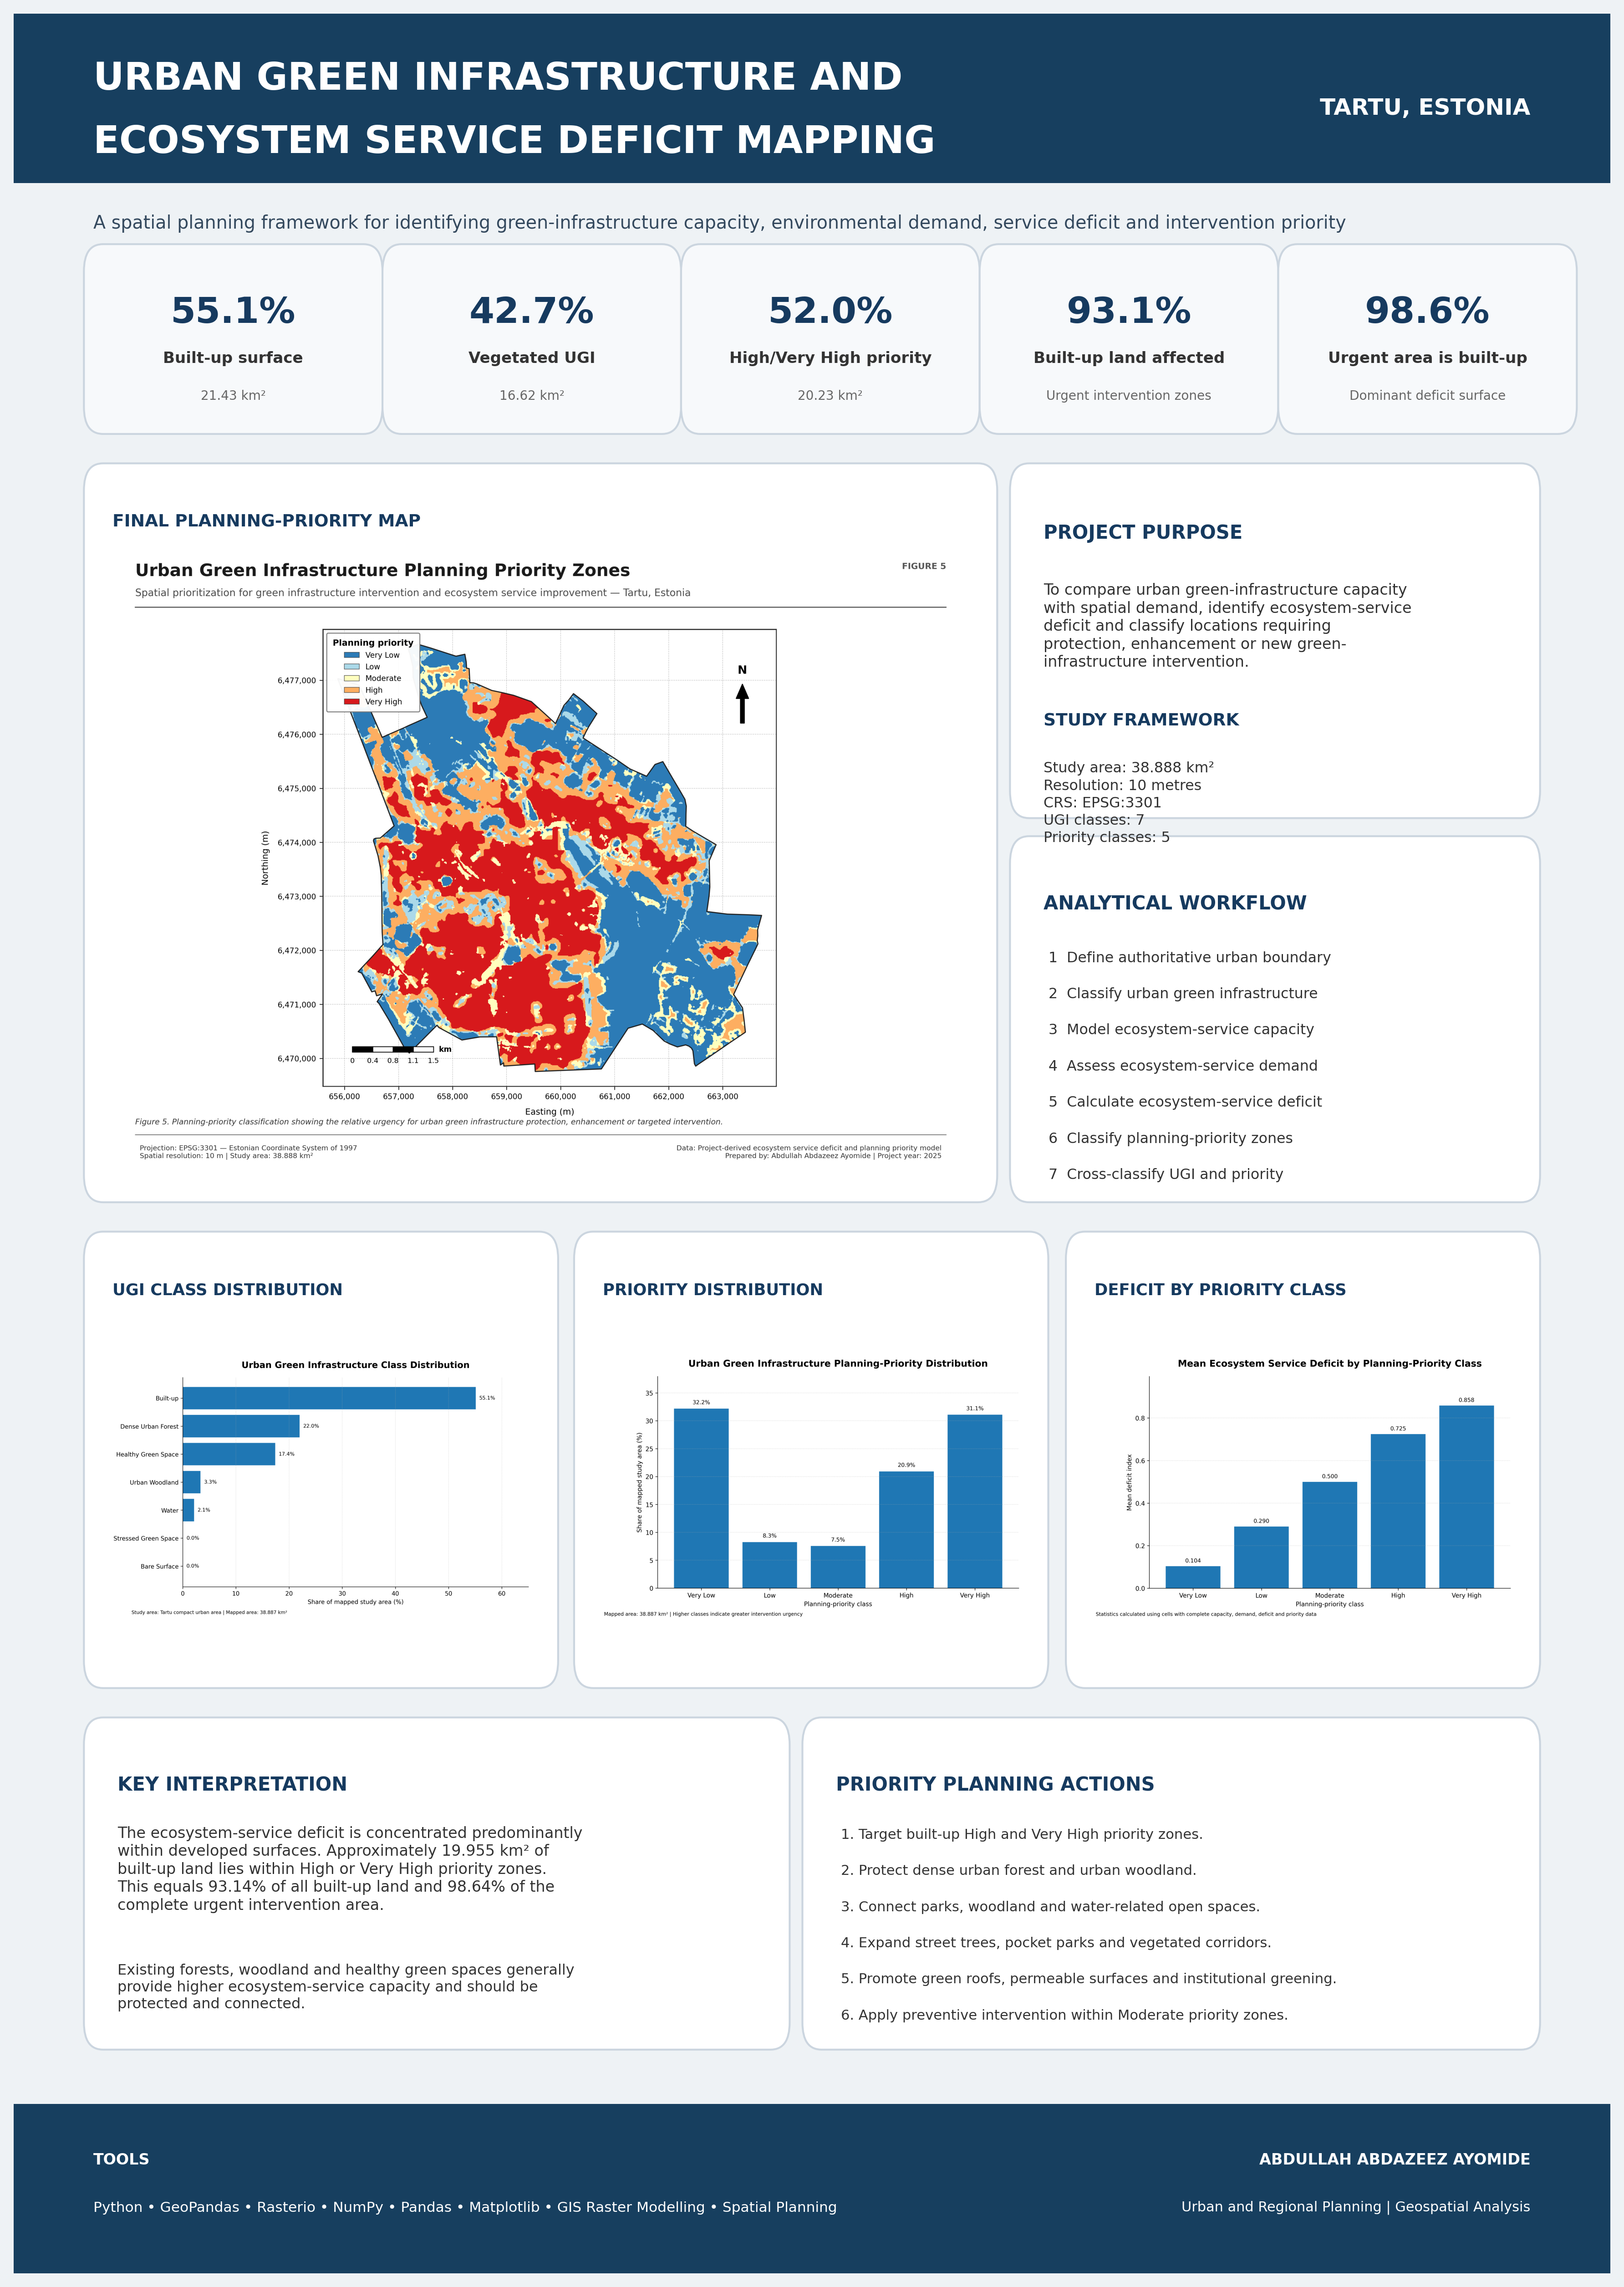


SECTION 13B VALIDATION


,Check,Expected,Observed,Passed
0,Final infographic PNG exists,True,True,True
1,Final infographic PDF exists,True,True,True
2,Required visual inputs found,4,4,True
3,PNG width suitable for publication,>= 3000 pixels,3507,True
4,PNG height suitable for publication,>= 4500 pixels,4962,True
5,PNG file is non-empty,> 0.5 MB,1.535844,True
6,PDF file is non-empty,> 0.2 MB,0.743437,True
7,Planning-priority map panel contains visible d...,Variation > 5.0,55.543729,True
8,UGI chart panel contains visible detail,Variation > 5.0,41.90438,True
9,Priority chart panel contains visible detail,Variation > 5.0,57.128261,True



SECTION 13B — FINAL INFOGRAPHIC COMPLETE
PNG infographic        : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/08_Infographic/Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.png
PDF infographic        : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/08_Infographic/Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.pdf
PNG dimensions         : 3507 × 4962 pixels
PNG recorded DPI       : (299.9994, 299.9994)
PNG size               : 1.54 MB
PDF size               : 0.74 MB

Visual panel variation:
  Planning-priority map : 55.54
  UGI chart             : 41.90
  Priority chart        : 57.13
  Deficit chart         : 56.19

Validation record      : /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/09_Validation/Section_13B_Final_Infographic_Validation.csv

✓ Final stand-alone infographic generated.
✓ Validated planning-priority map is visible.
✓ Thr

In [24]:
# ==============================================================================
# SECTION 13B — FINAL STAND-ALONE INFOGRAPHIC BOARD
# DEFINITIVE CORRECTED VERSION
# ==============================================================================

from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from matplotlib.patches import FancyBboxPatch, Rectangle
from PIL import Image


print("=" * 110)
print("SECTION 13B — FINAL STAND-ALONE INFOGRAPHIC BOARD")
print("=" * 110)


# ==============================================================================
# 1. DIRECTORY CONFIGURATION
# ==============================================================================

INFOGRAPHIC_DIR = (
    FINAL_DELIVERABLES_DIR
    / "08_Infographic"
)

VALIDATION_DIR = (
    FINAL_DELIVERABLES_DIR
    / "09_Validation"
)

INFOGRAPHIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


INFOGRAPHIC_PNG = (
    INFOGRAPHIC_DIR
    / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.png"
)

INFOGRAPHIC_PDF = (
    INFOGRAPHIC_DIR
    / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.pdf"
)

INFOGRAPHIC_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_13B_Final_Infographic_Validation.csv"
)


# ==============================================================================
# 2. REQUIRED VISUAL INPUTS
# ==============================================================================

priority_map_file = (
    MAP_DIR
    / "05_Planning_Priority_Zones.png"
)

ugi_chart_file = (
    CHART_DIR
    / "01_UGI_Class_Distribution.png"
)

priority_chart_file = (
    CHART_DIR
    / "02_Planning_Priority_Distribution.png"
)

deficit_chart_file = (
    CHART_DIR
    / "04_Mean_Deficit_by_Planning_Priority.png"
)


required_visual_files = [
    priority_map_file,
    ugi_chart_file,
    priority_chart_file,
    deficit_chart_file,
]


missing_visual_files = [
    str(file_path)
    for file_path in required_visual_files
    if not file_path.exists()
]


if missing_visual_files:

    raise FileNotFoundError(
        "The following required visual files are missing:\n"
        + "\n".join(missing_visual_files)
    )


print("\nVISUAL INPUTS VERIFIED")

for file_path in required_visual_files:
    print(f"✓ {file_path.name}")


# ==============================================================================
# 3. LOAD SOURCE IMAGES
# ==============================================================================

priority_map_img = mpimg.imread(
    priority_map_file
)

ugi_chart_img = mpimg.imread(
    ugi_chart_file
)

priority_chart_img = mpimg.imread(
    priority_chart_file
)

deficit_chart_img = mpimg.imread(
    deficit_chart_file
)


# ==============================================================================
# 4. DESIGN CONFIGURATION
# ==============================================================================

PAGE_BACKGROUND = "#EEF2F5"
HEADER_BACKGROUND = "#173F5F"
PRIMARY_TEXT = "#163A5F"
BODY_TEXT = "#333333"
SECONDARY_TEXT = "#666666"
PANEL_BACKGROUND = "#FFFFFF"
CARD_BACKGROUND = "#F7F9FB"
PANEL_BORDER = "#CBD5DF"


# ==============================================================================
# 5. HELPER FUNCTIONS
# ==============================================================================

def add_panel(
    figure,
    bounds,
    facecolor=PANEL_BACKGROUND,
    edgecolor=PANEL_BORDER,
    linewidth=1.0,
    radius=0.012
):
    """
    Add a rounded rectangular panel.

    The panel is placed below image axes and text.
    """

    panel = FancyBboxPatch(
        (bounds[0], bounds[1]),
        bounds[2],
        bounds[3],
        boxstyle=(
            f"round,pad=0.006,"
            f"rounding_size={radius}"
        ),
        transform=figure.transFigure,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=1
    )

    figure.patches.append(
        panel
    )

    return panel


def add_metric_card(
    figure,
    x,
    y,
    width,
    height,
    value,
    label,
    interpretation=None
):
    """
    Add a headline metric card.
    """

    add_panel(
        figure,
        [x, y, width, height],
        facecolor=CARD_BACKGROUND,
        edgecolor=PANEL_BORDER,
        linewidth=1.0
    )

    figure.text(
        x + width / 2,
        y + height * 0.66,
        value,
        ha="center",
        va="center",
        fontsize=19,
        fontweight="bold",
        color=PRIMARY_TEXT,
        zorder=4
    )

    figure.text(
        x + width / 2,
        y + height * 0.38,
        label,
        ha="center",
        va="center",
        fontsize=8.2,
        fontweight="bold",
        color=BODY_TEXT,
        zorder=4
    )

    if interpretation:

        figure.text(
            x + width / 2,
            y + height * 0.15,
            interpretation,
            ha="center",
            va="center",
            fontsize=6.7,
            color=SECONDARY_TEXT,
            zorder=4
        )


def add_image_panel(
    figure,
    bounds,
    image,
    title,
    title_fontsize=9
):
    """
    Add a source image inside a titled panel.
    """

    add_panel(
        figure,
        bounds,
        facecolor=PANEL_BACKGROUND,
        edgecolor=PANEL_BORDER,
        linewidth=1.0
    )

    figure.text(
        bounds[0] + 0.012,
        bounds[1] + bounds[3] - 0.020,
        title,
        ha="left",
        va="center",
        fontsize=title_fontsize,
        fontweight="bold",
        color=PRIMARY_TEXT,
        zorder=4
    )

    image_axis = figure.add_axes([
        bounds[0] + 0.010,
        bounds[1] + 0.010,
        bounds[2] - 0.020,
        bounds[3] - 0.045
    ])

    image_axis.set_zorder(
        3
    )

    image_axis.patch.set_alpha(
        0
    )

    # Matplotlib automatically preserves the image proportions.
    image_axis.imshow(
        image,
        interpolation="antialiased"
    )

    image_axis.axis(
        "off"
    )

    return image_axis


def add_wrapped_text(
    figure,
    x,
    y,
    text,
    width,
    fontsize=8,
    color=BODY_TEXT,
    weight="normal",
    line_spacing=1.25,
    va="top"
):
    """
    Add wrapped text to the infographic.
    """

    wrapped_text = textwrap.fill(
        text,
        width=width
    )

    figure.text(
        x,
        y,
        wrapped_text,
        ha="left",
        va=va,
        fontsize=fontsize,
        color=color,
        fontweight=weight,
        linespacing=line_spacing,
        zorder=4
    )


def crop_panel_from_image(
    image_array,
    bounds
):
    """
    Crop an infographic panel using normalized figure coordinates.
    """

    image_height, image_width = image_array.shape[:2]

    x0 = int(
        bounds[0] * image_width
    )

    x1 = int(
        (bounds[0] + bounds[2]) * image_width
    )

    y0 = int(
        (1 - bounds[1] - bounds[3])
        * image_height
    )

    y1 = int(
        (1 - bounds[1])
        * image_height
    )

    x0 = max(
        0,
        min(x0, image_width)
    )

    x1 = max(
        0,
        min(x1, image_width)
    )

    y0 = max(
        0,
        min(y0, image_height)
    )

    y1 = max(
        0,
        min(y1, image_height)
    )

    return image_array[
        y0:y1,
        x0:x1
    ]


def calculate_panel_variation(
    image_array,
    bounds
):
    """
    Calculate variation inside a panel.

    A populated map or chart should have more visual variation
    than an empty white panel.
    """

    crop = crop_panel_from_image(
        image_array,
        bounds
    )

    if crop.size == 0:
        return 0.0

    if crop.ndim == 3:

        grayscale = crop[
            ...,
            :3
        ].mean(
            axis=2
        )

    else:

        grayscale = crop

    return float(
        np.std(grayscale)
    )


# ==============================================================================
# 6. PANEL POSITIONS
# ==============================================================================

MAIN_MAP_BOUNDS = [
    0.05,
    0.480,
    0.56,
    0.315
]

UGI_CHART_BOUNDS = [
    0.05,
    0.265,
    0.285,
    0.190
]

PRIORITY_CHART_BOUNDS = [
    0.357,
    0.265,
    0.285,
    0.190
]

DEFICIT_CHART_BOUNDS = [
    0.665,
    0.265,
    0.285,
    0.190
]


# ==============================================================================
# 7. CREATE INFOGRAPHIC CANVAS
# ==============================================================================

fig = plt.figure(
    figsize=(
        11.69,
        16.54
    ),
    dpi=300,
    facecolor=PAGE_BACKGROUND
)


# ==============================================================================
# 8. HEADER
# ==============================================================================

header_rectangle = Rectangle(
    (0, 0.925),
    1,
    0.075,
    transform=fig.transFigure,
    facecolor=HEADER_BACKGROUND,
    edgecolor="none",
    zorder=1
)

fig.patches.append(
    header_rectangle
)


fig.text(
    0.05,
    0.971,
    "URBAN GREEN INFRASTRUCTURE AND",
    ha="left",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="white",
    zorder=4
)

fig.text(
    0.05,
    0.943,
    "ECOSYSTEM SERVICE DEFICIT MAPPING",
    ha="left",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="white",
    zorder=4
)

fig.text(
    0.95,
    0.958,
    "TARTU, ESTONIA",
    ha="right",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="white",
    zorder=4
)


# ==============================================================================
# 9. SUBTITLE
# ==============================================================================

fig.text(
    0.05,
    0.907,
    (
        "A spatial planning framework for identifying green-infrastructure "
        "capacity, environmental demand, service deficit and intervention priority"
    ),
    ha="left",
    va="center",
    fontsize=9.5,
    color="#34495E",
    zorder=4
)


# ==============================================================================
# 10. METRIC CARDS
# ==============================================================================

card_y = 0.820
card_height = 0.072
card_width = 0.175
card_gap = 0.012
card_start_x = 0.05


metric_cards = [
    (
        f"{built_up_percent:.1f}%",
        "Built-up surface",
        f"{built_up_area_km2:.2f} km²"
    ),
    (
        f"{vegetated_percent:.1f}%",
        "Vegetated UGI",
        f"{vegetated_area_km2:.2f} km²"
    ),
    (
        f"{high_very_high_percent:.1f}%",
        "High/Very High priority",
        f"{high_very_high_area_km2:.2f} km²"
    ),
    (
        f"{built_up_high_priority_percent:.1f}%",
        "Built-up land affected",
        "Urgent intervention zones"
    ),
    (
        f"{built_up_share_of_urgent_area:.1f}%",
        "Urgent area is built-up",
        "Dominant deficit surface"
    ),
]


for index, metric in enumerate(
    metric_cards
):

    add_metric_card(
        fig,
        card_start_x
        + index
        * (
            card_width
            + card_gap
        ),
        card_y,
        card_width,
        card_height,
        metric[0],
        metric[1],
        metric[2]
    )


# ==============================================================================
# 11. MAIN PLANNING-PRIORITY MAP
# ==============================================================================

add_image_panel(
    fig,
    MAIN_MAP_BOUNDS,
    priority_map_img,
    "FINAL PLANNING-PRIORITY MAP",
    title_fontsize=9
)


# ==============================================================================
# 12. PROJECT PURPOSE PANEL
# ==============================================================================

overview_bounds = [
    0.63,
    0.650,
    0.32,
    0.145
]

add_panel(
    fig,
    overview_bounds,
    facecolor=PANEL_BACKGROUND
)

fig.text(
    0.645,
    0.770,
    "PROJECT PURPOSE",
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=PRIMARY_TEXT,
    zorder=4
)


overview_text = (
    "To compare urban green-infrastructure capacity with spatial demand, "
    "identify ecosystem-service deficit and classify locations requiring "
    "protection, enhancement or new green-infrastructure intervention."
)

add_wrapped_text(
    fig,
    0.645,
    0.748,
    overview_text,
    width=48,
    fontsize=8.0
)


fig.text(
    0.645,
    0.687,
    "STUDY FRAMEWORK",
    ha="left",
    va="center",
    fontsize=9,
    fontweight="bold",
    color=PRIMARY_TEXT,
    zorder=4
)


study_framework_text = (
    f"Study area: {boundary_vector_area_km2:.3f} km²\n"
    "Resolution: 10 metres\n"
    "CRS: EPSG:3301\n"
    "UGI classes: 7\n"
    "Priority classes: 5"
)

fig.text(
    0.645,
    0.669,
    study_framework_text,
    ha="left",
    va="top",
    fontsize=7.6,
    color=BODY_TEXT,
    linespacing=1.30,
    zorder=4
)


# ==============================================================================
# 13. ANALYTICAL WORKFLOW PANEL
# ==============================================================================

workflow_bounds = [
    0.63,
    0.480,
    0.32,
    0.150
]

add_panel(
    fig,
    workflow_bounds,
    facecolor=PANEL_BACKGROUND
)

fig.text(
    0.645,
    0.606,
    "ANALYTICAL WORKFLOW",
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=PRIMARY_TEXT,
    zorder=4
)


workflow_steps = [
    "1  Define authoritative urban boundary",
    "2  Classify urban green infrastructure",
    "3  Model ecosystem-service capacity",
    "4  Assess ecosystem-service demand",
    "5  Calculate ecosystem-service deficit",
    "6  Classify planning-priority zones",
    "7  Cross-classify UGI and priority",
]


workflow_y = 0.582

for step in workflow_steps:

    fig.text(
        0.648,
        workflow_y,
        step,
        ha="left",
        va="center",
        fontsize=7.6,
        color=BODY_TEXT,
        zorder=4
    )

    workflow_y -= 0.016


# ==============================================================================
# 14. ANALYTICAL CHART PANELS
# ==============================================================================

add_image_panel(
    fig,
    UGI_CHART_BOUNDS,
    ugi_chart_img,
    "UGI CLASS DISTRIBUTION",
    title_fontsize=8.5
)

add_image_panel(
    fig,
    PRIORITY_CHART_BOUNDS,
    priority_chart_img,
    "PRIORITY DISTRIBUTION",
    title_fontsize=8.5
)

add_image_panel(
    fig,
    DEFICIT_CHART_BOUNDS,
    deficit_chart_img,
    "DEFICIT BY PRIORITY CLASS",
    title_fontsize=8.5
)


# ==============================================================================
# 15. KEY INTERPRETATION PANEL
# ==============================================================================

interpretation_bounds = [
    0.05,
    0.105,
    0.43,
    0.135
]

add_panel(
    fig,
    interpretation_bounds,
    facecolor=PANEL_BACKGROUND
)

fig.text(
    0.065,
    0.216,
    "KEY INTERPRETATION",
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=PRIMARY_TEXT,
    zorder=4
)


interpretation_text = (
    f"The ecosystem-service deficit is concentrated predominantly within "
    f"developed surfaces. Approximately "
    f"{built_up_high_priority_area_km2:.3f} km² of built-up land lies within "
    f"High or Very High priority zones. This equals "
    f"{built_up_high_priority_percent:.2f}% of all built-up land and "
    f"{built_up_share_of_urgent_area:.2f}% of the complete urgent "
    f"intervention area."
)

add_wrapped_text(
    fig,
    0.065,
    0.198,
    interpretation_text,
    width=60,
    fontsize=8.0
)


secondary_interpretation = (
    "Existing forests, woodland and healthy green spaces generally provide "
    "higher ecosystem-service capacity and should be protected and connected."
)

add_wrapped_text(
    fig,
    0.065,
    0.137,
    secondary_interpretation,
    width=62,
    fontsize=7.7
)


# ==============================================================================
# 16. PRIORITY PLANNING ACTIONS PANEL
# ==============================================================================

actions_bounds = [
    0.50,
    0.105,
    0.45,
    0.135
]

add_panel(
    fig,
    actions_bounds,
    facecolor=PANEL_BACKGROUND
)

fig.text(
    0.515,
    0.216,
    "PRIORITY PLANNING ACTIONS",
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=PRIMARY_TEXT,
    zorder=4
)


planning_actions = [
    "Target built-up High and Very High priority zones.",
    "Protect dense urban forest and urban woodland.",
    "Connect parks, woodland and water-related open spaces.",
    "Expand street trees, pocket parks and vegetated corridors.",
    "Promote green roofs, permeable surfaces and institutional greening.",
    "Apply preventive intervention within Moderate priority zones.",
]


action_y = 0.194

for number, action in enumerate(
    planning_actions,
    start=1
):

    fig.text(
        0.518,
        action_y,
        f"{number}. {action}",
        ha="left",
        va="center",
        fontsize=7.35,
        color=BODY_TEXT,
        zorder=4
    )

    action_y -= 0.016


# ==============================================================================
# 17. FOOTER
# ==============================================================================

footer_rectangle = Rectangle(
    (0, 0),
    1,
    0.075,
    transform=fig.transFigure,
    facecolor=HEADER_BACKGROUND,
    edgecolor="none",
    zorder=1
)

fig.patches.append(
    footer_rectangle
)


fig.text(
    0.05,
    0.050,
    "TOOLS",
    ha="left",
    va="center",
    fontsize=8,
    fontweight="bold",
    color="white",
    zorder=4
)

fig.text(
    0.05,
    0.029,
    (
        "Python • GeoPandas • Rasterio • NumPy • Pandas • "
        "Matplotlib • GIS Raster Modelling • Spatial Planning"
    ),
    ha="left",
    va="center",
    fontsize=7.5,
    color="white",
    zorder=4
)

fig.text(
    0.95,
    0.050,
    "ABDULLAH ABDAZEEZ AYOMIDE",
    ha="right",
    va="center",
    fontsize=8,
    fontweight="bold",
    color="white",
    zorder=4
)

fig.text(
    0.95,
    0.029,
    "Urban and Regional Planning | Geospatial Analysis",
    ha="right",
    va="center",
    fontsize=7.3,
    color="white",
    zorder=4
)


# ==============================================================================
# 18. EXPORT INFOGRAPHIC
# ==============================================================================

# No bbox_inches="tight" is used.
# This preserves the exact A4 canvas and panel-coordinate locations.

fig.savefig(
    INFOGRAPHIC_PNG,
    dpi=300,
    facecolor=fig.get_facecolor()
)

fig.savefig(
    INFOGRAPHIC_PDF,
    facecolor=fig.get_facecolor()
)

plt.show()

plt.close(
    fig
)


# ==============================================================================
# 19. OUTPUT FILE VALIDATION
# ==============================================================================

if not INFOGRAPHIC_PNG.exists():

    raise FileNotFoundError(
        f"Infographic PNG was not created: "
        f"{INFOGRAPHIC_PNG}"
    )


if not INFOGRAPHIC_PDF.exists():

    raise FileNotFoundError(
        f"Infographic PDF was not created: "
        f"{INFOGRAPHIC_PDF}"
    )


with Image.open(
    INFOGRAPHIC_PNG
) as infographic_image:

    infographic_width = (
        infographic_image.width
    )

    infographic_height = (
        infographic_image.height
    )

    infographic_dpi = (
        infographic_image.info.get(
            "dpi",
            (None, None)
        )
    )

    exported_image_array = np.asarray(
        infographic_image.convert(
            "RGB"
        )
    )


png_size_mb = (
    INFOGRAPHIC_PNG.stat().st_size
    / (1024 ** 2)
)

pdf_size_mb = (
    INFOGRAPHIC_PDF.stat().st_size
    / (1024 ** 2)
)


# ==============================================================================
# 20. VISUAL PANEL VALIDATION
# ==============================================================================

main_map_variation = calculate_panel_variation(
    exported_image_array,
    MAIN_MAP_BOUNDS
)

ugi_chart_variation = calculate_panel_variation(
    exported_image_array,
    UGI_CHART_BOUNDS
)

priority_chart_variation = calculate_panel_variation(
    exported_image_array,
    PRIORITY_CHART_BOUNDS
)

deficit_chart_variation = calculate_panel_variation(
    exported_image_array,
    DEFICIT_CHART_BOUNDS
)


PANEL_VARIATION_THRESHOLD = 5.0


# ==============================================================================
# 21. SECTION 13B VALIDATION TABLE
# ==============================================================================

section_13b_validation = pd.DataFrame([
    {
        "Check": "Final infographic PNG exists",
        "Expected": True,
        "Observed": INFOGRAPHIC_PNG.exists(),
        "Passed": INFOGRAPHIC_PNG.exists(),
    },
    {
        "Check": "Final infographic PDF exists",
        "Expected": True,
        "Observed": INFOGRAPHIC_PDF.exists(),
        "Passed": INFOGRAPHIC_PDF.exists(),
    },
    {
        "Check": "Required visual inputs found",
        "Expected": 4,
        "Observed": sum(
            file_path.exists()
            for file_path in required_visual_files
        ),
        "Passed": all(
            file_path.exists()
            for file_path in required_visual_files
        ),
    },
    {
        "Check": "PNG width suitable for publication",
        "Expected": ">= 3000 pixels",
        "Observed": infographic_width,
        "Passed": infographic_width >= 3000,
    },
    {
        "Check": "PNG height suitable for publication",
        "Expected": ">= 4500 pixels",
        "Observed": infographic_height,
        "Passed": infographic_height >= 4500,
    },
    {
        "Check": "PNG file is non-empty",
        "Expected": "> 0.5 MB",
        "Observed": png_size_mb,
        "Passed": png_size_mb > 0.5,
    },
    {
        "Check": "PDF file is non-empty",
        "Expected": "> 0.2 MB",
        "Observed": pdf_size_mb,
        "Passed": pdf_size_mb > 0.2,
    },
    {
        "Check": "Planning-priority map panel contains visible detail",
        "Expected": (
            f"Variation > "
            f"{PANEL_VARIATION_THRESHOLD}"
        ),
        "Observed": main_map_variation,
        "Passed": (
            main_map_variation
            > PANEL_VARIATION_THRESHOLD
        ),
    },
    {
        "Check": "UGI chart panel contains visible detail",
        "Expected": (
            f"Variation > "
            f"{PANEL_VARIATION_THRESHOLD}"
        ),
        "Observed": ugi_chart_variation,
        "Passed": (
            ugi_chart_variation
            > PANEL_VARIATION_THRESHOLD
        ),
    },
    {
        "Check": "Priority chart panel contains visible detail",
        "Expected": (
            f"Variation > "
            f"{PANEL_VARIATION_THRESHOLD}"
        ),
        "Observed": priority_chart_variation,
        "Passed": (
            priority_chart_variation
            > PANEL_VARIATION_THRESHOLD
        ),
    },
    {
        "Check": "Deficit chart panel contains visible detail",
        "Expected": (
            f"Variation > "
            f"{PANEL_VARIATION_THRESHOLD}"
        ),
        "Observed": deficit_chart_variation,
        "Passed": (
            deficit_chart_variation
            > PANEL_VARIATION_THRESHOLD
        ),
    },
])


section_13b_validation.to_csv(
    INFOGRAPHIC_VALIDATION_FILE,
    index=False
)


print("\n" + "=" * 110)
print("SECTION 13B VALIDATION")
print("=" * 110)

display(
    section_13b_validation.round({
        "Observed": 3
    })
)


if not section_13b_validation[
    "Passed"
].all():

    failed_checks = section_13b_validation.loc[
        ~section_13b_validation["Passed"],
        "Check"
    ].tolist()

    raise ValueError(
        "Section 13B validation failed:\n"
        + "\n".join(failed_checks)
    )


# ==============================================================================
# 22. FINAL CONFIRMATION
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 13B — FINAL INFOGRAPHIC COMPLETE")
print("=" * 110)

print(
    f"PNG infographic        : "
    f"{INFOGRAPHIC_PNG}"
)

print(
    f"PDF infographic        : "
    f"{INFOGRAPHIC_PDF}"
)

print(
    f"PNG dimensions         : "
    f"{infographic_width} × "
    f"{infographic_height} pixels"
)

print(
    f"PNG recorded DPI       : "
    f"{infographic_dpi}"
)

print(
    f"PNG size               : "
    f"{png_size_mb:.2f} MB"
)

print(
    f"PDF size               : "
    f"{pdf_size_mb:.2f} MB"
)

print("\nVisual panel variation:")

print(
    f"  Planning-priority map : "
    f"{main_map_variation:.2f}"
)

print(
    f"  UGI chart             : "
    f"{ugi_chart_variation:.2f}"
)

print(
    f"  Priority chart        : "
    f"{priority_chart_variation:.2f}"
)

print(
    f"  Deficit chart         : "
    f"{deficit_chart_variation:.2f}"
)

print(
    f"\nValidation record      : "
    f"{INFOGRAPHIC_VALIDATION_FILE}"
)

print("\n✓ Final stand-alone infographic generated.")
print("✓ Validated planning-priority map is visible.")
print("✓ Three analytical charts are visible.")
print("✓ Chart headings do not overlap.")
print("✓ Key results and planning actions included.")
print("✓ High-resolution PNG and PDF versions exported.")
print("✓ Visual-content validation passed.")
print("✓ Section 13B validation passed.")

In [29]:
# ==============================================================================
# SECTION 13C — DEFINITIVE FINAL DELIVERABLES PACKAGE AND PROJECT CLOSURE
# ==============================================================================

import hashlib
import json
import shutil
import zipfile
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd


print("=" * 110)
print("SECTION 13C — DEFINITIVE FINAL DELIVERABLES PACKAGE AND PROJECT CLOSURE")
print("=" * 110)


# ==============================================================================
# 1. PROJECT AND PACKAGE PATHS
# ==============================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Project_9_Tartu_UGI_Ecosystem_Service_Deficit"
)

FINAL_DELIVERABLES_DIR = (
    PROJECT_ROOT
    / "18_Final_Deliverables"
    / "11_Notebook"
    / "Project_9_Final_Production.ipynb"
)

FINAL_PACKAGE_DIR = (
    PROJECT_ROOT
    / "19_Final_Deliverables_Package"
)

FINAL_PACKAGE_NAME = (
    "Project_9_Tartu_UGI_Ecosystem_Service_Deficit_FINAL"
)

FINAL_PACKAGE_PROJECT_DIR = (
    FINAL_PACKAGE_DIR
    / FINAL_PACKAGE_NAME
)

FINAL_ZIP_FILE = (
    FINAL_PACKAGE_DIR
    / f"{FINAL_PACKAGE_NAME}.zip"
)

FINAL_PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VALIDATION_DIR = (
    FINAL_DELIVERABLES_DIR
    / "09_Validation"
)

VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==============================================================================
# 2. VERIFY FINAL DELIVERABLES DIRECTORY
# ==============================================================================

if not FINAL_DELIVERABLES_DIR.exists():

    raise FileNotFoundError(
        f"Final deliverables directory not found: "
        f"{FINAL_DELIVERABLES_DIR}"
    )


print(f"\nFinal deliverables directory:")
print(f"  {FINAL_DELIVERABLES_DIR}")


# ==============================================================================
# 3. REQUIRED FINAL OUTPUTS
# ==============================================================================

required_outputs = {
    "Final UGI map PNG":
        FINAL_DELIVERABLES_DIR
        / "01_Maps"
        / "01_Urban_Green_Infrastructure.png",

    "Final capacity map PNG":
        FINAL_DELIVERABLES_DIR
        / "01_Maps"
        / "02_Ecosystem_Service_Capacity.png",

    "Final demand map PNG":
        FINAL_DELIVERABLES_DIR
        / "01_Maps"
        / "03_Ecosystem_Service_Demand.png",

    "Final deficit map PNG":
        FINAL_DELIVERABLES_DIR
        / "01_Maps"
        / "04_Ecosystem_Service_Deficit.png",

    "Final priority map PNG":
        FINAL_DELIVERABLES_DIR
        / "01_Maps"
        / "05_Planning_Priority_Zones.png",

    "UGI distribution chart":
        FINAL_DELIVERABLES_DIR
        / "02_Charts"
        / "01_UGI_Class_Distribution.png",

    "Priority distribution chart":
        FINAL_DELIVERABLES_DIR
        / "02_Charts"
        / "02_Planning_Priority_Distribution.png",

    "Indicator distributions chart":
        FINAL_DELIVERABLES_DIR
        / "02_Charts"
        / "03_Ecosystem_Service_Indicator_Distributions.png",

    "Deficit-priority chart":
        FINAL_DELIVERABLES_DIR
        / "02_Charts"
        / "04_Mean_Deficit_by_Planning_Priority.png",

    "Capacity-demand-deficit chart":
        FINAL_DELIVERABLES_DIR
        / "02_Charts"
        / "05_Capacity_Demand_Deficit_Relationship.png",

    "UGI-priority heatmap":
        FINAL_DELIVERABLES_DIR
        / "02_Charts"
        / "06_UGI_by_Planning_Priority_Heatmap.png",

    "Authoritative study-area mask":
        FINAL_DELIVERABLES_DIR
        / "03_GIS_Data"
        / "Tartu_Authoritative_Study_Area_Mask.tif",

    "UGI statistics":
        FINAL_DELIVERABLES_DIR
        / "04_Tables"
        / "Final_UGI_Class_Statistics.csv",

    "Planning priority statistics":
        FINAL_DELIVERABLES_DIR
        / "04_Tables"
        / "Final_Planning_Priority_Statistics.csv",

    "Key project results":
        FINAL_DELIVERABLES_DIR
        / "04_Tables"
        / "Final_Project_Key_Results.csv",

    "Planning action register":
        FINAL_DELIVERABLES_DIR
        / "04_Tables"
        / "Final_Planning_Action_Register.csv",

    "Final technical report DOCX":
        FINAL_DELIVERABLES_DIR
        / "06_Final_Report"
        / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.docx",

    "Final technical report PDF":
        FINAL_DELIVERABLES_DIR
        / "06_Final_Report"
        / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.pdf",

    "Portfolio project description":
        FINAL_DELIVERABLES_DIR
        / "07_Portfolio"
        / "01_Final_Portfolio_Project_Description.md",

    "CV-ready entry":
        FINAL_DELIVERABLES_DIR
        / "07_Portfolio"
        / "02_CV_Ready_Project_Entry.txt",

    "Scholarship entry":
        FINAL_DELIVERABLES_DIR
        / "07_Portfolio"
        / "03_Scholarship_Portfolio_Entry.txt",

    "Final infographic PNG":
        FINAL_DELIVERABLES_DIR
        / "08_Infographic"
        / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.png",

    "Final infographic PDF":
        FINAL_DELIVERABLES_DIR
        / "08_Infographic"
        / "Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.pdf",

    "GitHub README":
        FINAL_DELIVERABLES_DIR
        / "10_GitHub_Documentation"
        / "README.md",

    "GitHub methodology":
        FINAL_DELIVERABLES_DIR
        / "10_GitHub_Documentation"
        / "METHODOLOGY.md",

    "Citation file":
        FINAL_DELIVERABLES_DIR
        / "10_GitHub_Documentation"
        / "CITATION.cff",

    "Project metadata":
        FINAL_DELIVERABLES_DIR
        / "10_GitHub_Documentation"
        / "project_metadata.json",
}


required_output_rows = []

for label, file_path in required_outputs.items():

    required_output_rows.append({
        "Required_Output": label,
        "File": file_path.name,
        "Path": str(file_path),
        "Exists": file_path.exists(),
        "Size_MB": (
            file_path.stat().st_size / (1024 ** 2)
            if file_path.exists()
            else 0
        ),
    })


required_output_register = pd.DataFrame(
    required_output_rows
)


print("\n" + "=" * 110)
print("VERIFYING REQUIRED FINAL OUTPUTS")
print("=" * 110)

display(
    required_output_register.round({
        "Size_MB": 3
    })
)


if not required_output_register["Exists"].all():

    missing_outputs = required_output_register.loc[
        ~required_output_register["Exists"],
        ["Required_Output", "Path"]
    ]

    raise FileNotFoundError(
        "Required final outputs are missing:\n"
        + missing_outputs.to_string(
            index=False
        )
    )


# ==============================================================================
# 4. LOCATE AND COPY FINAL NOTEBOOK
# ==============================================================================

notebook_candidates = [
    PROJECT_ROOT
    / "Project_9_Final_Production.ipynb",

    Path(
        "/content/drive/MyDrive/"
        "Project_9_Final_Production.ipynb"
    ),

    (
        PROJECT_ROOT
        / "01_Notebooks"
        / "Project_9_Final_Production.ipynb"
    ),

    (
        PROJECT_ROOT
        / "18_Final_Deliverables"
        / "11_Notebook"
        / "Project_9_Final_Production.ipynb"
    ),
]


FINAL_NOTEBOOK_SOURCE = None

for candidate in notebook_candidates:

    if candidate.exists():

        FINAL_NOTEBOOK_SOURCE = candidate
        break


NOTEBOOK_PACKAGE_DIR = (
    FINAL_DELIVERABLES_DIR
    / "11_Notebook"
)

NOTEBOOK_PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FINAL_NOTEBOOK_COPY = (
    NOTEBOOK_PACKAGE_DIR
    / "Project_9_Final_Production.ipynb"
)


if FINAL_NOTEBOOK_SOURCE is not None:

    shutil.copy2(
        FINAL_NOTEBOOK_SOURCE,
        FINAL_NOTEBOOK_COPY
    )

    notebook_status = "Copied"

else:

    notebook_status = "Source notebook not automatically located"

    notebook_note_file = (
        NOTEBOOK_PACKAGE_DIR
        / "Notebook_Source_Note.txt"
    )

    notebook_note_file.write_text(
        (
            "The final production notebook could not be located automatically. "
            "Download Project_9_Final_Production.ipynb from Google Colab and "
            "place it in this folder before publishing the repository."
        ),
        encoding="utf-8"
    )


print("\nFINAL NOTEBOOK STATUS")
print(f"  {notebook_status}")

if FINAL_NOTEBOOK_COPY.exists():
    print(f"  {FINAL_NOTEBOOK_COPY}")


# ==============================================================================
# 5. PROJECT README FOR FINAL PACKAGE
# ==============================================================================

FINAL_PACKAGE_README = (
    FINAL_DELIVERABLES_DIR
    / "00_READ_ME_FIRST.txt"
)


package_readme_text = f"""
PROJECT 9 — FINAL DELIVERABLES PACKAGE

Project title:
Urban Green Infrastructure and Ecosystem Service Deficit Mapping — Tartu, Estonia

Author:
Abdullah Abdazeez Ayomide

Study area:
Tartu compact urban area, Estonia

Authoritative study area:
{boundary_vector_area_km2:.3f} km²

Production resolution:
10 metres

Production CRS:
EPSG:3301

Core results:
- Built-up area: {built_up_area_km2:.3f} km² ({built_up_percent:.2f}%)
- Vegetated UGI: {vegetated_area_km2:.3f} km² ({vegetated_percent:.2f}%)
- High and Very High priority: {high_very_high_area_km2:.3f} km²
  ({high_very_high_percent:.2f}%)
- Built-up land in High/Very High zones:
  {built_up_high_priority_area_km2:.3f} km²
- Share of built-up land affected:
  {built_up_high_priority_percent:.2f}%

Package contents:
01_Maps
02_Charts
03_GIS_Data
04_Tables
06_Final_Report
07_Portfolio
08_Infographic
09_Validation
10_GitHub_Documentation
11_Notebook

Important outputs:
- Five final planning and analytical maps
- Six report-ready charts
- Final statistical tables
- Authoritative study-area mask
- Final technical report in DOCX and PDF
- Stand-alone infographic in PNG and PDF
- Portfolio, CV and scholarship content
- GitHub documentation
- Validation registers and checksums

Generated:
{datetime.now(timezone.utc).isoformat()}

This package contains the definitive validated outputs for the project.
""".strip()


FINAL_PACKAGE_README.write_text(
    package_readme_text,
    encoding="utf-8"
)


# ==============================================================================
# 6. REMOVE PREVIOUS PACKAGE COPY
# ==============================================================================

if FINAL_PACKAGE_PROJECT_DIR.exists():

    shutil.rmtree(
        FINAL_PACKAGE_PROJECT_DIR
    )


if FINAL_ZIP_FILE.exists():

    FINAL_ZIP_FILE.unlink()


# ==============================================================================
# 7. COPY FINAL DELIVERABLES INTO PACKAGE DIRECTORY
# ==============================================================================

shutil.copytree(
    FINAL_DELIVERABLES_DIR,
    FINAL_PACKAGE_PROJECT_DIR
)


if not FINAL_PACKAGE_PROJECT_DIR.exists():

    raise FileNotFoundError(
        "Final package directory was not created."
    )


# ==============================================================================
# 8. FILE MANIFEST
# ==============================================================================

def calculate_sha256(
    file_path,
    chunk_size=1024 * 1024
):
    """
    Calculate SHA256 checksum for a file.
    """

    sha256_hash = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file_object:

        while True:

            chunk = file_object.read(
                chunk_size
            )

            if not chunk:
                break

            sha256_hash.update(
                chunk
            )

    return sha256_hash.hexdigest()


manifest_rows = []


for file_path in sorted(
    FINAL_PACKAGE_PROJECT_DIR.rglob("*")
):

    if not file_path.is_file():
        continue

    relative_path = file_path.relative_to(
        FINAL_PACKAGE_PROJECT_DIR
    )

    manifest_rows.append({
        "Relative_Path": str(relative_path),
        "File_Name": file_path.name,
        "Extension": file_path.suffix.lower(),
        "Size_Bytes": file_path.stat().st_size,
        "Size_MB": (
            file_path.stat().st_size
            / (1024 ** 2)
        ),
        "SHA256": calculate_sha256(
            file_path
        ),
    })


package_manifest = pd.DataFrame(
    manifest_rows
)


PACKAGE_MANIFEST_FILE = (
    FINAL_PACKAGE_PROJECT_DIR
    / "Final_Project_File_Manifest.csv"
)

package_manifest.to_csv(
    PACKAGE_MANIFEST_FILE,
    index=False
)


PACKAGE_MANIFEST_JSON = (
    FINAL_PACKAGE_PROJECT_DIR
    / "Final_Project_File_Manifest.json"
)

PACKAGE_MANIFEST_JSON.write_text(
    json.dumps(
        manifest_rows,
        indent=4,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# Recalculate manifest after adding manifest files

manifest_rows = []

for file_path in sorted(
    FINAL_PACKAGE_PROJECT_DIR.rglob("*")
):

    if not file_path.is_file():
        continue

    relative_path = file_path.relative_to(
        FINAL_PACKAGE_PROJECT_DIR
    )

    manifest_rows.append({
        "Relative_Path": str(relative_path),
        "File_Name": file_path.name,
        "Extension": file_path.suffix.lower(),
        "Size_Bytes": file_path.stat().st_size,
        "Size_MB": (
            file_path.stat().st_size
            / (1024 ** 2)
        ),
        "SHA256": calculate_sha256(
            file_path
        ),
    })


package_manifest = pd.DataFrame(
    manifest_rows
)

package_manifest.to_csv(
    PACKAGE_MANIFEST_FILE,
    index=False
)


print("\n" + "=" * 110)
print("FINAL PACKAGE FILE MANIFEST")
print("=" * 110)

print(
    f"Files registered: "
    f"{len(package_manifest)}"
)

print(
    f"Total package size before ZIP: "
    f"{package_manifest['Size_MB'].sum():.2f} MB"
)

display(
    package_manifest[
        [
            "Relative_Path",
            "Size_MB",
            "SHA256"
        ]
    ].head(20).round({
        "Size_MB": 3
    })
)


# ==============================================================================
# 9. CREATE FINAL ZIP ARCHIVE
# ==============================================================================

with zipfile.ZipFile(
    FINAL_ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=9
) as zip_archive:

    for file_path in sorted(
        FINAL_PACKAGE_PROJECT_DIR.rglob("*")
    ):

        if not file_path.is_file():
            continue

        archive_name = (
            Path(FINAL_PACKAGE_NAME)
            / file_path.relative_to(
                FINAL_PACKAGE_PROJECT_DIR
            )
        )

        zip_archive.write(
            file_path,
            arcname=str(archive_name)
        )


if not FINAL_ZIP_FILE.exists():

    raise FileNotFoundError(
        "Final ZIP archive was not created."
    )


# ==============================================================================
# 10. ZIP INTEGRITY VALIDATION
# ==============================================================================

with zipfile.ZipFile(
    FINAL_ZIP_FILE,
    mode="r"
) as zip_archive:

    zip_members = zip_archive.namelist()

    corrupt_member = zip_archive.testzip()


zip_integrity_passed = (
    corrupt_member is None
)


zip_sha256 = calculate_sha256(
    FINAL_ZIP_FILE
)

zip_size_mb = (
    FINAL_ZIP_FILE.stat().st_size
    / (1024 ** 2)
)


# ==============================================================================
# 11. REQUIRED ZIP MEMBERS
# ==============================================================================

required_zip_suffixes = [
    "00_READ_ME_FIRST.txt",

    "01_Maps/01_Urban_Green_Infrastructure.png",
    "01_Maps/05_Planning_Priority_Zones.png",

    "02_Charts/01_UGI_Class_Distribution.png",
    "02_Charts/06_UGI_by_Planning_Priority_Heatmap.png",

    "03_GIS_Data/Tartu_Authoritative_Study_Area_Mask.tif",

    "04_Tables/Final_Project_Key_Results.csv",
    "04_Tables/Final_Planning_Action_Register.csv",

    (
        "06_Final_Report/"
        "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.docx"
    ),

    (
        "06_Final_Report/"
        "Tartu_UGI_Ecosystem_Service_Deficit_Final_Technical_Report.pdf"
    ),

    (
        "08_Infographic/"
        "Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.png"
    ),

    (
        "08_Infographic/"
        "Tartu_UGI_Ecosystem_Service_Deficit_Final_Infographic.pdf"
    ),

    "10_GitHub_Documentation/README.md",
    "10_GitHub_Documentation/METHODOLOGY.md",

    "Final_Project_File_Manifest.csv",
]


zip_member_checks = []


for required_suffix in required_zip_suffixes:

    matching_members = [
        member
        for member in zip_members
        if member.endswith(
            required_suffix
        )
    ]

    zip_member_checks.append({
        "Required_Member": required_suffix,
        "Found": len(matching_members) > 0,
        "Matching_Member": (
            matching_members[0]
            if matching_members
            else ""
        ),
    })


zip_member_validation = pd.DataFrame(
    zip_member_checks
)


required_members_complete = (
    zip_member_validation["Found"].all()
)


print("\n" + "=" * 110)
print("REQUIRED ZIP MEMBER VALIDATION")
print("=" * 110)

display(
    zip_member_validation
)


# ==============================================================================
# 12. PROJECT CLOSURE SUMMARY
# ==============================================================================

closure_summary = {
    "project_title": (
        "Urban Green Infrastructure and Ecosystem "
        "Service Deficit Mapping — Tartu, Estonia"
    ),
    "author": "Abdullah Abdazeez Ayomide",
    "final_package_directory": str(
        FINAL_PACKAGE_PROJECT_DIR
    ),
    "final_zip_archive": str(
        FINAL_ZIP_FILE
    ),
    "zip_archive_size_mb": round(
        zip_size_mb,
        3
    ),
    "zip_archive_members": len(
        zip_members
    ),
    "zip_integrity_passed": zip_integrity_passed,
    "required_members_complete": bool(
        required_members_complete
    ),
    "zip_sha256": zip_sha256,
    "required_outputs_verified": int(
        required_output_register["Exists"].sum()
    ),
    "required_outputs_expected": len(
        required_output_register
    ),
    "package_files_registered": len(
        package_manifest
    ),
    "notebook_status": notebook_status,
    "generated_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}


CLOSURE_SUMMARY_JSON = (
    FINAL_PACKAGE_PROJECT_DIR
    / "Definitive_Project_Closure_Summary.json"
)

CLOSURE_SUMMARY_JSON.write_text(
    json.dumps(
        closure_summary,
        indent=4,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


CLOSURE_SUMMARY_TXT = (
    FINAL_PACKAGE_PROJECT_DIR
    / "Definitive_Project_Closure_Summary.txt"
)

closure_summary_text = f"""
DEFINITIVE PROJECT CLOSURE SUMMARY

Project title:
{closure_summary["project_title"]}

Author:
{closure_summary["author"]}

Final package directory:
{closure_summary["final_package_directory"]}

Final ZIP archive:
{closure_summary["final_zip_archive"]}

ZIP archive size:
{closure_summary["zip_archive_size_mb"]:.3f} MB

ZIP archive members:
{closure_summary["zip_archive_members"]}

ZIP integrity passed:
{closure_summary["zip_integrity_passed"]}

Required ZIP members complete:
{closure_summary["required_members_complete"]}

Required final outputs verified:
{closure_summary["required_outputs_verified"]} of
{closure_summary["required_outputs_expected"]}

Package files registered:
{closure_summary["package_files_registered"]}

Notebook status:
{closure_summary["notebook_status"]}

ZIP SHA256:
{closure_summary["zip_sha256"]}

Generated UTC:
{closure_summary["generated_utc"]}
""".strip()


CLOSURE_SUMMARY_TXT.write_text(
    closure_summary_text,
    encoding="utf-8"
)


# ==============================================================================
# 13. FINAL VALIDATION TABLE
# ==============================================================================

final_closure_validation = pd.DataFrame([
    {
        "Check": "All required final outputs exist",
        "Expected": len(required_output_register),
        "Observed": int(
            required_output_register["Exists"].sum()
        ),
        "Passed": required_output_register[
            "Exists"
        ].all(),
    },
    {
        "Check": "Final package directory exists",
        "Expected": True,
        "Observed": FINAL_PACKAGE_PROJECT_DIR.exists(),
        "Passed": FINAL_PACKAGE_PROJECT_DIR.exists(),
    },
    {
        "Check": "File manifest created",
        "Expected": True,
        "Observed": PACKAGE_MANIFEST_FILE.exists(),
        "Passed": PACKAGE_MANIFEST_FILE.exists(),
    },
    {
        "Check": "Final ZIP archive exists",
        "Expected": True,
        "Observed": FINAL_ZIP_FILE.exists(),
        "Passed": FINAL_ZIP_FILE.exists(),
    },
    {
        "Check": "ZIP archive is non-empty",
        "Expected": "> 1 MB",
        "Observed": zip_size_mb,
        "Passed": zip_size_mb > 1,
    },
    {
        "Check": "ZIP integrity passed",
        "Expected": True,
        "Observed": zip_integrity_passed,
        "Passed": zip_integrity_passed,
    },
    {
        "Check": "Required ZIP members complete",
        "Expected": True,
        "Observed": required_members_complete,
        "Passed": required_members_complete,
    },
    {
        "Check": "ZIP SHA256 generated",
        "Expected": 64,
        "Observed": len(zip_sha256),
        "Passed": len(zip_sha256) == 64,
    },
])


FINAL_CLOSURE_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_13C_Final_Project_Closure_Validation.csv"
)

final_closure_validation.to_csv(
    FINAL_CLOSURE_VALIDATION_FILE,
    index=False
)


REQUIRED_OUTPUT_REGISTER_FILE = (
    VALIDATION_DIR
    / "Section_13C_Required_Output_Register.csv"
)

required_output_register.to_csv(
    REQUIRED_OUTPUT_REGISTER_FILE,
    index=False
)


ZIP_MEMBER_VALIDATION_FILE = (
    VALIDATION_DIR
    / "Section_13C_ZIP_Member_Validation.csv"
)

zip_member_validation.to_csv(
    ZIP_MEMBER_VALIDATION_FILE,
    index=False
)


print("\n" + "=" * 110)
print("SECTION 13C VALIDATION")
print("=" * 110)

display(
    final_closure_validation.round({
        "Observed": 3
    })
)


if not final_closure_validation["Passed"].all():

    failed_checks = final_closure_validation.loc[
        ~final_closure_validation["Passed"],
        "Check"
    ].tolist()

    raise ValueError(
        "Section 13C validation failed:\n"
        + "\n".join(
            failed_checks
        )
    )


# ==============================================================================
# 14. DEFINITIVE PROJECT CLOSURE
# ==============================================================================

print("\n" + "=" * 110)
print("SECTION 13C — DEFINITIVE PROJECT CLOSURE")
print("=" * 110)

print(
    f"Project title                : "
    f"{closure_summary['project_title']}"
)

print(
    f"Final package directory      : "
    f"{FINAL_PACKAGE_PROJECT_DIR}"
)

print(
    f"Final ZIP archive            : "
    f"{FINAL_ZIP_FILE}"
)

print(
    f"ZIP archive size             : "
    f"{zip_size_mb:.2f} MB"
)

print(
    f"ZIP archive members          : "
    f"{len(zip_members)}"
)

print(
    f"ZIP integrity passed         : "
    f"{zip_integrity_passed}"
)

print(
    f"Required members complete    : "
    f"{required_members_complete}"
)

print(
    f"Required outputs verified    : "
    f"{required_output_register['Exists'].sum()}"
    f"/{len(required_output_register)}"
)

print(
    f"Package files registered     : "
    f"{len(package_manifest)}"
)

print(
    f"Notebook status              : "
    f"{notebook_status}"
)

print(
    f"ZIP SHA256                   : "
    f"{zip_sha256}"
)

print("\nClosure records:")
print(f"  {CLOSURE_SUMMARY_TXT}")
print(f"  {CLOSURE_SUMMARY_JSON}")
print(f"  {FINAL_CLOSURE_VALIDATION_FILE}")
print(f"  {REQUIRED_OUTPUT_REGISTER_FILE}")
print(f"  {ZIP_MEMBER_VALIDATION_FILE}")

print("\n✓ All definitive project outputs verified.")
print("✓ Final production notebook handled.")
print("✓ Final file manifest and SHA256 checksums generated.")
print("✓ Definitive project package directory created.")
print("✓ ZIP archive created and integrity-tested.")
print("✓ Required ZIP members validated.")
print("✓ Final project closure records generated.")
print("✓ Project 9 is definitively complete.")

SECTION 13C — DEFINITIVE FINAL DELIVERABLES PACKAGE AND PROJECT CLOSURE

Final deliverables directory:
  /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/11_Notebook/Project_9_Final_Production.ipynb

VERIFYING REQUIRED FINAL OUTPUTS


,Required_Output,File,Path,Exists,Size_MB
0,Final UGI map PNG,01_Urban_Green_Infrastructure.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
1,Final capacity map PNG,02_Ecosystem_Service_Capacity.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
2,Final demand map PNG,03_Ecosystem_Service_Demand.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
3,Final deficit map PNG,04_Ecosystem_Service_Deficit.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
4,Final priority map PNG,05_Planning_Priority_Zones.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
5,UGI distribution chart,01_UGI_Class_Distribution.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
6,Priority distribution chart,02_Planning_Priority_Distribution.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
7,Indicator distributions chart,03_Ecosystem_Service_Indicator_Distributions.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
8,Deficit-priority chart,04_Mean_Deficit_by_Planning_Priority.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0
9,Capacity-demand-deficit chart,05_Capacity_Demand_Deficit_Relationship.png,/content/drive/MyDrive/Project_9_Tartu_UGI_Eco...,False,0


FileNotFoundError: Required final outputs are missing:
              Required_Output                                                                                                                                                                                                                    Path
            Final UGI map PNG                                       /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/11_Notebook/Project_9_Final_Production.ipynb/01_Maps/01_Urban_Green_Infrastructure.png
       Final capacity map PNG                                       /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/11_Notebook/Project_9_Final_Production.ipynb/01_Maps/02_Ecosystem_Service_Capacity.png
         Final demand map PNG                                         /content/drive/MyDrive/Project_9_Tartu_UGI_Ecosystem_Service_Deficit/18_Final_Deliverables/11_Notebook/Project_9_Final_Production.ipynb/0